## I. General imports & definitions

#### Import all used libraries & area weights

In [30]:
'''Import all needed libraries'''
import xarray as xr
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cftime
import random
import nc_time_axis
import datetime
import os
import pickle
import seaborn as sns
import matplotlib.patches as mpatches
from   matplotlib.lines import Line2D
from   matplotlib import colors
from   cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
from   scipy.stats import linregress, pearsonr
from   xarray.coding.times import CFDatetimeCoder
from   statsmodels.tsa.stattools import acf

'''Import area weights'''
# Import weights for each lat-lon grid point since they have different sizes for different latitudes
# Nan for areas that are land covered, otherwise values proportional to size of the grid points, fully integrated = 1
area_weights = xr.open_mfdataset('area_weights.nc')
area_weights = area_weights['area_t']
# for visualization: area_weights.plot()

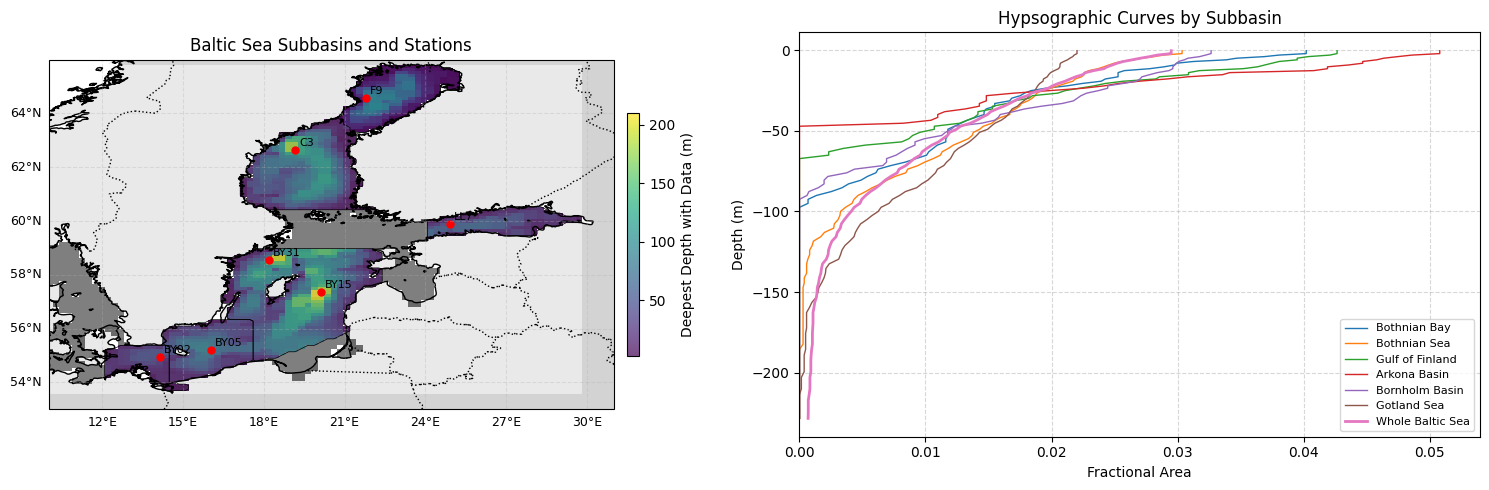

In [31]:
'''Define Basins and compute hypsos'''
# === 1. Load Data ===
bs_grid = xr.open_mfdataset("../reference_run/reference_run_01_1948/19480101.ocean_month_z.nc")
bs_grid = bs_grid['temp'].isel(time=0).drop_vars('time')
bs_grid = xr.where(~np.isnan(bs_grid), 1, bs_grid)  # 1 where valid

# === 2. Define Masks for Subbasins ===
mask_bothnianbay  = ((bs_grid['xh'] + bs_grid['yh']) > 84.6) & (bs_grid['yh'] > 62)
mask_bothniansea  = (bs_grid['yh'] > 60.4) & (bs_grid['xh'] < 25.5) #& (~mask_bothnianbay)
mask_gof          = (bs_grid['yh'] > 59) & (bs_grid['yh'] < 61) & (bs_grid['xh'] > 24)
mask_arkona       = (bs_grid['xh'] > 12) & (bs_grid['xh'] < 14.5) & (bs_grid['yh'] < 55.4) & (bs_grid['yh'] > 54)
mask_bornholm     = (bs_grid['xh'] > 13) & (bs_grid['xh'] < 17.5) & (bs_grid['yh'] < 56.4) & (~mask_arkona)
mask_gotlandsea   = (bs_grid['xh'] > 15) & (bs_grid['yh'] < 59) & (~mask_bornholm) & (~mask_gof) & \
                    ((bs_grid['yh'] - 0.333 * bs_grid['xh']) > 48.8) & \
                    ((bs_grid['xh'] < 22.5) | (bs_grid['yh'] > 59))

arkona_weights = area_weights.where(mask_arkona) * (1/area_weights.where(mask_arkona).sum(dim=['xh','yh']))
gotland_weights = area_weights.where(mask_gotlandsea) * (1/area_weights.where(mask_gotlandsea).sum(dim=['xh','yh']))
bothnian_weights = area_weights.where(mask_bothniansea) * (1/area_weights.where(mask_bothniansea).sum(dim=['xh','yh']))


# === 3. Helper Function to Get Deepest Valid z_l per Grid Cell ===
def max_depth_masked(grid, mask):
    masked_grid = grid.where(mask)
    depth_at_valid = grid['z_l'].where(~np.isnan(masked_grid))
    max_depth = depth_at_valid.max(dim='z_l', skipna=True)
    return max_depth

# === 4. Compute Depth Grids ===
depth_bothnianbay  = max_depth_masked(bs_grid, mask_bothnianbay)
depth_bothniansea  = max_depth_masked(bs_grid, mask_bothniansea)
depth_gof          = max_depth_masked(bs_grid, mask_gof)
depth_arkona       = max_depth_masked(bs_grid, mask_arkona)
depth_bornholm     = max_depth_masked(bs_grid, mask_bornholm)
depth_gotlandsea   = max_depth_masked(bs_grid, mask_gotlandsea)

# === 5. Station Coordinates ===
stations = [
    ("BY02", 14.12, 54.96),
    ("BY05", 16.04, 55.20),
    ("BY15", 20.12, 57.36),
    ("BY31", 18.20, 58.56),
    ("C3",   19.16, 62.64),
    ("F9",   21.80, 64.56),
    ("LL7",  24.92, 59.88),
]

# === 6. Hypsographic Function ===

def compute_hypsographic(grid, mask):
    masked = grid.where(mask)
    area = area_weights.where(mask)
    depth_area = (masked * area).sum(dim=['xh', 'yh'], skipna=True)
    hypsographic = depth_area / depth_area.sum(dim='z_l')
    return hypsographic

# === 7. Compute Hypsographic Curves ===
masks = [mask_bothnianbay, mask_bothniansea, mask_gof, mask_arkona, mask_bornholm, mask_gotlandsea]
labels = ['Bothnian Bay', 'Bothnian Sea', 'Gulf of Finland', 'Arkona Basin', 'Bornholm Basin', 'Gotland Sea']

hypsos = {}
for label, mask in zip(labels, masks):
    hypsos[label] = compute_hypsographic(bs_grid, mask)

bs_mask = ~np.isnan(bs_grid)
hypsos['Whole Baltic Sea'] = compute_hypsographic(bs_grid, bs_mask)

# === 8. Combined Plot: Subbasins + Hypsographic Curves ===
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(1, 2, 2)


# --- Plot 1: Baltic Map with Subbasins ---
ax = ax1
proj = ccrs.PlateCarree()
ax.set_extent([10, 31, 53, 66], crs=proj)
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
bs_mask_surface = ~np.isnan(bs_grid.isel(z_l=0))
ax.pcolormesh(bs_grid['xh'], bs_grid['yh'], bs_mask_surface, transform=proj, shading='auto', cmap='Greys', alpha=0.5)

all_depths = xr.concat([
    depth_bothnianbay, depth_bothniansea, depth_gof,
    depth_arkona, depth_bornholm, depth_gotlandsea
], dim='basin')
vmin = float(all_depths.min(skipna=True).compute())
vmax = float(all_depths.max(skipna=True).compute())
norm = colors.Normalize(vmin=vmin, vmax=vmax)

for depth in [depth_bothnianbay, depth_bothniansea, depth_gof, depth_arkona, depth_bornholm, depth_gotlandsea]:
    im = ax.pcolormesh(
        bs_grid['xh'], bs_grid['yh'], depth,
        transform=proj, cmap='viridis', shading='auto', alpha=0.7, norm=norm
    )
    outline_mask = ~np.isnan(depth)
    ax.contour(
        bs_grid['xh'], bs_grid['yh'], outline_mask,
        levels=[0.5], colors='black', linewidths=0.5, transform=proj
    )

cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02, shrink=0.6)
cbar.set_label("Deepest Depth with Data (m)")

for name, lon, lat in stations:
    ax.plot(lon, lat, marker='o', color='red', markersize=5, transform=proj)
    ax.text(lon + 0.15, lat + 0.15, name, fontsize=8, transform=proj, color='black')

ax.set_title("Baltic Sea Subbasins and Stations")
ax.set_xlabel("Longitude [°E]", fontsize=10)
ax.set_ylabel("Latitude [°N]", fontsize=10)
gl = ax.gridlines(draw_labels=True, crs=proj, linestyle='--', alpha=0.3)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 9}
gl.ylabel_style = {'size': 9}

# --- Plot 2: Hypsographic Curves ---
ax = ax2
for label, hypo in hypsos.items():
    ax.plot(hypo, -hypo['z_l'], label=label, linewidth=2 if label == 'Whole Baltic Sea' else 1)

ax.set_xlabel("Fractional Area")
ax.set_ylabel("Depth (m)")
ax.set_xlim(0, 0.054)
ax.set_title("Hypsographic Curves by Subbasin")
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# === 9. Print Depth Info ===
# print("Maximum depth per subbasin:")
# print(f"Bothnian Bay:     {depth_bothnianbay.max(skipna=True).compute().item():.1f} m")
# print(f"Bothnian Sea:     {depth_bothniansea.max(skipna=True).compute().item():.1f} m")
# print(f"Gulf of Finland:  {depth_gof.max(skipna=True).compute().item():.1f} m")
# print(f"Arkona Basin:     {depth_arkona.max(skipna=True).compute().item():.1f} m")
# print(f"Bornholm Basin:   {depth_bornholm.max(skipna=True).compute().item():.1f} m")
# print(f"Gotland Sea:      {depth_gotlandsea.max(skipna=True).compute().item():.1f} m")

# print("\nMaximum depth (m) at station grid points:")
# for name, lon, lat in stations:
#     lon_idx = abs(bs_grid['xh'] - lon).argmin().item()
#     lat_idx = abs(bs_grid['yh'] - lat).argmin().item()
#     profile = bs_grid[:, lat_idx, lon_idx]
#     valid_mask = (~np.isnan(profile)).compute()
#     valid_depths = bs_grid['z_l'].where(valid_mask, drop=True)

#     if len(valid_depths) > 0:
#         max_depth = float(valid_depths.max().compute())
#         print(f"{name:12s}: {max_depth:.1f} m")
#     else:
#         print(f"{name:12s}: No valid data")


In [32]:
# OLD: '''Refrun station/basin timeseries for all 7 vars (takes 2min, only needed once)'''
# ###hypsos and area weights needed

# '''Basin refrun for integrated heat,salt'''
# # Read in the annual .nc files containing results of the reference run
# ds_oceanmonth = xr.open_mfdataset(
#     '../reference_run/reference_run_01_*/*0101.ocean_month_z.nc',
#     combine='nested',  # needed for concat
#     concat_dim='time',  # concatenate along time dimension to get one dataset from 1948-2020
#     preprocess= lambda ds_oceanmonth:ds_oceanmonth[['temp','salt']]  # select wanted data variables to remove unneccessary stuff
# )

# oceanmonth_arkona  = ds_oceanmonth.sel(xh=14.12, method='nearest').sel(yh=54.96, method='nearest')
# refrun_heat_arkona = xr.Dataset({'temp': (oceanmonth_arkona['temp'] * hypsos['Arkona Basin']).sum(dim='z_l')}).drop_vars(['xh', 'yh'])
# refrun_salt_arkona = xr.Dataset({'salt': (oceanmonth_arkona['salt'] * hypsos['Arkona Basin']).sum(dim='z_l')}).drop_vars(['xh', 'yh'])

# oceanmonth_gotland  = ds_oceanmonth.sel(xh=20.12, method='nearest').sel(yh=57.36, method='nearest')
# refrun_heat_gotland = xr.Dataset({'temp': (oceanmonth_gotland['temp'] * hypsos['Arkona Basin']).sum(dim='z_l')}).drop_vars(['xh', 'yh'])
# refrun_salt_gotland = xr.Dataset({'salt': (oceanmonth_gotland['salt'] * hypsos['Arkona Basin']).sum(dim='z_l')}).drop_vars(['xh', 'yh'])

# oceanmonth_bothnian    = ds_oceanmonth.sel(xh=19.16, method='nearest').sel(yh=62.64, method='nearest')
# refrun_heat_bothnian   = xr.Dataset({'temp': (oceanmonth_bothnian['temp'] * hypsos['Arkona Basin']).sum(dim='z_l')}).drop_vars(['xh', 'yh'])
# refrun_salt_bothnian   = xr.Dataset({'salt': (oceanmonth_bothnian['salt'] * hypsos['Arkona Basin']).sum(dim='z_l')}).drop_vars(['xh', 'yh'])


# '''Basin refrun for all SST,SSH,SSS'''
# ds_sfc = xr.open_mfdataset(
#     '../reference_run/reference_run_01_*/*0101.ocean_sfc.nc',
#     combine='nested',  # needed for concat
#     concat_dim='time',  # concatenate along time dimension to get one dataset from 1948-2020
#     decode_times=xr.coding.times.CFDatetimeCoder(use_cftime=True),
#     preprocess= lambda ds_sfc:ds_sfc[['SSH','SST','SSS']]  # select wanted data variables to remove unneccessary stuff
# )


# # Apply basin area weights
# bothnian_mask_3d = mask_bothniansea.expand_dims(time=ds_sfc.time).transpose('time', 'yh', 'xh')
# arkona_mask_3d   = mask_arkona.expand_dims(time=ds_sfc.time).transpose('time', 'yh', 'xh')
# gotland_mask_3d  = mask_gotlandsea.expand_dims(time=ds_sfc.time).transpose('time', 'yh', 'xh')
# refrun_sfc_bothnian = (ds_sfc.where(bothnian_mask_3d) * bothnian_weights).sum(dim=['xh','yh']) 
# refrun_sfc_arkona   = (ds_sfc.where(arkona_mask_3d) * arkona_weights).sum(dim=['xh','yh'])
# refrun_sfc_gotland  = (ds_sfc.where(gotland_mask_3d) * gotland_weights).sum(dim=['xh','yh'])


# '''Basin refrun for Ice CN and HI'''
# # Read in the annual .nc files containing the results of the reference run
# ds_ice = xr.open_mfdataset(
#     '../reference_run/reference_run_01_*/*0101.ice_month.nc',
#     combine='nested',  # needed for concat
#     concat_dim='time',  # concatenate along time dimension to get one dataset from 1948-2020
#     preprocess= lambda ds_ice:ds_ice[['HI','CN']]  # select wanted data variables to remove unneccessary stuff
# )
# ds_ice = ds_ice.rename({'xT': 'xh', 'yT': 'yh'})
# refrun_ice_arkona = (ds_ice * arkona_weights).sum(dim=['xh','yh'])
# refrun_ice_gotland = (ds_ice * gotland_weights).sum(dim=['xh','yh'])
# refrun_ice_bothnian = (ds_ice * bothnian_weights).sum(dim=['xh','yh'])

# # Save them all
# refrun_heat_arkona.to_netcdf("reference_run_time_series/refrun_heat_arkona.nc")
# refrun_salt_arkona.to_netcdf("reference_run_time_series/refrun_salt_arkona.nc")
# refrun_heat_gotland.to_netcdf("reference_run_time_series/refrun_heat_gotland.nc")
# refrun_salt_gotland.to_netcdf("reference_run_time_series/refrun_salt_gotland.nc")
# refrun_heat_bothnian.to_netcdf("reference_run_time_series/refrun_heat_bothnian.nc")
# refrun_salt_bothnian.to_netcdf("reference_run_time_series/refrun_salt_bothnian.nc")
# refrun_sfc_bothnian.to_netcdf("reference_run_time_series/refrun_sfc_bothnian.nc")
# refrun_sfc_arkona.to_netcdf("reference_run_time_series/refrun_sfc_arkona.nc")
# refrun_sfc_gotland.to_netcdf("reference_run_time_series/refrun_sfc_gotland.nc")
# refrun_ice_arkona.to_netcdf("reference_run_time_series/refrun_ice_arkona.nc")
# refrun_ice_gotland.to_netcdf("reference_run_time_series/refrun_ice_gotland.nc")
# refrun_ice_bothnian.to_netcdf("reference_run_time_series/refrun_ice_bothnian.nc")

#### Import refrun

In [33]:
# '''Import refrun timeseries from new refrun (ca. 30sec); only needed once'''
# # SSH, SST, SSS
# refrun_sfc = xr.open_mfdataset("../reference_run_02/reference_run_02_*/*.ocean_sfc.nc", combine='nested', concat_dim='time', decode_times=CFDatetimeCoder(use_cftime=True))
# refrun_sfc = refrun_sfc.sortby('time').compute()
# refrun_sfc_full_BS = (refrun_sfc * area_weights).sum(dim=['xh','yh'])
# refrun_ssh_full_BS = refrun_sfc_full_BS[['SSH']]
# refrun_sst_full_BS = refrun_sfc_full_BS[['SST']]
# refrun_sss_full_BS = refrun_sfc_full_BS[['SSS']]
# refrun_sfc_arkona = (refrun_sfc * arkona_weights).sum(dim=['xh','yh'])
# refrun_sfc_gotland = (refrun_sfc * gotland_weights).sum(dim=['xh','yh'])
# refrun_sfc_bothnian = (refrun_sfc * bothnian_weights).sum(dim=['xh','yh'])

# # Ice HI, Ice CN
# refrun_ice = xr.open_mfdataset("../reference_run_02/reference_run_02_*/*.ice_month.nc", combine='nested', concat_dim='time', decode_times=CFDatetimeCoder(use_cftime=True))
# refrun_ice = refrun_ice[['CN','HI']].rename({'xT': 'xh', 'yT': 'yh'}).sortby('time').compute()
# refrun_ice_cn_full_BS = (refrun_ice[['CN']] * area_weights).sum(dim=['xh','yh'])
# refrun_ice_hi_full_BS = (refrun_ice[['HI']] * area_weights).sum(dim=['xh','yh'])
# refrun_ice_arkona = (refrun_ice * arkona_weights).sum(dim=['xh','yh'])
# refrun_ice_gotland = (refrun_ice * gotland_weights).sum(dim=['xh','yh'])
# refrun_ice_bothnian = (refrun_ice * bothnian_weights).sum(dim=['xh','yh'])

# # Heat & Salt full BS
# ds_oceanstats = xr.open_mfdataset(
#     "../reference_run_02/reference_run_02_*/ocean.stats.nc",
#     combine='nested', 
#     concat_dim='Time',
#     decode_times=False,
#     preprocess= lambda ds_oceanstats:ds_oceanstats[['Salt','Heat']]
# )
# time_values = ds_oceanstats['Time'].values
# duplicate_indices = np.where(np.diff(time_values) == 0)[0]  # identify equal consecutive values along the Time coordinate
# mask = np.ones(time_values.shape, dtype=bool)  # create a mask with same shape as time coordinates with all values True
# mask[duplicate_indices] = False  # sets all double index points to False
# ds_oceanstats = ds_oceanstats.isel(Time=mask)  # apply mask to ds to remove double entries
# ds_oceanstats = ds_oceanstats.assign_coords(Time=pd.date_range(start="1948-01", end="2020-01", freq="6h"))  # assign correct datetime values to the Time coordinate, the ds contains values each 6h
# ds_oceanstats = ds_oceanstats.rename({'Time': 'time'}).compute()
# refrun_salt_full_BS = ds_oceanstats[['Salt']]
# refrun_heat_full_BS = ds_oceanstats[['Heat']]

# # Heat & Salt basins via station data
# ds_BY02 = xr.open_mfdataset("../reference_run_02/reference_run_02_*/*.station_BY02.nc.*", combine='nested', concat_dim='time', decode_times=True, preprocess= lambda ds_BY02:ds_BY02[['temp','salt']])
# ds_BY02 = ds_BY02.sortby('time').drop_vars(['xh_sub01','yh_sub01'])
# ds_BY02 = ds_BY02.squeeze(dim=['xh_sub01','yh_sub01']).compute()
# refrun_heat_arkona = (ds_BY02 * hypsos['Arkona Basin']).sum(dim='z_l', skipna=True)[['temp']]
# refrun_salt_arkona = (ds_BY02 * hypsos['Arkona Basin']).sum(dim='z_l', skipna=True)[['salt']]
# ds_BY15 = xr.open_mfdataset("../reference_run_02/reference_run_02_*/*.station_BY15.nc.*", combine='nested', concat_dim='time', decode_times=True, preprocess= lambda ds_BY02:ds_BY02[['temp','salt']])
# ds_BY15 = ds_BY15.sortby('time').drop_vars(['xh_sub01','yh_sub01'])
# ds_BY15 = ds_BY15.squeeze(dim=['xh_sub01','yh_sub01']).compute()
# refrun_heat_gotland = (ds_BY15 * hypsos['Gotland Sea']).sum(dim='z_l', skipna=True)[['temp']]
# refrun_salt_gotland = (ds_BY15 * hypsos['Gotland Sea']).sum(dim='z_l', skipna=True)[['salt']]
# ds_C3 = xr.open_mfdataset("../reference_run_02/reference_run_02_*/*.station_C3.nc.*", combine='nested', concat_dim='time', decode_times=True, preprocess= lambda ds_BY02:ds_BY02[['temp','salt']])
# ds_C3 = ds_C3.sortby('time').drop_vars(['xh_sub01','yh_sub01'])
# ds_C3 = ds_C3.squeeze(dim=['xh_sub01','yh_sub01']).compute()
# refrun_heat_bothnian = (ds_C3 * hypsos['Bothnian Sea']).sum(dim='z_l', skipna=True)[['temp']]
# refrun_salt_bothnian = (ds_C3 * hypsos['Bothnian Sea']).sum(dim='z_l', skipna=True)[['salt']]

# # save time series
# # Create output directory if it doesn't exist
# output_dir = "reference_run_time_series/"
# os.makedirs(output_dir, exist_ok=True)

# # Save SSH, SST, SSS full Baltic Sea
# refrun_ssh_full_BS.to_netcdf(os.path.join(output_dir, "refrun_ssh_full_BS.nc"))
# refrun_sst_full_BS.to_netcdf(os.path.join(output_dir, "refrun_sst_full_BS.nc"))
# refrun_sss_full_BS.to_netcdf(os.path.join(output_dir, "refrun_sss_full_BS.nc"))

# # Save SSH, SST, SSS regional basins
# refrun_sfc_arkona.to_netcdf(os.path.join(output_dir, "refrun_sfc_arkona.nc"))
# refrun_sfc_gotland.to_netcdf(os.path.join(output_dir, "refrun_sfc_gotland.nc"))
# refrun_sfc_bothnian.to_netcdf(os.path.join(output_dir, "refrun_sfc_bothnian.nc"))

# # Save Ice CN and HI full Baltic Sea
# refrun_ice_cn_full_BS.to_netcdf(os.path.join(output_dir, "refrun_ice_cn_full_BS.nc"))
# refrun_ice_hi_full_BS.to_netcdf(os.path.join(output_dir, "refrun_ice_hi_full_BS.nc"))

# # Save Ice CN and HI regional basins
# refrun_ice_arkona.to_netcdf(os.path.join(output_dir, "refrun_ice_arkona.nc"))
# refrun_ice_gotland.to_netcdf(os.path.join(output_dir, "refrun_ice_gotland.nc"))
# refrun_ice_bothnian.to_netcdf(os.path.join(output_dir, "refrun_ice_bothnian.nc"))

# # Save full Baltic Sea heat and salt content
# refrun_salt_full_BS.to_netcdf(os.path.join(output_dir, "refrun_salt_full_BS.nc"))
# refrun_heat_full_BS.to_netcdf(os.path.join(output_dir, "refrun_heat_full_BS.nc"))

# # Save heat and salt content in basins from station data
# refrun_heat_arkona.to_netcdf(os.path.join(output_dir, "refrun_heat_arkona.nc"))
# refrun_salt_arkona.to_netcdf(os.path.join(output_dir, "refrun_salt_arkona.nc"))
# refrun_heat_gotland.to_netcdf(os.path.join(output_dir, "refrun_heat_gotland.nc"))
# refrun_salt_gotland.to_netcdf(os.path.join(output_dir, "refrun_salt_gotland.nc"))
# refrun_heat_bothnian.to_netcdf(os.path.join(output_dir, "refrun_heat_bothnian.nc"))
# refrun_salt_bothnian.to_netcdf(os.path.join(output_dir, "refrun_salt_bothnian.nc"))

In [34]:
'''Import refrun timeseries'''
# Full BS
refrun_ssh_full_BS     = xr.open_dataset("reference_run_time_series/refrun_ssh_full_BS.nc")#.rename({"__xarray_dataarray_variable__": "SSH"})
refrun_sst_full_BS     = xr.open_dataset("reference_run_time_series/refrun_sst_full_BS.nc")#.rename({"__xarray_dataarray_variable__": "SST"})
refrun_sss_full_BS     = xr.open_dataset("reference_run_time_series/refrun_sss_full_BS.nc")#.rename({"__xarray_dataarray_variable__": "SSS"})
refrun_ice_hi_full_BS  = xr.open_dataset("reference_run_time_series/refrun_ice_hi_full_BS.nc")#.rename({"__xarray_dataarray_variable__": "HI"})
refrun_ice_cn_full_BS  = xr.open_dataset("reference_run_time_series/refrun_ice_cn_full_BS.nc")#.rename({"__xarray_dataarray_variable__": "CN"})
refrun_salt_full_BS    = xr.open_dataset("reference_run_time_series/refrun_salt_full_BS.nc")#.rename({"Time": "time"})
refrun_heat_full_BS    = xr.open_dataset("reference_run_time_series/refrun_heat_full_BS.nc")#.rename({"Time": "time"})
# Stations
refrun_heat_arkona   = xr.open_dataset("reference_run_time_series/refrun_heat_arkona.nc")
refrun_salt_arkona   = xr.open_dataset("reference_run_time_series/refrun_salt_arkona.nc")
refrun_heat_gotland  = xr.open_dataset("reference_run_time_series/refrun_heat_gotland.nc")
refrun_salt_gotland  = xr.open_dataset("reference_run_time_series/refrun_salt_gotland.nc")
refrun_heat_bothnian = xr.open_dataset("reference_run_time_series/refrun_heat_bothnian.nc")
refrun_salt_bothnian = xr.open_dataset("reference_run_time_series/refrun_salt_bothnian.nc")
refrun_sfc_bothnian  = xr.open_dataset("reference_run_time_series/refrun_sfc_bothnian.nc")
refrun_sfc_arkona    = xr.open_dataset("reference_run_time_series/refrun_sfc_arkona.nc")
refrun_sfc_gotland   = xr.open_dataset("reference_run_time_series/refrun_sfc_gotland.nc")
refrun_ice_arkona    = xr.open_dataset("reference_run_time_series/refrun_ice_arkona.nc")
refrun_ice_gotland   = xr.open_dataset("reference_run_time_series/refrun_ice_gotland.nc")
refrun_ice_bothnian  = xr.open_dataset("reference_run_time_series/refrun_ice_bothnian.nc")

#### Define used functions

In [35]:
'''Define used functions'''

########################################################################################################################################################
# Define function to average over BS and modify time coord
def process_monthly_ds(ds,var,EY,basin): # for ssh,sst,sss and ice
    # ds  - modified dataarray
    # var - 'sfc' (means SSH) or 'Salt' or 'Temp' or 'ice', used for including the initial value for all except ice
    # EY  - ensemble year
    # basin - full Baltic Sea/ Arkona Sea/ Gotland Basin/ Bothnian Bay
    dataset_mean = {}
    for year in ds:
        if len(ds[year]) > 0:  # check if a year contains [] because of corrupted data
            if basin == 'full_BS':
                dataset_mean[year] = (ds[year] * area_weights).sum(dim=["xh", "yh"])  # compute averages over whole Baltic Sea with area_weights weighing in the size of each grid point
                months_array = range(1, len(ds[year].time)+1)  # create months array as new time dim values
                dataset_mean[year] = dataset_mean[year].rename({'time': 'month'}).assign_coords(month=months_array)
                if var in ["sfc", "Temp", "Salt"]:  # Got no initial value for Ice
                    dataset_mean[year] = xr.concat([xr.DataArray(data=[initial_fields_full_BS[EY][var].values], coords={"month": [0]}, dims=("month",)), dataset_mean[year]], dim="month")  # add initial value
            if basin == 'Arkona':
                dataset_mean[year] = (ds[year] * arkona_weights).sum(dim=["xh", "yh"])  # compute averages over arkona sea weighing in the size of each grid point
                months_array = range(1, len(ds[year].time)+1)  # create months array as new time dim values
                dataset_mean[year] = dataset_mean[year].rename({'time': 'month'}).assign_coords(month=months_array)
                if var in ["sfc", "Temp", "Salt"]:  # Got no initial value for Ice
                    dataset_mean[year] = xr.concat([xr.DataArray(data=[initial_fields_Arkona[EY][var].values], coords={"month": [0]}, dims=("month",)), dataset_mean[year]], dim="month")  # add initial value
            if basin == 'Gotland':
                dataset_mean[year] = (ds[year] * gotland_weights).sum(dim=["xh", "yh"])  # compute averages over arkona sea weighing in the size of each grid point
                months_array = range(1, len(ds[year].time)+1)  # create months array as new time dim values
                dataset_mean[year] = dataset_mean[year].rename({'time': 'month'}).assign_coords(month=months_array)
                if var in ["sfc", "Temp", "Salt"]:  # Got no initial value for Ice
                    dataset_mean[year] = xr.concat([xr.DataArray(data=[initial_fields_Gotland[EY][var].values], coords={"month": [0]}, dims=("month",)), dataset_mean[year]], dim="month")  # add initial value
            if basin == 'Bothnian':
                dataset_mean[year] = (ds[year] * bothnian_weights).sum(dim=["xh", "yh"])  # compute averages over arkona sea weighing in the size of each grid point
                months_array = range(1, len(ds[year].time)+1)  # create months array as new time dim values
                dataset_mean[year] = dataset_mean[year].rename({'time': 'month'}).assign_coords(month=months_array)
                if var in ["sfc", "Temp", "Salt"]:  # Got no initial value for Ice
                    dataset_mean[year] = xr.concat([xr.DataArray(data=[initial_fields_Bothnian[EY][var].values], coords={"month": [0]}, dims=("month",)), dataset_mean[year]], dim="month")  # add initial value
    dataset_mean = xr.Dataset(dataset_mean).to_array(dim='year')
    return dataset_mean


########################################################################################################################################################
# Define function to modify time coord
def process_6h_ds(ds, init_value, EY): # for salt and heat, no average needed over BS
    # ds  - modified dataarray
    # init_value 
    # EY  - ensemble year
    dataset_new = {}
    for year in ds:
        if len(ds[year]) > 0:  # check if a year contains [] because of corrupted data
            time_array = range(1, len(ds[year].Time)+1)  # create time array as new time dim values
            dataset_new[year] = ds[year].rename({'Time': 'timestep_6h'}).assign_coords(timestep_6h=time_array)
    dataset_new = xr.Dataset(dataset_new).to_array(dim='year')
    # Modify from 6-hourly(so far called 'timestep_6h') -> monthly values
    dataset_new                = dataset_new.isel(timestep_6h=slice(1, None)).coarsen(timestep_6h=122, boundary="trim").mean()  # averaging over 122 values (6h -> avergae month), leaving out the initial value which is added again below
    dataset_new['timestep_6h'] = range(1, len(dataset_new['timestep_6h'])+1)  # rename timestep_6h coordinate values
    dataset_new                = dataset_new.rename({'timestep_6h': 'month'})  # rename timestep_6h coord to month
    # Add initial value for month=0
    init_value  = xr.DataArray(np.full((len(dataset_new.year), 1), init_value[EY] ), coords={'year': dataset_new.year, 'month': np.array([0])}, dims=['year', 'month'])
    dataset_new = xr.concat([init_value, dataset_new], dim='month')
    return dataset_new


########################################################################################################################################################
def get_predictor_thresholds(timeseries, detrend, EY):
    # timeseries       - predictor timeseries
    # detrend          - if 0: no detrend, if 1: remove linear trend from time series
    # EY               - initial year of ensemble
    years                = timeseries['time'].dt.year
    output_years         = years.where((years > 1947) & (years < 2011), drop=True)  # list of years 1948-2010

    # Detrend the time series, makes sense for temperature related variables
    if detrend == 1:
        slope, intercept, *_ = linregress(years.values, timeseries.values)
        timeseries_detrended = timeseries - slope * years + intercept
        timeseries           = timeseries_detrended
    # Compute category thresholds
    mean_val = timeseries.mean()
    std_val  = timeseries.std()
    strong_pos   = output_years.where((timeseries > mean_val + std_val).compute(), drop=True).values
    moderate_pos = output_years.where(((timeseries > mean_val + 0.5 * std_val) & (timeseries <= mean_val + std_val)).compute(), drop=True).values
    neutral      = output_years.where(((timeseries >= mean_val - 0.5 * std_val) & (timeseries <= mean_val + 0.5 * std_val)).compute(), drop=True).values
    moderate_neg = output_years.where(((timeseries < mean_val - 0.5 * std_val) & (timeseries >= mean_val - std_val)).compute(), drop=True).values
    strong_neg   = output_years.where((timeseries < mean_val - std_val).compute(), drop=True).values
    # Find threshold that initial year lies in
    all_thresholds = [(" Strong pos", strong_pos), ("     Mod pos", moderate_pos), ("       Neutral", neutral), ("     Mod neg", moderate_neg), (" Strong neg", strong_neg)]
    for name, years in all_thresholds:
        if EY in years:
            initial_year_threshold = years
            threshold_name         = name
            break
        else:
            threshold_name = None
            initial_year_threshold = None
    return all_thresholds, threshold_name, initial_year_threshold


########################################################################################################################################################
# calculate variance of refrun for each var, used in the bloew function but computation only needed once


def compute_skill_metrics(data_timeseries, refrun_timeseries, timescale, predictant, basin, bootstrap):
    # function that calculates the wanted skill metrics (CC&MSSS) between a timeseries and the according refrun on a given timescale
    # timeseries will most likely be a subsample mean
    # compute correlation coefficient, p-value of that & also the mean square skill score (MSSS)
    # variance give the separately computed variance of the refruns for each variable for each basin

    # Shorten timeseries to chosen timescale
    if timescale == '1y':
        data_timeseries   = data_timeseries.sel(month=slice(1,12))
        refrun_timeseries = refrun_timeseries.sel(month=slice(1,12))
    if timescale == '5y':
        data_timeseries   = data_timeseries.sel(month=slice(1,60))
        refrun_timeseries = refrun_timeseries.sel(month=slice(1,60))
    if timescale == '6-10y':
        data_timeseries   = data_timeseries.sel(month=slice(60,120))
        refrun_timeseries = refrun_timeseries.sel(month=slice(60,120))
    if timescale == '10y':
        data_timeseries   = data_timeseries.sel(month=slice(1,120))
        refrun_timeseries = refrun_timeseries.sel(month=slice(1,120))
    

    # Adjust the variance of the data to the variance of the refrun for Ice
    if predictant in ["Ice CN", "Ice HI"]:
        refrun_var = refrun_timeseries.var()
        data_var = data_timeseries.var()
        data_timeseries = data_timeseries * (refrun_var / data_var)**0.5

    # Compute CC and MSSS
    CC_0, _ = pearsonr(data_timeseries, refrun_timeseries)
    MSSS_0  = 1 - np.sum((data_timeseries - refrun_timeseries)**2) / np.sum((refrun_timeseries - np.mean(refrun_timeseries))**2)
    
    # Bootstrap yes or no?
    if bootstrap:
        CC_p, MSSS_p = overlapping_block_bootstrap(data_timeseries=data_timeseries, refrun_timeseries=refrun_timeseries, predictant=predictant, basin=basin, timescale=timescale)
    else:  # no bootstrap, just give empty array as output
        CC_p, MSSS_p = [], []

    return CC_0, CC_p, MSSS_0.values, MSSS_p



########################################################################################################################################################
# Run bootstrapping test to obtain significance intervals (pvalues) for CC and MSSS
def overlapping_block_bootstrap(data_timeseries, refrun_timeseries, predictant, basin, timescale, random_seed=8):
    if random_seed is not None:
        np.random.seed(random_seed)

    n_bootstrap = 1000

    # Set blocksizes based on predictant autocorrelation and prediction timescale, difficult decision but important
    # looked at autocorrelation of refrun, time until it goes below 1/e
    if basin == 'full_BS':
        if predictant in ['SSH']:
            blocksize = 1
        elif predictant in ['SST', 'SSS']:
            blocksize = 2
        elif predictant in ['Ice CN', 'Ice HI']:
            blocksize = 3
        elif predictant in ['Salt']:
            if timescale == '1y':
                blocksize = 6
            elif timescale == '5y':
                blocksize = 10
            elif timescale == '6-10y':
                blocksize = 20
            elif timescale == '10y':
                blocksize = 40
        elif predictant in ['Heat']:
            if timescale == '1y':
                blocksize = 3
            elif timescale == '5y':
                blocksize = 10
            elif timescale == '6-10y':
                blocksize = 10
            elif timescale == '10y':
                blocksize = 10
    elif basin == 'Arkona':
        if predictant in ['SSH','SSS']:
            blocksize = 1
        elif predictant in ['SST','Ice CN','Ice HI']:
            blocksize = 2
        elif predictant in ['Salt']:
            blocksize = 3
        elif predictant in ['Heat']:
            blocksize = 4
    elif basin == 'Gotland':
        if predictant in ['SSH']:
            blocksize = 1
        elif predictant in ['SST','Ice CN','Ice HI']:
            blocksize = 2
        elif predictant in ['SSS']:
            if timescale == '1y':
                blocksize = 4
            elif timescale == '5y':
                blocksize = 20
            elif timescale == '6-10y':
                blocksize = 10
            elif timescale == '10y':
                blocksize = 40
        elif predictant in ['Salt']:
            if timescale == '1y':
                blocksize = 4
            elif timescale == '5y':
                blocksize = 20
            elif timescale == '6-10y':
                blocksize = 15
            elif timescale == '10y':
                blocksize = 40
        elif predictant in ['Heat']:
            if timescale == '1y':
                blocksize = 3
            elif timescale == '5y':
                blocksize = 6
            elif timescale == '6-10y':
                blocksize = 6
            elif timescale == '10y':
                blocksize = 6
    elif basin == 'Bothnian':
        if predictant in ['SSH']:
            blocksize = 1
        elif predictant in ['SST']:
            blocksize = 2
        elif predictant in ['Heat', 'Ice CN', 'Ice HI']:
            blocksize = 3
        elif predictant in ['Salt']:
            if timescale == '1y':
                blocksize = 4
            elif timescale == '5y':
                blocksize = 10
            elif timescale == '6-10y':
                blocksize = 20
            elif timescale == '10y':
                blocksize = 40
        elif predictant in ['SSS']: 
            if timescale == '1y':
                blocksize = 4
            elif timescale == '5y':
                blocksize = 6
            elif timescale == '6-10y':
                blocksize = 20
            elif timescale == '10y':
                blocksize = 40



    # Generate all overlapping blocks (start at every possible index)
    n             = len(data_timeseries)
    n_blocks      = int(np.ceil(n / blocksize)) # rounds up the number of used blocks, ie 119/60 -> 2.
    max_start     = n - blocksize + 1
    blocks_data   = np.array([data_timeseries[i:i + blocksize] for i in range(max_start)])
    blocks_refrun = np.array([refrun_timeseries[i:i + blocksize] for i in range(max_start)])

    # Compute original pearsonr and MSSS
    original_corr, _ = pearsonr(data_timeseries, refrun_timeseries)
    original_MSSS    = (1 - ( np.mean((data_timeseries - refrun_timeseries)**2) ) / ( np.mean((refrun_timeseries - np.mean(refrun_timeseries))**2) )).values
    
    bootstrapped_corrs = np.empty(n_bootstrap)
    bootstrapped_MSSSs = np.empty(n_bootstrap)
        
    # bootstrapping loop (n_bootstrap times)
    for i in range(n_bootstrap):
        # Sample block indices with replacement
        idx = np.random.randint(0, max_start, size=n_blocks)
        # Concatenate the blocks to form bootstrap sample
        data_boot   = blocks_data[idx].reshape(-1)[:n]
        refrun_boot = blocks_refrun[idx].reshape(-1)[:n]
        # Compute bootstrapped CC and MSSS
        bootstrapped_corrs[i], _ = pearsonr(data_boot, refrun_boot)
        bootstrapped_MSSSs[i]    = 1 - ( np.mean((data_boot - refrun_boot)**2) ) / ( np.mean((refrun_boot - np.mean(refrun_boot))**2) )

    # two-tailed hypothesis test: pvalue with null hypothesis of CC=0 and MSSS=0
    p_value_corr = np.mean(bootstrapped_corrs >= original_corr)
    p_value_MSSS = np.mean(bootstrapped_MSSSs >= original_MSSS)
    return p_value_corr, p_value_MSSS




########################################################################################################################################################
# deltas over whole refrun 72y:  sst: +1.08986K; ssh:  +0.060953m; sss:  +0.23475; heat: +5.11774e+19; salt: -7.13216e11
def remove_annual_cycle_and_detrend(refruns, ds, detrending_method):
    # computes and substracts annual cycle from each refrun[EY] and ds_var.sel(EY=EY) seperately
    # detrending_method:  0: no detrending
    #                     1: calculate 10y linear trend of refrun and remove it from both refrun and ds
    #                     2: remove 10y linear trend of refrun from refrun and 10y lin trend of of ensemble from ds
    #                     3: for heat: remove linear trend computed over whole refrun from refrun and ds
    #                        delta heat over whole refrun (72y): +5.11774e+19
    #                     4: for sst: remove linear trend computed over whole refrun from refrun and ds
    #                        delta sst over whole refrun(72y): +1.08986K
    
    refruns_ano         = refruns.copy()
    ds_ano              = ds.copy()
    refruns_climatology = {}
    ds_climatology      = {}

    # I. Remove annual cycle
    for EY in ensemble_years:
        refruns_ano[EY].coords['moy'] = ('month', (refruns_ano[EY]['month'] % 12 + 1).data)
        refruns_climatology[EY]       = refruns_ano[EY].groupby('moy').mean(dim='month')
        refruns_ano[EY]               = refruns_ano[EY].groupby('moy') - refruns_climatology[EY]
        ds_ano.coords['moy']    = ('month', (ds_ano['month'] % 12 + 1).data)
        ds_climatology[EY]      = ds_ano.sel(EY=EY).groupby('moy').mean(dim='month')
        ds_ano.loc[dict(EY=EY)] = ds_ano.sel(EY=EY).groupby('moy') - ds_climatology[EY]

    # II. Detrend using selected method
    for EY in ensemble_years:
        t = np.arange(refruns_ano[EY].sizes['month'])

        if detrending_method == 1:
            coef                    = np.polyfit(t, refruns_ano[EY].values, deg=1)
            trend                   = np.polyval(coef, t)
            trend_da                = xr.DataArray(trend, dims='month', coords={'month': refruns_ano[EY]['month']})
            refruns_ano[EY]         = refruns_ano[EY] - trend_da
            ds_ano.loc[dict(EY=EY)] = ds_ano.sel(EY=EY) - trend_da

        elif detrending_method == 2:
            coef_refrun     = np.polyfit(t, refruns_ano[EY].values, deg=1)
            trend_refrun    = np.polyval(coef_refrun, t)
            trend_refrun_da = xr.DataArray(trend_refrun, dims='month', coords={'month': refruns_ano[EY]['month']})
            refruns_ano[EY] = refruns_ano[EY] - trend_refrun_da

            ds_EY                   = ds_ano.sel(EY=EY).mean(dim='year')
            coef_ds                 = np.polyfit(t, ds_EY.values, deg=1)
            trend_ds                = np.polyval(coef_ds, t)
            trend_ds_da             = xr.DataArray(trend_ds, dims='month', coords={'month': ds_EY['month']})
            ds_ano.loc[dict(EY=EY)] = ds_ano.sel(EY=EY) - trend_ds_da

        elif detrending_method == 3:
            # Fixed trend for heat
            heat_delta_72y = 5.11774e+19
            heat_delta_10y = heat_delta_72y * (10 / 72)
            # Build linear trend over the month axis
            trend                   = np.linspace(0, heat_delta_10y, refruns_ano[EY].sizes['month'])
            trend_da                = xr.DataArray(trend, dims='month', coords={'month': refruns_ano[EY]['month']})
            refruns_ano[EY]         = refruns_ano[EY] - trend_da
            ds_ano.loc[dict(EY=EY)] = ds_ano.sel(EY=EY) - trend_da

        elif detrending_method == 4:
            # Fixed trend for SST
            sst_delta_72y = 1.08986
            sst_delta_10y = sst_delta_72y * (10 / 72)
            # Build linear trend over the month axis
            trend                   = np.linspace(0, sst_delta_10y, refruns_ano[EY].sizes['month'])
            trend_da                = xr.DataArray(trend, dims='month', coords={'month': refruns_ano[EY]['month']})
            refruns_ano[EY]         = refruns_ano[EY] - trend_da  
            ds_ano.loc[dict(EY=EY)] = ds_ano.sel(EY=EY) - trend_da    

    return refruns_ano, ds_ano, refruns_climatology, ds_climatology


########################################################################################################################################################
# Compute autocorrelation function of a given dataset
def autocorrelation(ds,steps):
    # ds - time series dataarray

    if isinstance(ds, xr.DataArray):
        time_series = ds.values[~np.isnan(ds.values)]  # remove nan values
    else:
        time_series = ds
    
    # At first substract the linear trend from the time series
    time_index = np.arange(0,len(time_series),1)
    slope, intercept, _, _, _ = linregress(time_index, time_series)
    trend = slope * time_index + intercept
    time_series = time_series - trend

    autocorr = []
    for i in range (1,int(steps)+1):
        autocorr = np.append(autocorr, np.corrcoef(time_series[:-i], time_series[i:])[0, 1])
    return autocorr

#### Predictor timeseries

In [36]:
'''Prepare all predictor timeseries'''


''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''

'''Prepare initial value timeseries'''
# Initial values
# No init values for ice related vars
sss_0101_full_BS  = refrun_sss_full_BS['SSS'].sel(time=refrun_sss_full_BS.time[(refrun_sss_full_BS.time.dt.month == 1) & (refrun_sss_full_BS.time.dt.day == 1)])
sst_0101_full_BS  = refrun_sst_full_BS['SST'].sel(time=refrun_sst_full_BS.time[(refrun_sst_full_BS.time.dt.month == 1) & (refrun_sst_full_BS.time.dt.day == 1)])
ssh_0101_full_BS  = refrun_ssh_full_BS['SSH'].sel(time=refrun_ssh_full_BS.time[(refrun_ssh_full_BS.time.dt.month == 1) & (refrun_ssh_full_BS.time.dt.day == 1)])
salt_0101_full_BS = refrun_salt_full_BS['Salt'].sel(time=refrun_salt_full_BS.time[(refrun_salt_full_BS.time.dt.month == 1) & (refrun_salt_full_BS.time.dt.day == 1) & (refrun_salt_full_BS.time.dt.hour == 0)])
heat_0101_full_BS = refrun_heat_full_BS['Heat'].sel(time=refrun_heat_full_BS.time[(refrun_heat_full_BS.time.dt.month == 1) & (refrun_heat_full_BS.time.dt.day == 1) & (refrun_heat_full_BS.time.dt.hour == 0)])

sss_0101_Arkona = refrun_sfc_arkona['SSS'].sel(time=refrun_sfc_arkona.time[(refrun_sfc_arkona.time.dt.month == 1) & (refrun_sfc_arkona.time.dt.day == 1)])
sst_0101_Arkona = refrun_sfc_arkona['SST'].sel(time=refrun_sfc_arkona.time[(refrun_sfc_arkona.time.dt.month == 1) & (refrun_sfc_arkona.time.dt.day == 1)])
ssh_0101_Arkona = refrun_sfc_arkona['SSH'].sel(time=refrun_sfc_arkona.time[(refrun_sfc_arkona.time.dt.month == 1) & (refrun_sfc_arkona.time.dt.day == 1)])
sss_0101_Gotland = refrun_sfc_gotland['SSS'].sel(time=refrun_sfc_gotland.time[(refrun_sfc_gotland.time.dt.month == 1) & (refrun_sfc_gotland.time.dt.day == 1)])
sst_0101_Gotland = refrun_sfc_gotland['SST'].sel(time=refrun_sfc_gotland.time[(refrun_sfc_gotland.time.dt.month == 1) & (refrun_sfc_gotland.time.dt.day == 1)])
ssh_0101_Gotland = refrun_sfc_gotland['SSH'].sel(time=refrun_sfc_gotland.time[(refrun_sfc_gotland.time.dt.month == 1) & (refrun_sfc_gotland.time.dt.day == 1)])
sss_0101_Bothnian = refrun_sfc_bothnian['SSS'].sel(time=refrun_sfc_bothnian.time[(refrun_sfc_bothnian.time.dt.month == 1) & (refrun_sfc_bothnian.time.dt.day == 1)])
sst_0101_Bothnian = refrun_sfc_bothnian['SST'].sel(time=refrun_sfc_bothnian.time[(refrun_sfc_bothnian.time.dt.month == 1) & (refrun_sfc_bothnian.time.dt.day == 1)])
ssh_0101_Bothnian = refrun_sfc_bothnian['SSH'].sel(time=refrun_sfc_bothnian.time[(refrun_sfc_bothnian.time.dt.month == 1) & (refrun_sfc_bothnian.time.dt.day == 1)])

heat_0101_Arkona = refrun_heat_arkona['temp'].sel(time=refrun_heat_arkona.time[refrun_heat_arkona.time.dt.month == 1])
salt_0101_Arkona = refrun_salt_arkona['salt'].sel(time=refrun_salt_arkona.time[refrun_salt_arkona.time.dt.month == 1])
heat_0101_Gotland = refrun_heat_gotland['temp'].sel(time=refrun_heat_gotland.time[refrun_heat_gotland.time.dt.month == 1])
salt_0101_Gotland = refrun_salt_gotland['salt'].sel(time=refrun_salt_gotland.time[refrun_salt_gotland.time.dt.month == 1])
heat_0101_Bothnian = refrun_heat_bothnian['temp'].sel(time=refrun_heat_bothnian.time[refrun_heat_bothnian.time.dt.month == 1])
salt_0101_Bothnian = refrun_salt_bothnian['salt'].sel(time=refrun_salt_bothnian.time[refrun_salt_bothnian.time.dt.month == 1])


''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''

'''Prepare NAO & AMV timeseries'''
# DJFM NAO index
df_NAO              = pd.read_csv("supplemental_data/NAO_index.txt", sep=r'\s+', header=None)  # read in the file
df_NAO.columns      = ['year'] + [f'{month:02d}' for month in range(1, 13)]  # name columns
df_NAO['DJFM_mean'] = df_NAO['12'].shift(1).astype(float).add(df_NAO['01'].astype(float)).add(df_NAO['02'].astype(float)).add(df_NAO['03'].astype(float)) / 4
ds_NAO_DJFM         = xr.DataArray(data=df_NAO['DJFM_mean'].values, coords={'time': pd.to_datetime(df_NAO['year'], format='%Y')}, dims='time', name='DJFM_NAO_index').to_dataset()  # transform to wished format: dataset
NAO_DJFM            = ds_NAO_DJFM['DJFM_NAO_index']  # annual djfm mean timeseries using december of year n-1
NAO_DJFM_future_3y  = NAO_DJFM.rolling(time=3, center=False).mean().shift(time=-2)
NAO_DJFM_future_5y  = NAO_DJFM.rolling(time=5, center=False).mean().shift(time=-4)
NAO_DJFM_future_7y  = NAO_DJFM.rolling(time=7, center=False).mean().shift(time=-6)
NAO_DJFM_future_10y = NAO_DJFM.rolling(time=10, center=False).mean().shift(time=-9)
NAO_DJFM_29         = NAO_DJFM.rolling(time=8, center=False).mean().shift(time=-8)  # 2-9y mean future NAO index
NAO_DJFM_59        = NAO_DJFM.rolling(time=5, center=False).mean().shift(time=-9)  # 2-9y mean future NAO index
# AMV index
df_AMV                = pd.read_csv("supplemental_data/AMV_index.txt", sep=r'\s+', header=None)  # read in the file
df_AMV.columns        = ['year'] + [f'{month:02d}' for month in range(1, 13)]  # name columns
df_AMV['annual_mean'] = df_AMV.iloc[:, 1:].mean(axis=1)  # Compute annual mean AMV index
ds_AMV          = xr.DataArray(data=df_AMV['annual_mean'].values, coords={'time': pd.to_datetime(df_AMV['year'], format='%Y')}, dims='time', name='AMV_index').to_dataset()  # transform to wished format: dataset
ds_AMV          = ds_AMV['AMV_index']
ds_AMV_past_1y  = ds_AMV.shift(time=1)                                 # compute previous 1y mean
ds_AMV_past_3y  = ds_AMV_past_1y.rolling(time=3, center=False).mean()  # compute previous 3y mean
ds_AMV_past_5y  = ds_AMV_past_1y.rolling(time=5, center=False).mean()  # compute previous 5y mean
ds_AMV_past_7y  = ds_AMV_past_1y.rolling(time=7, center=False).mean()  # compute previous 7y mean
ds_AMV_past_10y = ds_AMV_past_1y.rolling(time=10, center=False).mean() # compute previous 10y mean
ds_AMV_future_1y  = ds_AMV.copy()                                                # ds_AMV hold future 1y mean value
ds_AMV_future_3y  = ds_AMV.rolling(time=3, center=False).mean().shift(time=-2)   # compute future 3y mean
ds_AMV_future_5y  = ds_AMV.rolling(time=5, center=False).mean().shift(time=-4)   # compute future 5y mean
ds_AMV_future_7y  = ds_AMV.rolling(time=7, center=False).mean().shift(time=-6)   # compute future 7y mean
ds_AMV_future_10y = ds_AMV.rolling(time=10, center=False).mean().shift(time=-9)  # compute future 9y mean
ds_AMV_past_and_future_1y  = ds_AMV.rolling(time=2, center=True).mean()   # mean over past and future 1y
ds_AMV_past_and_future_3y  = ds_AMV.rolling(time=6, center=True).mean()   # mean over past and future 3y
ds_AMV_past_and_future_5y  = ds_AMV.rolling(time=10, center=True).mean()  # mean over past and future 5y
ds_AMV_past_and_future_7y  = ds_AMV.rolling(time=14, center=True).mean()  # mean over past and future 7y
ds_AMV_past_and_future_10y = ds_AMV.rolling(time=20, center=True).mean()  # mean over past and future 10y


''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''

'''Prepare past 5/10/15y salt time series'''
annual_refrun_salt_full_BS = refrun_salt_full_BS['Salt'].resample(time='1YS').mean()
salt_past_5y_full_BS       = annual_refrun_salt_full_BS.rolling(time=5,  center=False).mean().shift(time=1)
salt_past_10y_full_BS      = annual_refrun_salt_full_BS.rolling(time=10, center=False).mean().shift(time=1)
salt_past_15y_full_BS      = annual_refrun_salt_full_BS.rolling(time=15, center=False).mean().shift(time=1)


''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''

''

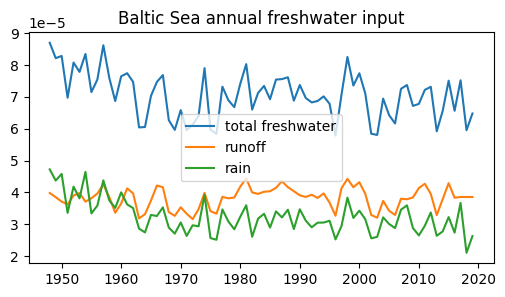

In [37]:
'''Compute annual freshwater input as sum of rain and runoff, data from forcing fields (only needed once, ca. 20min)'''

###### Rain
# area_weights_rain = area_weights.rename({'yh': 'lat', 'xh': 'lon'})
# rain_ts = []
# for year in range(1948, 2020):    
#     print(f"Processing {year}")
#     rain = xr.open_dataset(f"../../iow/database/meteo/coastDat-3_COSMO-CLM/{year}/rain.mom.dta.nc")['rain']
#     if 'area_weights_rain_interp' not in locals():
#         area_weights_rain_interp = area_weights_rain.interp(lat=rain.lat, lon=rain.lon, method='nearest')
#     rain = rain.sel(time=slice(f"{year}-01-01", f"{year}-12-31"))
#     rain = rain.sel(lon=slice(8.12, 29.72), lat=slice(53.64, 65.76))
#     rain_mean = rain.mean(dim='time')
#     rain_sum = (rain_mean * area_weights_rain_interp).sum(dim=['lat', 'lon'])
#     rain_sum = rain_sum.expand_dims(time=[np.datetime64(f"{year}-01-01", "ns")])
#     rain_ts.append(rain_sum)
# rain_ts = xr.concat(rain_ts, dim='time').chunk({'time': -1})
# rain_ts.to_netcdf("supplemental_data/rain_full_BS.nc")
ds_rain = xr.open_dataarray(f"supplemental_data/rain_full_BS.nc")

###### Runoff
# River runoff timeseries
# Use area weights kg/m**2/s, then sum along xh&yh -> compatible with rain data although different gird, just add the two
# runoff_ts = []
# for year in range(1948,2020):
#     runoff = xr.open_dataset(f"../../iow/database/RIVER/level-2/reconstruction-1850-2000/8nm/RiverDat_CDOM_V05/{year}/runoff.nc", decode_times=False)
#     runoff = runoff['runoff'].isel(time=slice(1,13)).mean(dim='time').rename({'lon': 'xh', 'lat': 'yh'})
#     area_weights_runoff = area_weights.interp(xh=runoff.xh, yh=runoff.yh, method='nearest')
#     runoff = (runoff * area_weights_runoff).sum(dim=['xh','yh']).expand_dims(time=[np.datetime64(f"{year}-01-01", "ns")])
#     runoff_ts.append(runoff)
# runoff_ts = xr.concat(runoff_ts, dim='time')
# runoff_ts.to_netcdf("supplemental_data/runoff_full_BS.nc")
ds_runoff = xr.open_dataarray(f"supplemental_data/runoff_full_BS.nc")

# freshwater_ts = rain_ts + runoff_ts
# freshwater_ts.to_netcdf("supplemental_data/freshwater_full_BS.nc")
ds_freshwater = xr.open_dataarray(f"supplemental_data/freshwater_full_BS.nc")

plt.figure(figsize=(6,3))
plt.plot(ds_freshwater.time, ds_freshwater, label='total freshwater')
plt.plot(ds_runoff.time, ds_runoff, label='runoff')
plt.plot(ds_rain.time, ds_rain, label='rain')
plt.legend()
plt.title('Baltic Sea annual freshwater input');

ds_freshwater_past_1y  = ds_freshwater.shift(time=1)                                 # compute previous 1y mean
ds_freshwater_past_3y  = ds_freshwater_past_1y.rolling(time=3, center=False).mean()  # compute previous 3y mean
ds_freshwater_past_5y  = ds_freshwater_past_1y.rolling(time=5, center=False).mean()  # compute previous 5y mean
ds_freshwater_past_7y  = ds_freshwater_past_1y.rolling(time=7, center=False).mean()  # compute previous 7y mean
ds_freshwater_past_10y = ds_freshwater_past_1y.rolling(time=10, center=False).mean() # compute previous 10y mean
ds_freshwater_future_1y  = ds_freshwater.copy()                                                # ds_freshwater hold future 1y mean value
ds_freshwater_future_3y  = ds_freshwater.rolling(time=3, center=False).mean().shift(time=-2)   # compute future 3y mean
ds_freshwater_future_5y  = ds_freshwater.rolling(time=5, center=False).mean().shift(time=-4)   # compute future 5y mean
ds_freshwater_future_7y  = ds_freshwater.rolling(time=7, center=False).mean().shift(time=-6)   # compute future 7y mean
ds_freshwater_future_10y = ds_freshwater.rolling(time=10, center=False).mean().shift(time=-9)  # compute future 9y mean
ds_freshwater_past_and_future_1y  = ds_freshwater.rolling(time=2, center=True).mean()   # mean over past and future 1y
ds_freshwater_past_and_future_3y  = ds_freshwater.rolling(time=6, center=True).mean()   # mean over past and future 3y
ds_freshwater_past_and_future_5y  = ds_freshwater.rolling(time=10, center=True).mean()  # mean over past and future 5y
ds_freshwater_past_and_future_7y  = ds_freshwater.rolling(time=14, center=True).mean()  # mean over past and future 7y
ds_freshwater_past_and_future_10y = ds_freshwater.rolling(time=20, center=True).mean()  # mean over past and future 10y

## II. EY specific calculations

In [38]:
'''List of all ensemble start years'''
ensemble_years = [1950, 1955, 1960, 1965, 1970, 1975, 1980, 1985, 1990, 1995, 2000, 2005, 2010]

#### Refrun & initial field

In [39]:
'''Get 10y refrun slices for each EY'''

''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''

'''Import initial conditions from initial field MOM_res.nc'''
# Compute initial conditions of SSS, SSH, SST
# Initial ice vars not given in ice_model.res.nc
# Initial heat and salt already included in the ds
initial_fields, initial_fields_full_BS, initial_fields_Arkona, initial_fields_Gotland, initial_fields_Bothnian = {},{},{},{},{}
for EY in ensemble_years:
    initial_fields[EY] = xr.open_mfdataset(
        f"../ensemble_{str(EY)[-2:]}/initial_field/MOM.res.nc", 
        decode_times=False
    )
    initial_fields[EY] = initial_fields[EY][['Temp', 'Salt', 'sfc']].rename({'lath': 'yh', 'lonh': 'xh'}).isel(Time=0)
    initial_fields_full_BS[EY] = (initial_fields[EY].isel(Layer=0) * area_weights).sum(dim=["xh","yh"])  # average over BS
    initial_fields_Arkona[EY] = (initial_fields[EY].isel(Layer=0) * arkona_weights).sum(dim=["xh","yh"])  # average over Arkona Basin
    initial_fields_Gotland[EY] = (initial_fields[EY].isel(Layer=0) * gotland_weights).sum(dim=["xh","yh"])  # average over Gotland Sea
    initial_fields_Bothnian[EY] = (initial_fields[EY].isel(Layer=0) * bothnian_weights).sum(dim=["xh","yh"])  # average over Bothnian Bay

''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''

'''Get initial field specific refruns data'''
# Import reference run data, select values along time coordinate, and add initial values
refruns_ssh_full_BS, refruns_sst_full_BS, refruns_sss_full_BS, refruns_ice_hi_full_BS, refruns_ice_cn_full_BS, refruns_salt_full_BS, refruns_heat_full_BS = {}, {}, {}, {}, {}, {}, {}
salt_init_full_BS, heat_init_full_BS = {}, {}
refruns_ssh_Arkona, refruns_sst_Arkona, refruns_sss_Arkona, refruns_ice_hi_Arkona, refruns_ice_cn_Arkona, refruns_salt_Arkona, refruns_heat_Arkona = {}, {}, {}, {}, {}, {}, {}
refruns_ssh_Gotland, refruns_sst_Gotland, refruns_sss_Gotland, refruns_ice_hi_Gotland, refruns_ice_cn_Gotland, refruns_salt_Gotland, refruns_heat_Gotland = {}, {}, {}, {}, {}, {}, {}
refruns_ssh_Bothnian, refruns_sst_Bothnian, refruns_sss_Bothnian, refruns_ice_hi_Bothnian, refruns_ice_cn_Bothnian, refruns_salt_Bothnian, refruns_heat_Bothnian = {}, {}, {}, {}, {}, {}, {}


for EY in ensemble_years:

    refruns_ssh_Arkona[EY] = refrun_sfc_arkona['SSH'].sel(time=slice(f"{EY}-01-16", f"{EY+10}-01-16")).rename({"time": "month"}).assign_coords(month=range(1,121))
    refruns_ssh_Arkona[EY] = xr.concat([xr.DataArray(data=[initial_fields_Arkona[EY]['sfc'].values], coords={"month": [0]}, dims=("month",)), refruns_ssh_Arkona[EY]], dim="month").compute()
    refruns_sss_Arkona[EY] = refrun_sfc_arkona['SSS'].sel(time=slice(f"{EY}-01-16", f"{EY+10}-01-16")).rename({"time": "month"}).assign_coords(month=range(1,121))
    refruns_sss_Arkona[EY] = xr.concat([xr.DataArray(data=[initial_fields_Arkona[EY]['Salt'].values], coords={"month": [0]}, dims=("month",)), refruns_sss_Arkona[EY]], dim="month").compute()
    refruns_sst_Arkona[EY] = refrun_sfc_arkona['SST'].sel(time=slice(f"{EY}-01-16", f"{EY+10}-01-16")).rename({"time": "month"}).assign_coords(month=range(1,121))
    refruns_sst_Arkona[EY] = xr.concat([xr.DataArray(data=[initial_fields_Arkona[EY]['Temp'].values], coords={"month": [0]}, dims=("month",)), refruns_sst_Arkona[EY]], dim="month").compute()

    refruns_ssh_Gotland[EY] = refrun_sfc_gotland['SSH'].sel(time=slice(f"{EY}-01-16", f"{EY+10}-01-16")).rename({"time": "month"}).assign_coords(month=range(1, 121))
    refruns_ssh_Gotland[EY] = xr.concat([xr.DataArray(data=[initial_fields_Gotland[EY]['sfc'].values], coords={"month": [0]}, dims=("month",)), refruns_ssh_Gotland[EY]], dim="month").compute()
    refruns_sss_Gotland[EY] = refrun_sfc_gotland['SSS'].sel(time=slice(f"{EY}-01-16", f"{EY+10}-01-16")).rename({"time": "month"}).assign_coords(month=range(1, 121))
    refruns_sss_Gotland[EY] = xr.concat([xr.DataArray(data=[initial_fields_Gotland[EY]['Salt'].values], coords={"month": [0]}, dims=("month",)), refruns_sss_Gotland[EY]], dim="month").compute()
    refruns_sst_Gotland[EY] = refrun_sfc_gotland['SST'].sel(time=slice(f"{EY}-01-16", f"{EY+10}-01-16")).rename({"time": "month"}).assign_coords(month=range(1, 121))
    refruns_sst_Gotland[EY] = xr.concat([xr.DataArray(data=[initial_fields_Gotland[EY]['Temp'].values], coords={"month": [0]}, dims=("month",)), refruns_sst_Gotland[EY]], dim="month").compute()

    refruns_ssh_Bothnian[EY] = refrun_sfc_bothnian['SSH'].sel(time=slice(f"{EY}-01-16", f"{EY+10}-01-16")).rename({"time": "month"}).assign_coords(month=range(1, 121))
    refruns_ssh_Bothnian[EY] = xr.concat([xr.DataArray(data=[initial_fields_Bothnian[EY]['sfc'].values], coords={"month": [0]}, dims=("month",)), refruns_ssh_Bothnian[EY]], dim="month").compute()
    refruns_sss_Bothnian[EY] = refrun_sfc_bothnian['SSS'].sel(time=slice(f"{EY}-01-16", f"{EY+10}-01-16")).rename({"time": "month"}).assign_coords(month=range(1, 121))
    refruns_sss_Bothnian[EY] = xr.concat([xr.DataArray(data=[initial_fields_Bothnian[EY]['Salt'].values], coords={"month": [0]}, dims=("month",)), refruns_sss_Bothnian[EY]], dim="month").compute()
    refruns_sst_Bothnian[EY] = refrun_sfc_bothnian['SST'].sel(time=slice(f"{EY}-01-16", f"{EY+10}-01-16")).rename({"time": "month"}).assign_coords(month=range(1, 121))
    refruns_sst_Bothnian[EY] = xr.concat([xr.DataArray(data=[initial_fields_Bothnian[EY]['Temp'].values], coords={"month": [0]}, dims=("month",)), refruns_sst_Bothnian[EY]], dim="month").compute()

    refruns_ssh_full_BS[EY] = refrun_ssh_full_BS['SSH'].sel(time=slice(f"{EY}-01-16", f"{EY+10}-01-16")).rename({"time": "month"}).assign_coords(month=range(1,121))
    refruns_ssh_full_BS[EY] = xr.concat([xr.DataArray(data=[initial_fields_full_BS[EY]['sfc'].values], coords={"month": [0]}, dims=("month",)), refruns_ssh_full_BS[EY]], dim="month").compute()
    refruns_sst_full_BS[EY] = refrun_sst_full_BS['SST'].sel(time=slice(f"{EY}-01-16", f"{EY+10}-01-16")).rename({"time": "month"}).assign_coords(month=range(1,121))
    refruns_sst_full_BS[EY] = xr.concat([xr.DataArray(data=[initial_fields_full_BS[EY]['Temp'].values], coords={"month": [0]}, dims=("month",)), refruns_sst_full_BS[EY]], dim="month").compute()
    refruns_sss_full_BS[EY] = refrun_sss_full_BS['SSS'].sel(time=slice(f"{EY}-01-16", f"{EY+10}-01-16")).rename({"time": "month"}).assign_coords(month=range(1,121))
    refruns_sss_full_BS[EY] = xr.concat([xr.DataArray(data=[initial_fields_full_BS[EY]['Salt'].values], coords={"month": [0]}, dims=("month",)), refruns_sss_full_BS[EY]], dim="month").compute()

    refruns_ice_hi_Arkona[EY] = refrun_ice_arkona.sel(time=slice(f"{EY}-01", f"{EY+9}-12"))['HI'].rename({"time": "month"}).assign_coords(month=range(1,121)).compute()
    refruns_ice_cn_Arkona[EY] = refrun_ice_arkona.sel(time=slice(f"{EY}-01", f"{EY+9}-12"))['CN'].rename({"time": "month"}).assign_coords(month=range(1,121)).compute()
    refruns_ice_cn_Arkona[EY] = refruns_ice_cn_Arkona[EY].sum(dim='ct').compute()

    refruns_ice_hi_Gotland[EY] = refrun_ice_gotland.sel(time=slice(f"{EY}-01", f"{EY+9}-12"))['HI'].rename({"time": "month"}).assign_coords(month=range(1, 121)).compute()
    refruns_ice_cn_Gotland[EY] = refrun_ice_gotland.sel(time=slice(f"{EY}-01", f"{EY+9}-12"))['CN'].rename({"time": "month"}).assign_coords(month=range(1, 121)).compute()
    refruns_ice_cn_Gotland[EY] = refruns_ice_cn_Gotland[EY].sum(dim='ct').compute()

    refruns_ice_hi_Bothnian[EY] = refrun_ice_bothnian.sel(time=slice(f"{EY}-01", f"{EY+9}-12"))['HI'].rename({"time": "month"}).assign_coords(month=range(1, 121)).compute()
    refruns_ice_cn_Bothnian[EY] = refrun_ice_bothnian.sel(time=slice(f"{EY}-01", f"{EY+9}-12"))['CN'].rename({"time": "month"}).assign_coords(month=range(1, 121)).compute()
    refruns_ice_cn_Bothnian[EY] = refruns_ice_cn_Bothnian[EY].sum(dim='ct').compute()

    refruns_ice_hi_full_BS[EY] = refrun_ice_hi_full_BS.sel(time=slice(f"{EY}-01", f"{EY+9}-12"))['HI'].rename({"time": "month"}).assign_coords(month=range(1,121)).compute()
    refruns_ice_cn_full_BS[EY] = refrun_ice_cn_full_BS.sel(time=slice(f"{EY}-01", f"{EY+9}-12"))['CN'].rename({"time": "month"}).assign_coords(month=range(1,121)).compute()
    refruns_ice_cn_full_BS[EY] = refruns_ice_cn_full_BS[EY].sum(dim='ct').compute()

    refruns_salt_Arkona[EY] = refrun_salt_arkona.sel(time=slice(f"{EY}-01-16", f"{EY+9}-12-16"))['salt']
    refruns_salt_Arkona[EY] = refruns_salt_Arkona[EY].rename({"time": "month"}).assign_coords(month=range(1,121)).compute()
    refruns_heat_Arkona[EY] = refrun_heat_arkona.sel(time=slice(f"{EY}-01-16", f"{EY+9}-12-16"))['temp']
    refruns_heat_Arkona[EY] = refruns_heat_Arkona[EY].rename({"time": "month"}).assign_coords(month=range(1,121)).compute()

    refruns_salt_Gotland[EY] = refrun_salt_gotland.sel(time=slice(f"{EY}-01-16", f"{EY+9}-12-16"))['salt']
    refruns_salt_Gotland[EY] = refruns_salt_Gotland[EY].rename({"time": "month"}).assign_coords(month=range(1, 121)).compute()
    refruns_heat_Gotland[EY] = refrun_heat_gotland.sel(time=slice(f"{EY}-01-16", f"{EY+9}-12-16"))['temp']
    refruns_heat_Gotland[EY] = refruns_heat_Gotland[EY].rename({"time": "month"}).assign_coords(month=range(1, 121)).compute()

    refruns_salt_Bothnian[EY] = refrun_salt_bothnian.sel(time=slice(f"{EY}-01-16", f"{EY+9}-12-16"))['salt']
    refruns_salt_Bothnian[EY] = refruns_salt_Bothnian[EY].rename({"time": "month"}).assign_coords(month=range(1, 121)).compute()
    refruns_heat_Bothnian[EY] = refrun_heat_bothnian.sel(time=slice(f"{EY}-01-16", f"{EY+9}-12-16"))['temp']
    refruns_heat_Bothnian[EY] = refruns_heat_Bothnian[EY].rename({"time": "month"}).assign_coords(month=range(1, 121)).compute()

    refruns_salt_full_BS[EY] = refrun_salt_full_BS.sel(time=slice(f"{EY}-01-01", f"{EY+9}-12-31"))['Salt']
    salt_init_full_BS[EY]    = refruns_salt_full_BS[EY][0].values
    refruns_salt_full_BS[EY] = refruns_salt_full_BS[EY].resample(time='ME').mean().rename({"time": "month"}).assign_coords(month=range(1,121))
    refruns_salt_full_BS[EY] = xr.DataArray(np.insert(refruns_salt_full_BS[EY].values, 0, salt_init_full_BS[EY]), coords=[np.insert(refruns_salt_full_BS[EY].month.values, 0, 0)], dims=['month'])
    refruns_salt_full_BS[EY] = refruns_salt_full_BS[EY].sel(month=slice(0,119)).compute()

    refruns_heat_full_BS[EY] = refrun_heat_full_BS.sel(time=slice(f"{EY}-01-01", f"{EY+9}-12-31"))['Heat']
    heat_init_full_BS[EY]    = refruns_heat_full_BS[EY][0].values
    refruns_heat_full_BS[EY] = refruns_heat_full_BS[EY].resample(time='ME').mean().rename({"time": "month"}).assign_coords(month=range(1,121))
    refruns_heat_full_BS[EY] = xr.DataArray(np.insert(refruns_heat_full_BS[EY].values, 0, heat_init_full_BS[EY]), coords=[np.insert(refruns_heat_full_BS[EY].month.values, 0, 0)], dims=['month'])
    refruns_heat_full_BS[EY] = refruns_heat_full_BS[EY].sel(month=slice(0,119)).compute()

#### Import the data

In [40]:
'''Initially read in the datasets and modify (ca. 25min per var)'''
'''For SSH,SSS,SST all data read in from ocean_sfc.nc'''
'''For Temp, Salt data for full_BS read in from ocean.stats.nc and basin data from station output multiplied with hypsographic functions'''
'''For Ice CN, Ice HI all data read in from ice_month.nc'''

################################################################ SSH ###################################################################################################################

basins = ['full_BS', 'Arkona', 'Gotland', 'Bothnian']
for basin in basins:
    # Load already read in EY values
    existing_file = f'ensemble_data/{basin}/full_SSH_{basin}.nc'
    if os.path.exists(existing_file):
        with xr.open_dataset(existing_file) as ds_existing:
            existing_EYs = ds_existing['EY'].values.tolist()
    else:
        ds_existing = None
        existing_EYs = []
    # Filter only new EY values
    new_ensemble_years = [EY for EY in ensemble_years if EY not in existing_EYs]
    # Read in data for new EY
    ds_ssh_new = {}
    for EY in new_ensemble_years:
        print(f'SSH {EY} {basin}')
        dataset_ssh = {}
        for i in range(1948, 2011):
            path_pattern = f"../ensemble_{str(EY)[-2:]}/member_{str(EY)[-2:]}_{i}/member_{str(EY)[-2:]}_{i}_*/*.ocean_sfc.nc"
            files = glob.glob(path_pattern)
            if files:
                dataset_ssh[i] = xr.open_mfdataset(
                    files,
                    combine='nested',
                    concat_dim='time',
                    preprocess= lambda dataset_ssh:dataset_ssh['SSH'],  # select wanted data variables
                    decode_times=True
                )
                dataset_ssh[i] = dataset_ssh[i].sortby('time')
            else:
                dataset_ssh[i] = []  # If that years run crashed
        ds_ssh_new[EY]  = process_monthly_ds(dataset_ssh, "sfc", EY, basin=basin)
    # Concatante new and old data and save updated file
    if ds_ssh_new:
        new_EYs_sorted = sorted(ds_ssh_new.keys())
        ds_new_concat = xr.concat([ds_ssh_new[EY] for EY in new_EYs_sorted], dim='EY').assign_coords(EY=('EY', new_EYs_sorted))
        ds_new_concat = xr.Dataset({'SSH': ds_new_concat})
        if os.path.exists(existing_file):
            with xr.open_dataset(existing_file) as ds_existing:
                combined_EYs = existing_EYs + new_EYs_sorted
                ds_full = xr.concat([ds_existing, ds_new_concat], dim='EY').assign_coords(EY=('EY', combined_EYs))
        else:
            ds_full = ds_new_concat
        ds_full.to_netcdf(existing_file, mode='w')
    else: print('SSH: No new EY values to process')

################################################################ SST ###################################################################################################################

basins = ['full_BS', 'Arkona', 'Gotland', 'Bothnian']
for basin in basins:
    # Load already read in EY values
    existing_file = f'ensemble_data/{basin}/full_SST_{basin}.nc'
    if os.path.exists(existing_file):
        with xr.open_dataset(existing_file) as ds_existing:
            existing_EYs = ds_existing['EY'].values.tolist()
    else:
        ds_existing = None
        existing_EYs = []
    # Filter only new EY values
    new_ensemble_years = [EY for EY in ensemble_years if EY not in existing_EYs]
    # Read in data for new EY
    ds_sst_new = {}
    for EY in new_ensemble_years:
        print(f'SST {EY} {basin}')
        dataset_sst = {}
        for i in range(1948, 2011):
            path_pattern = f"../ensemble_{str(EY)[-2:]}/member_{str(EY)[-2:]}_{i}/member_{str(EY)[-2:]}_{i}_*/*.ocean_sfc.nc"
            files = glob.glob(path_pattern)
            if files:
                dataset_sst[i] = xr.open_mfdataset(
                    files,
                    combine='nested',
                    concat_dim='time',
                    preprocess= lambda dataset_sst:dataset_sst['SST'],  # select wanted data variables
                    decode_times=True
                )
                dataset_sst[i] = dataset_sst[i].sortby('time')
            else:
                dataset_sst[i] = []  # If that years run crashed
        ds_sst_new[EY]  = process_monthly_ds(dataset_sst, "Temp", EY, basin=basin)
    # Concatante new and old data and save updated file
    if ds_sst_new:
        new_EYs_sorted = sorted(ds_sst_new.keys())
        ds_new_concat = xr.concat([ds_sst_new[EY] for EY in new_EYs_sorted], dim='EY').assign_coords(EY=('EY', new_EYs_sorted))
        ds_new_concat = xr.Dataset({'SST': ds_new_concat})
        if os.path.exists(existing_file):
            with xr.open_dataset(existing_file) as ds_existing:
                combined_EYs = existing_EYs + new_EYs_sorted
                ds_full = xr.concat([ds_existing, ds_new_concat], dim='EY').assign_coords(EY=('EY', combined_EYs))
        else:
            ds_full = ds_new_concat
        ds_full.to_netcdf(existing_file, mode='w')
    else: print('SST: No new EY values to process')

################################################################ SSS ###################################################################################################################

basins = ['full_BS', 'Arkona', 'Gotland', 'Bothnian']
for basin in basins:
    # Load already read in EY values
    existing_file = f'ensemble_data/{basin}/full_SSS_{basin}.nc'
    if os.path.exists(existing_file):
        with xr.open_dataset(existing_file) as ds_existing:
            existing_EYs = ds_existing['EY'].values.tolist()
    else:
        ds_existing = None
        existing_EYs = []
    # Filter only new EY values
    new_ensemble_years = [EY for EY in ensemble_years if EY not in existing_EYs]
    # Read in data for new EY
    ds_sss_new = {}
    for EY in new_ensemble_years:
        print(f'SSS {EY} {basin}')
        dataset_sss = {}
        for i in range(1948, 2011):
            path_pattern = f"../ensemble_{str(EY)[-2:]}/member_{str(EY)[-2:]}_{i}/member_{str(EY)[-2:]}_{i}_*/*.ocean_sfc.nc"
            files = glob.glob(path_pattern)
            if files:
                dataset_sss[i] = xr.open_mfdataset(
                    files,
                    combine='nested',
                    concat_dim='time',
                    preprocess= lambda dataset_sss:dataset_sss['SSS'],  # select wanted data variables
                    decode_times=True
                )
                dataset_sss[i] = dataset_sss[i].sortby('time')
            else:
                dataset_sss[i] = []  # If that years run crashed
        ds_sss_new[EY]  = process_monthly_ds(dataset_sss, "Salt", EY, basin=basin)
    # Concatante new and old data and save updated file
    if ds_sss_new:
        new_EYs_sorted = sorted(ds_sss_new.keys())
        ds_new_concat = xr.concat([ds_sss_new[EY] for EY in new_EYs_sorted], dim='EY').assign_coords(EY=('EY', new_EYs_sorted))
        ds_new_concat = xr.Dataset({'SSS': ds_new_concat})
        if os.path.exists(existing_file):
            with xr.open_dataset(existing_file) as ds_existing:
                combined_EYs = existing_EYs + new_EYs_sorted
                ds_full = xr.concat([ds_existing, ds_new_concat], dim='EY').assign_coords(EY=('EY', combined_EYs))
        else:
            ds_full = ds_new_concat
        ds_full.to_netcdf(existing_file, mode='w')
    else: print('SSS: No new EY values to process')

################################################################ Salt ###################################################################################################################
# Load already read in EY values
existing_file = 'ensemble_data/full_BS/full_salt_full_BS.nc'
if os.path.exists(existing_file):
    with xr.open_dataset(existing_file) as ds_existing:
        existing_EYs = ds_existing['EY'].values.tolist()
else:
    ds_existing = None
    existing_EYs = []
# Filter only new EY values
new_ensemble_years = [EY for EY in ensemble_years if EY not in existing_EYs]
# Read in data for new EY
ds_salt_full_BS_new = {}
for EY in new_ensemble_years:
    print(f'Salt {EY}')
    dataset_salt = {}
    for i in range(1948, 2011):
        path_pattern = f"../ensemble_{str(EY)[-2:]}/member_{str(EY)[-2:]}_{i}/member_{str(EY)[-2:]}_{i}_*/ocean.stats.nc"
        files = glob.glob(path_pattern)
        if files:
            dataset_salt[i] = xr.open_mfdataset(
                files,
                combine='nested',
                concat_dim='Time',
                preprocess= lambda dataset_salt:dataset_salt['Salt'],  # select wanted data variables
                decode_times=False,  # values of time coordinate are weird and will be adapted below
            )
            dataset_salt[i] = dataset_salt[i].sortby('Time')

            # Each year has time values from 01.01.YearX 0:00 to 31.12.YearX 24:00, the latter is equal to 01.01.YearX+1, which is also the first value of the next year. After concatenation the same point in time appears twice in a row.
            # The following mask identifies these double entries and removes one of them.
            time_values             = dataset_salt[i]['Time'].values
            duplicate_indices       = np.where(np.diff(time_values) == 0)[0]  # identify equal consecutive values along the Time coordinate
            mask                    = np.ones(time_values.shape, dtype=bool)  # create a mask with same shape as time coordinates with all values True
            mask[duplicate_indices] = False  # sets all double index points to False
            dataset_salt[i]         = dataset_salt[i].isel(Time=mask)  # apply mask to ds to remove double entries
            dataset_salt[i]         = dataset_salt[i].assign_coords(Time = pd.date_range(start=f"{i}-01", end=f"{i+10}-01", freq="6h"))
        else:
            dataset_salt[i]         = []   # If that years run crashed
    ds_salt_full_BS_new[EY]    = process_6h_ds(dataset_salt, salt_init_full_BS, EY)
# Concatante new and old data and save updated file
if ds_salt_full_BS_new:
    new_EYs_sorted = sorted(ds_salt_full_BS_new.keys())
    ds_new_concat = xr.concat([ds_salt_full_BS_new[EY] for EY in new_EYs_sorted], dim='EY').assign_coords(EY=('EY', new_EYs_sorted))
    ds_new_concat = xr.Dataset({'Salt': ds_new_concat})
    if os.path.exists(existing_file):
        with xr.open_dataset(existing_file) as ds_existing:
            combined_EYs = existing_EYs + new_EYs_sorted
            ds_full = xr.concat([ds_existing, ds_new_concat], dim='EY').assign_coords(EY=('EY', combined_EYs))
    else:
        ds_full = ds_new_concat
    ds_full.to_netcdf(existing_file, mode='w')
else: print('Salt: No new EY values to process')


################################################################ Heat ###################################################################################################################
# Load already read in EY values
existing_file = 'ensemble_data/full_BS/full_heat_full_BS.nc'
if os.path.exists(existing_file):
    with xr.open_dataset(existing_file) as ds_existing:
        existing_EYs = ds_existing['EY'].values.tolist()
else:
    ds_existing = None
    existing_EYs = []
# Filter only new EY values
new_ensemble_years = [EY for EY in ensemble_years if EY not in existing_EYs]
# Read in data for new EY
ds_heat_full_BS_new = {}
for EY in new_ensemble_years:
    print(f'Heat {EY}')
    dataset_heat = {}
    for i in range(1948, 2011):
        path_pattern = f"../ensemble_{str(EY)[-2:]}/member_{str(EY)[-2:]}_{i}/member_{str(EY)[-2:]}_{i}_*/ocean.stats.nc"
        files = glob.glob(path_pattern)
        if files:
            dataset_heat[i] = xr.open_mfdataset(
                files,
                combine='nested',
                concat_dim='Time',
                preprocess= lambda dataset_heat:dataset_heat['Heat'],  # select wanted data variables
                decode_times=False,  # values of time coordinate are weird and will be adapted below
            )
            dataset_heat[i] = dataset_heat[i].sortby('Time')

            # Each year has time values from 01.01.YearX 0:00 to 31.12.YearX 24:00, the latter is equal to 01.01.YearX+1, which is also the first value of the next year. After concatenation the same point in time appears twice in a row.
            # The following mask identifies these double entries and removes one of them.
            time_values             = dataset_heat[i]['Time'].values
            duplicate_indices       = np.where(np.diff(time_values) == 0)[0]  # identify equal consecutive values along the Time coordinate
            mask                    = np.ones(time_values.shape, dtype=bool)  # create a mask with same shape as time coordinates with all values True
            mask[duplicate_indices] = False  # sets all double index points to False
            dataset_heat[i]         = dataset_heat[i].isel(Time=mask)  # apply mask to ds to remove double entries
            dataset_heat[i]         = dataset_heat[i].assign_coords(Time = pd.date_range(start=f"{i}-01", end=f"{i+10}-01", freq="6h"))
        else:
            dataset_heat[i]         = []   # If that years run crashed
    ds_heat_full_BS_new[EY]    = process_6h_ds(dataset_heat, heat_init_full_BS, EY)
# Concatante new and old data and save updated file
if ds_heat_full_BS_new:
    new_EYs_sorted = sorted(ds_heat_full_BS_new.keys())
    ds_new_concat = xr.concat([ds_heat_full_BS_new[EY] for EY in new_EYs_sorted], dim='EY').assign_coords(EY=('EY', new_EYs_sorted))
    ds_new_concat = xr.Dataset({'Heat': ds_new_concat})
    if os.path.exists(existing_file):
        with xr.open_dataset(existing_file) as ds_existing:
            combined_EYs = existing_EYs + new_EYs_sorted
            ds_full = xr.concat([ds_existing, ds_new_concat], dim='EY').assign_coords(EY=('EY', combined_EYs))
    else:
        ds_full = ds_new_concat
    ds_full.to_netcdf(existing_file, mode='w')
else: print('Heat: No new EY values to process')

################################################################ Ice CN ###################################################################################################################

basins = ['full_BS', 'Arkona', 'Gotland', 'Bothnian']
for basin in basins:
    # Load already read in EY values
    existing_file = f'ensemble_data/{basin}/full_ice_cn_{basin}.nc'
    if os.path.exists(existing_file):
        with xr.open_dataset(existing_file) as ds_existing:
            existing_EYs = ds_existing['EY'].values.tolist()
    else:
        ds_existing = None
        existing_EYs = []
    # Filter only new EY values
    new_ensemble_years = [EY for EY in ensemble_years if EY not in existing_EYs]
    # Read in data for new EY
    ds_ice_cn_new = {}
    for EY in new_ensemble_years:
        print(f'Ice CN {EY} {basin}')
        dataset_ice_cn = {}
        for i in range(1948, 2011):
            path_pattern = f"../ensemble_{str(EY)[-2:]}/member_{str(EY)[-2:]}_{i}/member_{str(EY)[-2:]}_{i}_*/*.ice_month.nc"
            files = glob.glob(path_pattern)
            if files:
                dataset_ice_cn[i] = xr.open_mfdataset(
                    files,
                    combine='nested',
                    concat_dim='time',
                    preprocess= lambda dataset_ice_cn:dataset_ice_cn['CN'],  # select wanted data variables
                    decode_times=True
                )
                dataset_ice_cn[i] = dataset_ice_cn[i].sortby('time')  # sort the concatenated files along time dimension
                dataset_ice_cn[i] = dataset_ice_cn[i].rename({'xT': 'xh', 'yT': 'yh'})
                dataset_ice_cn[i] = dataset_ice_cn[i].sum(dim='ct')  # integrate over all 5 category bounds
            else:
                dataset_ice_cn[i] = []   # If that years run crashed
        ds_ice_cn_new[EY] = process_monthly_ds(dataset_ice_cn, "ice", EY, basin=basin)
    # Concatante new and old data and save updated file
    if ds_ice_cn_new:
        new_EYs_sorted = sorted(ds_ice_cn_new.keys())
        ds_new_concat = xr.concat([ds_ice_cn_new[EY] for EY in new_EYs_sorted], dim='EY').assign_coords(EY=('EY', new_EYs_sorted))
        ds_new_concat = xr.Dataset({'CN': ds_new_concat})
        if os.path.exists(existing_file):
            with xr.open_dataset(existing_file) as ds_existing:
                combined_EYs = existing_EYs + new_EYs_sorted
                ds_full = xr.concat([ds_existing, ds_new_concat], dim='EY').assign_coords(EY=('EY', combined_EYs))
        else:
            ds_full = ds_new_concat
        ds_full.to_netcdf(existing_file, mode='w')
    else: print('Ice CN: No new EY values to process')

################################################################ Ice HI ###################################################################################################################

basins = ['full_BS', 'Arkona', 'Gotland', 'Bothnian']
for basin in basins:
    # Load already read in EY values
    existing_file = f'ensemble_data/{basin}/full_ice_hi_{basin}.nc'
    if os.path.exists(existing_file):
        with xr.open_dataset(existing_file) as ds_existing:
            existing_EYs = ds_existing['EY'].values.tolist()
    else:
        ds_existing = None
        existing_EYs = []
    # Filter only new EY values
    new_ensemble_years = [EY for EY in ensemble_years if EY not in existing_EYs]
    # Read in data for new EY
    ds_ice_hi_new = {}
    for EY in new_ensemble_years:
        print(f'Ice HI {EY} {basin}')
        dataset_ice_hi = {}
        for i in range(1948, 2011):
            path_pattern = f"../ensemble_{str(EY)[-2:]}/member_{str(EY)[-2:]}_{i}/member_{str(EY)[-2:]}_{i}_*/*.ice_month.nc"
            files = glob.glob(path_pattern)
            if files:
                dataset_ice_hi[i] = xr.open_mfdataset(
                    files,
                    combine='nested',
                    concat_dim='time',
                    preprocess= lambda dataset_ice_hi:dataset_ice_hi['HI'],  # select wanted data variables
                    decode_times=True
                )
                dataset_ice_hi[i] = dataset_ice_hi[i].sortby('time')  # sort the concatenated files along time dimension
                dataset_ice_hi[i] = dataset_ice_hi[i].rename({'xT': 'xh', 'yT': 'yh'})
            else:
                dataset_ice_hi[i] = []   # If that years run crashed
        ds_ice_hi_new[EY] = process_monthly_ds(dataset_ice_hi, "ice", EY, basin=basin)
    # Concatante new and old data and save updated file
    if ds_ice_hi_new:
        new_EYs_sorted = sorted(ds_ice_hi_new.keys())
        ds_new_concat = xr.concat([ds_ice_hi_new[EY] for EY in new_EYs_sorted], dim='EY').assign_coords(EY=('EY', new_EYs_sorted))
        ds_new_concat = xr.Dataset({'HI': ds_new_concat})
        if os.path.exists(existing_file):
            with xr.open_dataset(existing_file) as ds_existing:
                combined_EYs = existing_EYs + new_EYs_sorted
                ds_full = xr.concat([ds_existing, ds_new_concat], dim='EY').assign_coords(EY=('EY', combined_EYs))
        else:
            ds_full = ds_new_concat
        ds_full.to_netcdf(existing_file, mode='w')
    else: print('Ice HI: No new EY values to process')

SSH: No new EY values to process
SSH: No new EY values to process
SSH: No new EY values to process
SSH: No new EY values to process
SST: No new EY values to process
SST: No new EY values to process
SST: No new EY values to process
SST: No new EY values to process
SSS: No new EY values to process
SSS: No new EY values to process
SSS: No new EY values to process
SSS: No new EY values to process
Salt: No new EY values to process
Heat: No new EY values to process
Ice CN: No new EY values to process
Ice CN: No new EY values to process
Ice CN: No new EY values to process
Ice CN: No new EY values to process
Ice HI: No new EY values to process
Ice HI: No new EY values to process
Ice HI: No new EY values to process
Ice HI: No new EY values to process


In [41]:
'''Station data'''
###SALT
basins = ['Arkona', 'Gotland', 'Bothnian']
for basin in basins:
    if basin == 'Arkona':
        station = 'BY02'
        hypso = hypsos['Arkona Basin']
    if basin == 'Gotland':
        station = 'BY15'
        hypso = hypsos['Gotland Sea']
    if basin == 'Bothnian':
        station = 'C3'
        hypso = hypsos['Bothnian Sea']
    # Load already read in EY values
    existing_file = f'ensemble_data/{basin}/full_salt_{basin}.nc'
    if os.path.exists(existing_file):
        with xr.open_dataset(existing_file) as ds_existing:
            existing_EYs = ds_existing['EY'].values.tolist()
    else:
        ds_existing = None
        existing_EYs = []
    # Filter only new EY values
    new_ensemble_years = [EY for EY in ensemble_years if EY not in existing_EYs]
    # Read in data for new EY
    ds_salt_new = {}
    for EY in new_ensemble_years:
        print(f'Salt {EY} {basin}')
        dataset_salt = {}
        concatenated = []
        for i in range(1948, 2011):
            path_pattern = f"../ensemble_{str(EY)[-2:]}/member_{str(EY)[-2:]}_{i}/member_{str(EY)[-2:]}_{i}_*/*.station_{station}.nc*"
            files = glob.glob(path_pattern)
            dataset_salt[i] = xr.open_mfdataset(
                files,
                combine='nested',
                concat_dim='time',
                preprocess= lambda dataset_salt:dataset_salt['salt'],  # select wanted data variables
                decode_times=True,
            )
            dataset_salt[i] = dataset_salt[i].sortby('time').drop_vars(['xh_sub01','yh_sub01'])
            dataset_salt[i] = dataset_salt[i].squeeze(dim=['xh_sub01','yh_sub01'])
            dataset_salt[i] = dataset_salt[i].rename({'time': 'month'})
            dataset_salt[i] = dataset_salt[i].assign_coords(month=np.arange(1,121))
            dataset_salt[i] = dataset_salt[i].expand_dims(dim={'year': [i]})
            concatenated.append(dataset_salt[i])
        salt_all_years = xr.concat(concatenated, dim='year')
        ds_salt_new[EY] = (salt_all_years * hypso).sum(dim='z_l', skipna=True)

    # Concatante new and old data and save updated file
    if ds_salt_new:
        new_EYs_sorted = sorted(ds_salt_new.keys())
        ds_new_concat = xr.concat([ds_salt_new[EY] for EY in new_EYs_sorted], dim='EY').assign_coords(EY=('EY', new_EYs_sorted))
        ds_new_concat = xr.Dataset({'Salt': ds_new_concat})
        if os.path.exists(existing_file):
            with xr.open_dataset(existing_file) as ds_existing:
                combined_EYs = existing_EYs + new_EYs_sorted
                ds_full = xr.concat([ds_existing, ds_new_concat], dim='EY').assign_coords(EY=('EY', combined_EYs))
        else:
            ds_full = ds_new_concat
        ds_full.to_netcdf(existing_file, mode='w')
    else: print('Salt: No new EY values to process')

###HEAT
basins = ['Arkona', 'Gotland', 'Bothnian']
for basin in basins:
    if basin == 'Arkona':
        station = 'BY02'
        hypso = hypsos['Arkona Basin']
    if basin == 'Gotland':
        station = 'BY15'
        hypso = hypsos['Gotland Sea']
    if basin == 'Bothnian':
        station = 'C3'
        hypso = hypsos['Bothnian Sea']
    # Load already read in EY values
    existing_file = f'ensemble_data/{basin}/full_heat_{basin}.nc'
    if os.path.exists(existing_file):
        with xr.open_dataset(existing_file) as ds_existing:
            existing_EYs = ds_existing['EY'].values.tolist()
    else:
        ds_existing = None
        existing_EYs = []
    # Filter only new EY values
    new_ensemble_years = [EY for EY in ensemble_years if EY not in existing_EYs]
    # Read in data for new EY
    ds_heat_new = {}
    for EY in new_ensemble_years:
        print(f'Heat {EY} {basin}')
        dataset_heat = {}
        concatenated = []
        for i in range(1948, 2011):
            path_pattern = f"../ensemble_{str(EY)[-2:]}/member_{str(EY)[-2:]}_{i}/member_{str(EY)[-2:]}_{i}_*/*.station_{station}.nc*"
            files = glob.glob(path_pattern)
            dataset_heat[i] = xr.open_mfdataset(
                files,
                combine='nested',
                concat_dim='time',
                preprocess= lambda dataset_heat:dataset_heat['temp'],  # select wanted data variables
                decode_times=True,
            )
            dataset_heat[i] = dataset_heat[i].sortby('time').drop_vars(['xh_sub01','yh_sub01'])
            dataset_heat[i] = dataset_heat[i].squeeze(dim=['xh_sub01','yh_sub01'])
            dataset_heat[i] = dataset_heat[i].rename({'time': 'month'})
            dataset_heat[i] = dataset_heat[i].assign_coords(month=np.arange(1,121))
            dataset_heat[i] = dataset_heat[i].expand_dims(dim={'year': [i]})
            concatenated.append(dataset_heat[i])
        heat_all_years = xr.concat(concatenated, dim='year')
        ds_heat_new[EY] = (heat_all_years * hypso).sum(dim='z_l', skipna=True)

    # Concatante new and old data and save updated file
    if ds_heat_new:
        new_EYs_sorted = sorted(ds_heat_new.keys())
        ds_new_concat = xr.concat([ds_heat_new[EY] for EY in new_EYs_sorted], dim='EY').assign_coords(EY=('EY', new_EYs_sorted))
        ds_new_concat = xr.Dataset({'Heat': ds_new_concat})
        if os.path.exists(existing_file):
            with xr.open_dataset(existing_file) as ds_existing:
                combined_EYs = existing_EYs + new_EYs_sorted
                ds_full = xr.concat([ds_existing, ds_new_concat], dim='EY').assign_coords(EY=('EY', combined_EYs))
        else:
            ds_full = ds_new_concat
        ds_full.to_netcdf(existing_file, mode='w')
    else: print('Heat: No new EY values to process')

Salt: No new EY values to process
Salt: No new EY values to process
Salt: No new EY values to process
Heat: No new EY values to process
Heat: No new EY values to process
Heat: No new EY values to process


In [42]:
'''Read in ensemble data'''
ds_sst_full_BS    = xr.open_dataset(f"ensemble_data/full_BS/full_SST_full_BS.nc")
ds_sst_full_BS    = ds_sst_full_BS['SST']
ds_sss_full_BS    = xr.open_dataset(f"ensemble_data/full_BS/full_SSS_full_BS.nc")
ds_sss_full_BS    = ds_sss_full_BS['SSS']
ds_ssh_full_BS    = xr.open_dataset(f"ensemble_data/full_BS/full_SSH_full_BS.nc")
ds_ssh_full_BS    = ds_ssh_full_BS['SSH']
ds_salt_full_BS   = xr.open_dataset(f"ensemble_data/full_BS/full_salt_full_BS.nc")
ds_salt_full_BS   = ds_salt_full_BS['Salt']
ds_heat_full_BS   = xr.open_dataset(f"ensemble_data/full_BS/full_heat_full_BS.nc")
ds_heat_full_BS   = ds_heat_full_BS['Heat']
ds_ice_cn_full_BS = xr.open_dataset(f"ensemble_data/full_BS/full_ice_cn_full_BS.nc")
ds_ice_cn_full_BS = ds_ice_cn_full_BS['CN']
ds_ice_hi_full_BS = xr.open_dataset(f"ensemble_data/full_BS/full_ice_hi_full_BS.nc")
ds_ice_hi_full_BS = ds_ice_hi_full_BS['HI']

ds_sst_Arkona    = xr.open_dataset(f"ensemble_data/Arkona/full_SST_Arkona.nc")
ds_sst_Arkona    = ds_sst_Arkona['SST']
ds_sss_Arkona    = xr.open_dataset(f"ensemble_data/Arkona/full_SSS_Arkona.nc")
ds_sss_Arkona    = ds_sss_Arkona['SSS']
ds_ssh_Arkona    = xr.open_dataset(f"ensemble_data/Arkona/full_SSH_Arkona.nc")
ds_ssh_Arkona    = ds_ssh_Arkona['SSH']
ds_salt_Arkona   = xr.open_dataset(f"ensemble_data/Arkona/full_salt_Arkona.nc")
ds_salt_Arkona   = ds_salt_Arkona['Salt']
ds_heat_Arkona   = xr.open_dataset(f"ensemble_data/Arkona/full_heat_Arkona.nc")
ds_heat_Arkona   = ds_heat_Arkona['Heat']
ds_ice_cn_Arkona = xr.open_dataset(f"ensemble_data/Arkona/full_ice_cn_Arkona.nc")
ds_ice_cn_Arkona = ds_ice_cn_Arkona['CN']
ds_ice_hi_Arkona = xr.open_dataset(f"ensemble_data/Arkona/full_ice_hi_Arkona.nc")
ds_ice_hi_Arkona = ds_ice_hi_Arkona['HI']

ds_sst_Gotland    = xr.open_dataset(f"ensemble_data/Gotland/full_SST_Gotland.nc")
ds_sst_Gotland    = ds_sst_Gotland['SST']
ds_sss_Gotland    = xr.open_dataset(f"ensemble_data/Gotland/full_SSS_Gotland.nc")
ds_sss_Gotland    = ds_sss_Gotland['SSS']
ds_ssh_Gotland    = xr.open_dataset(f"ensemble_data/Gotland/full_SSH_Gotland.nc")
ds_ssh_Gotland    = ds_ssh_Gotland['SSH']
ds_salt_Gotland   = xr.open_dataset(f"ensemble_data/Gotland/full_salt_Gotland.nc")
ds_salt_Gotland   = ds_salt_Gotland['Salt']
ds_heat_Gotland   = xr.open_dataset(f"ensemble_data/Gotland/full_heat_Gotland.nc")
ds_heat_Gotland   = ds_heat_Gotland['Heat']
ds_ice_cn_Gotland = xr.open_dataset(f"ensemble_data/Gotland/full_ice_cn_Gotland.nc")
ds_ice_cn_Gotland = ds_ice_cn_Gotland['CN']
ds_ice_hi_Gotland = xr.open_dataset(f"ensemble_data/Gotland/full_ice_hi_Gotland.nc")
ds_ice_hi_Gotland = ds_ice_hi_Gotland['HI']

ds_sst_Bothnian    = xr.open_dataset(f"ensemble_data/Bothnian/full_SST_Bothnian.nc")
ds_sst_Bothnian    = ds_sst_Bothnian['SST']
ds_sss_Bothnian    = xr.open_dataset(f"ensemble_data/Bothnian/full_SSS_Bothnian.nc")
ds_sss_Bothnian    = ds_sss_Bothnian['SSS']
ds_ssh_Bothnian    = xr.open_dataset(f"ensemble_data/Bothnian/full_SSH_Bothnian.nc")
ds_ssh_Bothnian    = ds_ssh_Bothnian['SSH']
ds_salt_Bothnian   = xr.open_dataset(f"ensemble_data/Bothnian/full_salt_Bothnian.nc")
ds_salt_Bothnian   = ds_salt_Bothnian['Salt']
ds_heat_Bothnian   = xr.open_dataset(f"ensemble_data/Bothnian/full_heat_Bothnian.nc")
ds_heat_Bothnian   = ds_heat_Bothnian['Heat']
ds_ice_cn_Bothnian = xr.open_dataset(f"ensemble_data/Bothnian/full_ice_cn_Bothnian.nc")
ds_ice_cn_Bothnian = ds_ice_cn_Bothnian['CN']
ds_ice_hi_Bothnian = xr.open_dataset(f"ensemble_data/Bothnian/full_ice_hi_Bothnian.nc")
ds_ice_hi_Bothnian = ds_ice_hi_Bothnian['HI']

In [43]:
'''Remove annual cycle from refruns and ensemble data + detrend heat&SST'''
# for each EY the annual cycle will be calculated and substracted from refrun and ensemble data
refruns_sst_full_BS_ano, ds_sst_full_BS_ano, _, _       = remove_annual_cycle_and_detrend(refruns_sst_full_BS, ds_sst_full_BS, detrending_method=2)
refruns_ssh_full_BS_ano, ds_ssh_full_BS_ano, _, _       = remove_annual_cycle_and_detrend(refruns_ssh_full_BS, ds_ssh_full_BS, detrending_method=0)
refruns_sss_full_BS_ano, ds_sss_full_BS_ano, _, _       = remove_annual_cycle_and_detrend(refruns_sss_full_BS, ds_sss_full_BS, detrending_method=0)
refruns_salt_full_BS_ano, ds_salt_full_BS_ano, _, _     = remove_annual_cycle_and_detrend(refruns_salt_full_BS, ds_salt_full_BS, detrending_method=0)
refruns_heat_full_BS_ano, ds_heat_full_BS_ano, _, _     = remove_annual_cycle_and_detrend(refruns_heat_full_BS, ds_heat_full_BS, detrending_method=2)
refruns_ice_cn_full_BS_ano, ds_ice_cn_full_BS_ano, _, _ = remove_annual_cycle_and_detrend(refruns_ice_cn_full_BS, ds_ice_cn_full_BS, detrending_method=0)
refruns_ice_hi_full_BS_ano, ds_ice_hi_full_BS_ano, _, _ = remove_annual_cycle_and_detrend(refruns_ice_hi_full_BS, ds_ice_hi_full_BS, detrending_method=0)

refruns_sst_Arkona_ano, ds_sst_Arkona_ano, _, _       = remove_annual_cycle_and_detrend(refruns_sst_Arkona, ds_sst_Arkona, detrending_method=2)
refruns_ssh_Arkona_ano, ds_ssh_Arkona_ano, _, _       = remove_annual_cycle_and_detrend(refruns_ssh_Arkona, ds_ssh_Arkona, detrending_method=0)
refruns_sss_Arkona_ano, ds_sss_Arkona_ano, _, _       = remove_annual_cycle_and_detrend(refruns_sss_Arkona, ds_sss_Arkona, detrending_method=0)
refruns_salt_Arkona_ano, ds_salt_Arkona_ano, _, _     = remove_annual_cycle_and_detrend(refruns_salt_Arkona, ds_salt_Arkona, detrending_method=0)
refruns_heat_Arkona_ano, ds_heat_Arkona_ano, _, _     = remove_annual_cycle_and_detrend(refruns_heat_Arkona, ds_heat_Arkona, detrending_method=2)
refruns_ice_cn_Arkona_ano, ds_ice_cn_Arkona_ano, _, _ = remove_annual_cycle_and_detrend(refruns_ice_cn_Arkona, ds_ice_cn_Arkona, detrending_method=0)
refruns_ice_hi_Arkona_ano, ds_ice_hi_Arkona_ano, _, _ = remove_annual_cycle_and_detrend(refruns_ice_hi_Arkona, ds_ice_hi_Arkona, detrending_method=0)

refruns_sst_Gotland_ano, ds_sst_Gotland_ano, _, _       = remove_annual_cycle_and_detrend(refruns_sst_Gotland, ds_sst_Gotland, detrending_method=2)
refruns_ssh_Gotland_ano, ds_ssh_Gotland_ano, _, _       = remove_annual_cycle_and_detrend(refruns_ssh_Gotland, ds_ssh_Gotland, detrending_method=0)
refruns_sss_Gotland_ano, ds_sss_Gotland_ano, _, _       = remove_annual_cycle_and_detrend(refruns_sss_Gotland, ds_sss_Gotland, detrending_method=0)
refruns_salt_Gotland_ano, ds_salt_Gotland_ano, _, _     = remove_annual_cycle_and_detrend(refruns_salt_Gotland, ds_salt_Gotland, detrending_method=0)
refruns_heat_Gotland_ano, ds_heat_Gotland_ano, _, _     = remove_annual_cycle_and_detrend(refruns_heat_Gotland, ds_heat_Gotland, detrending_method=2)
refruns_ice_cn_Gotland_ano, ds_ice_cn_Gotland_ano, _, _ = remove_annual_cycle_and_detrend(refruns_ice_cn_Gotland, ds_ice_cn_Gotland, detrending_method=0)
refruns_ice_hi_Gotland_ano, ds_ice_hi_Gotland_ano, _, _ = remove_annual_cycle_and_detrend(refruns_ice_hi_Gotland, ds_ice_hi_Gotland, detrending_method=0)

refruns_sst_Bothnian_ano, ds_sst_Bothnian_ano, _, _       = remove_annual_cycle_and_detrend(refruns_sst_Bothnian, ds_sst_Bothnian, detrending_method=2)
refruns_ssh_Bothnian_ano, ds_ssh_Bothnian_ano, _, _       = remove_annual_cycle_and_detrend(refruns_ssh_Bothnian, ds_ssh_Bothnian, detrending_method=0)
refruns_sss_Bothnian_ano, ds_sss_Bothnian_ano, _, _       = remove_annual_cycle_and_detrend(refruns_sss_Bothnian, ds_sss_Bothnian, detrending_method=0)
refruns_salt_Bothnian_ano, ds_salt_Bothnian_ano, _, _     = remove_annual_cycle_and_detrend(refruns_salt_Bothnian, ds_salt_Bothnian, detrending_method=0)
refruns_heat_Bothnian_ano, ds_heat_Bothnian_ano, _, _     = remove_annual_cycle_and_detrend(refruns_heat_Bothnian, ds_heat_Bothnian, detrending_method=2)
refruns_ice_cn_Bothnian_ano, ds_ice_cn_Bothnian_ano, _, _ = remove_annual_cycle_and_detrend(refruns_ice_cn_Bothnian, ds_ice_cn_Bothnian, detrending_method=0)
refruns_ice_hi_Bothnian_ano, ds_ice_hi_Bothnian_ano, _, _ = remove_annual_cycle_and_detrend(refruns_ice_hi_Bothnian, ds_ice_hi_Bothnian, detrending_method=0)

In [44]:
# OLD: '''Compute variance of refrun for all vars and all basins'''
# # remove climatology for each var & basin
# # for heat&sst also remove linear trend

# ssh_full_BS_var  = (refrun_ssh_full_BS_monthly.groupby("time.month") - refrun_ssh_full_BS_monthly.groupby("time.month").mean(dim="time"))['SSH'].var().values
# sss_full_BS_var  = (refrun_sss_full_BS_monthly.groupby("time.month") - refrun_sss_full_BS_monthly.groupby("time.month").mean(dim="time"))['SSS'].var().values
# ssh_arkona_var   = (refrun_sfc_arkona_monthly.groupby("time.month") - refrun_sfc_arkona_monthly.groupby("time.month").mean(dim="time"))['SSH'].var().values
# ssh_gotland_var  = (refrun_sfc_gotland_monthly.groupby("time.month") - refrun_sfc_gotland_monthly.groupby("time.month").mean(dim="time"))['SSH'].var().values
# ssh_bothnian_var = (refrun_sfc_bothnian_monthly.groupby("time.month") - refrun_sfc_bothnian_monthly.groupby("time.month").mean(dim="time"))['SSH'].var().values
# sss_arkona_var   = (refrun_sfc_arkona_monthly.groupby("time.month") - refrun_sfc_arkona_monthly.groupby("time.month").mean(dim="time"))['SSS'].var().values
# sss_gotland_var  = (refrun_sfc_gotland_monthly.groupby("time.month") - refrun_sfc_gotland_monthly.groupby("time.month").mean(dim="time"))['SSS'].var().values
# sss_bothnian_var = (refrun_sfc_bothnian_monthly.groupby("time.month") - refrun_sfc_bothnian_monthly.groupby("time.month").mean(dim="time"))['SSS'].var().values
# ice_cn_full_BS_var  = (refrun_ice_cn_full_BS.sum(dim='ct').groupby("time.month") - refrun_ice_cn_full_BS.sum(dim='ct').groupby("time.month").mean(dim="time"))['CN'].var().values
# ice_hi_full_BS_var  = (refrun_ice_hi_full_BS.groupby("time.month") - refrun_ice_hi_full_BS.groupby("time.month").mean(dim="time"))['HI'].var().values
# ice_cn_arkona_var   = (refrun_ice_arkona['CN'].sum(dim='ct').groupby("time.month") - refrun_ice_arkona['CN'].sum(dim='ct').groupby("time.month").mean(dim="time")).var().values
# ice_hi_arkona_var   = (refrun_ice_arkona['HI'].groupby("time.month") - refrun_ice_arkona['HI'].groupby("time.month").mean(dim="time")).var().values
# ice_cn_gotland_var  = (refrun_ice_gotland['CN'].sum(dim='ct').groupby("time.month") - refrun_ice_gotland['CN'].sum(dim='ct').groupby("time.month").mean(dim="time")).var().values
# ice_hi_gotland_var  = (refrun_ice_gotland['HI'].groupby("time.month") - refrun_ice_gotland['HI'].groupby("time.month").mean(dim="time")).var().values
# ice_cn_bothnian_var = (refrun_ice_bothnian['CN'].sum(dim='ct').groupby("time.month") - refrun_ice_bothnian['CN'].sum(dim='ct').groupby("time.month").mean(dim="time")).var().values
# ice_hi_bothnian_var = (refrun_ice_bothnian['HI'].groupby("time.month") - refrun_ice_bothnian['HI'].groupby("time.month").mean(dim="time")).var().values
# salt_arkona_var   = (refrun_salt_arkona.groupby("time.month") - refrun_salt_arkona.groupby("time.month").mean(dim="time"))['salt'].var().values
# salt_gotland_var  = (refrun_salt_gotland.groupby("time.month") - refrun_salt_gotland.groupby("time.month").mean(dim="time"))['salt'].var().values
# salt_bothnian_var = (refrun_salt_bothnian.groupby("time.month") - refrun_salt_bothnian.groupby("time.month").mean(dim="time"))['salt'].var().values
# salt_full_BS_var  = (refrun_salt_full_BS.resample(time='ME').mean().groupby("time.month") - refrun_salt_full_BS.resample(time='ME').mean().groupby("time.month").mean(dim="time"))['Salt'].var().values

# # remove linear trend for heat related stuff
# refrun_sst_full_BS_ano  = (refrun_sst_full_BS_monthly.groupby("time.month") - refrun_sst_full_BS_monthly.groupby("time.month").mean(dim="time"))['SST']
# refrun_sst_arkona_ano   = (refrun_sfc_arkona_monthly.groupby("time.month") - refrun_sfc_arkona_monthly.groupby("time.month").mean(dim="time"))['SST']
# refrun_sst_gotland_ano  = (refrun_sfc_gotland_monthly.groupby("time.month") - refrun_sfc_gotland_monthly.groupby("time.month").mean(dim="time"))['SST']
# refrun_sst_bothnian_ano = (refrun_sfc_bothnian_monthly.groupby("time.month") - refrun_sfc_bothnian_monthly.groupby("time.month").mean(dim="time"))['SST']
# refrun_heat_arkona_ano   = (refrun_heat_arkona.groupby("time.month") - refrun_heat_arkona.groupby("time.month").mean(dim="time"))['temp']
# refrun_heat_gotland_ano  = (refrun_heat_gotland.groupby("time.month") - refrun_heat_gotland.groupby("time.month").mean(dim="time"))['temp']
# refrun_heat_bothnian_ano = (refrun_heat_bothnian.groupby("time.month") - refrun_heat_bothnian.groupby("time.month").mean(dim="time"))['temp']
# refrun_heat_full_BS_ano  = (refrun_heat_full_BS.resample(time='ME').mean().groupby("time.month") - refrun_heat_full_BS.resample(time='ME').mean().groupby("time.month").mean(dim="time"))['Heat']

# def detrend_linear(da):
#     time_num = xr.DataArray(da['time'].dt.year + da['time'].dt.dayofyear / 365.25, dims='time', coords={'time': da['time']})
#     m, b = np.polyfit(time_num, da, 1)
#     trend = xr.DataArray(np.polyval([m, b], time_num), dims='time', coords={'time': da['time']})
#     return da - trend

# refrun_sst_full_BS_ano_detrended  = detrend_linear(refrun_sst_full_BS_ano)
# refrun_sst_arkona_ano_detrended   = detrend_linear(refrun_sst_arkona_ano)
# refrun_sst_gotland_ano_detrended  = detrend_linear(refrun_sst_gotland_ano)
# refrun_sst_bothnian_ano_detrended = detrend_linear(refrun_sst_bothnian_ano)
# refrun_heat_arkona_ano_detrended   = detrend_linear(refrun_heat_arkona_ano)
# refrun_heat_gotland_ano_detrended  = detrend_linear(refrun_heat_gotland_ano)
# refrun_heat_bothnian_ano_detrended = detrend_linear(refrun_heat_bothnian_ano)
# refrun_heat_full_BS_ano_detrended  = detrend_linear(refrun_heat_full_BS_ano)
# sst_full_BS_var   = refrun_sst_full_BS_ano_detrended.var().values
# sst_arkona_var    = refrun_sst_arkona_ano_detrended.var().values
# sst_gotland_var   = refrun_sst_gotland_ano_detrended.var().values
# sst_bothnian_var  = refrun_sst_bothnian_ano_detrended.var().values
# heat_arkona_var   = refrun_heat_arkona_ano_detrended.var().values
# heat_gotland_var  = refrun_heat_gotland_ano_detrended.var().values
# heat_bothnian_var = refrun_heat_bothnian_ano_detrended.var().values
# heat_full_BS_var  = refrun_heat_full_BS_ano_detrended.var().values

# variance_library = {
#     'full_BS': {
#         'Salt': salt_full_BS_var,
#         'Heat': heat_full_BS_var,
#         'SST': sst_full_BS_var,
#         'SSH': ssh_full_BS_var,
#         'SSS': sss_full_BS_var,
#         'Ice CN': ice_cn_full_BS_var,
#         'Ice HI': ice_hi_full_BS_var,
#     },
#     'Arkona': {
#         'Salt': salt_arkona_var,
#         'Heat': heat_arkona_var,
#         'SST': sst_arkona_var,
#         'SSH': ssh_arkona_var,
#         'SSS': sss_arkona_var,
#         'Ice CN': ice_cn_arkona_var,
#         'Ice HI': ice_hi_arkona_var,
#     },
#     'Gotland': {
#         'Salt': salt_gotland_var,
#         'Heat': heat_gotland_var,
#         'SST': sst_gotland_var,
#         'SSH': ssh_gotland_var,
#         'SSS': sss_gotland_var,
#         'Ice CN': ice_cn_gotland_var,
#         'Ice HI': ice_hi_gotland_var,
#     },
#     'Bothnian': {
#         'Salt': salt_bothnian_var,
#         'Heat': heat_bothnian_var,
#         'SST': sst_bothnian_var,
#         'SSH': ssh_bothnian_var,
#         'SSS': sss_bothnian_var,
#         'Ice CN': ice_cn_bothnian_var,
#         'Ice HI': ice_hi_bothnian_var,
#     },
# }

# # Clean: convert all array values to plain floats
# variance_library_cleaned = {
#     basin: {var: float(val) for var, val in vars.items()}
#     for basin, vars in variance_library.items()
# }

# # Create DataFrame
# df = pd.DataFrame(variance_library_cleaned).T

# # Remove Heat and Salt for full_BS
# df.loc['full_BS', ['Heat', 'Salt']] = np.nan

# # Plot
# fig, ax = plt.subplots(figsize=(8,3))
# df.plot(kind='bar', ax=ax, rot=0)

# # Formatting
# ax.set_title('Variance of Variables Across Basins', fontsize=16)
# ax.set_ylabel('Variance')
# ax.set_xlabel('Basin')
# ax.legend(title='Variable', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

## Skill Data Full BS

In [45]:
'''Initialize library categories to store all the computed values for CC, p-value and MSSS'''
# metrics that measure the prediction skill. CC = pearson correlation coefficient, MSSS = Mean squared skill score; and the the p values of each one using bootstrapping test
metric_names       = ["CC", "CC_p", "MSSS", "MSSS_p"]
# what i want to predict
predictant_names   = ["Salt", "Heat", "SSS", "SSH", "SST", "Ice CN", "Ice HI"]
# on what timescale i am predicting the predictants
timescale_names    = ["1y", "5y", "6-10y", "10y"]
# what variable is used to subsample the ensemble
predictor_names    = ["Init. Salt", "Init. Heat", "Init. SSS", "Init. SSH", "Init. SST",                                                                                       # init. values at start point of ensemble
                      "Past 5y Salt", "Past 10y Salt", "Past 15y Salt",                                                                                                        # mean total salt values of last .. years before initialization
                      "Past 1y AMV", "Past 3y AMV", "Past 5y AMV", "Past 7y AMV", "Past 10y AMV",                                                                              # mean AMV index over last .. years before initialization
                      "Past 1y Freshwater","Past 3y Freshwater","Past 5y Freshwater","Past 7y Freshwater","Past 10y Freshwater",                                               # mean water input (rain, runoff) into BS over last .. years before initialization
                      "Future DJFM NAO", "Future 2-9y DJFM NAO", "Future 5-9y DJFM NAO", "Future 3y NAO", "Future 5y NAO", "Future 7y NAO", "Future 10y NAO",                                                                                                             # NAO index, always DJFM mean; either using the Deceber before initialization and the three first months after over the DJFM for the next 2-9 years
                      "Future 1y AMV", "Future 3y AMV", "Future 5y AMV", "Future 7y AMV", "Future 10y AMV",                                                                    # mean AMV index over next .. years after initialization
                      "Future 1y Freshwater","Future 3y Freshwater","Future 5y Freshwater","Future 7y Freshwater","Future 10y Freshwater",                                     # mean water input (rain, runoff) into BS over next .. years after initialization
                      "Past & Future 1y AMV", "Past & Future 3y AMV", "Past & Future 5y AMV", "Past & Future 7y AMV", "Past & Future 10y AMV",                                 # mean of past & future .. years AMV index
                      "Past & Future 1y Freshwater","Past & Future 3y Freshwater","Past & Future 5y Freshwater","Past & Future 7y Freshwater","Past & Future 10y Freshwater", # mean of past & future .. years water input (rain, runoff) into BS
                      "Ensemble mean"
                    ]
# in what threshold the predictor lays -> essential to compare between ensembles of different initial fields
threshold_names    = [" Strong pos", "     Mod pos", "       Neutral", "     Mod neg", " Strong neg"]

# assign data and refruns to all predictants
predictants   = [
    ("Salt", ds_salt_full_BS_ano, refruns_salt_full_BS_ano), ("Heat", ds_heat_full_BS_ano, refruns_heat_full_BS_ano), ("SSS", ds_sss_full_BS_ano, refruns_sss_full_BS_ano), ("SSH", ds_ssh_full_BS_ano, refruns_ssh_full_BS_ano), ("SST", ds_sst_full_BS_ano, refruns_sst_full_BS_ano), ("Ice CN", ds_ice_cn_full_BS_ano, refruns_ice_cn_full_BS_ano), ("Ice HI", ds_ice_hi_full_BS_ano, refruns_ice_hi_full_BS_ano)
    ]

# assign timeseries to all predictors
# time series are computed and formatted a few cells above under 'predictor timeseries'
predictors = [
    ("Init. Heat", heat_0101_full_BS),("Init. Salt", salt_0101_full_BS),("Init. SSS", sss_0101_full_BS),("Init. SST", sst_0101_full_BS),("Init. SSH", ssh_0101_full_BS),
    ("Past 1y AMV", ds_AMV_past_1y), ("Past 3y AMV", ds_AMV_past_3y), ("Past 5y AMV", ds_AMV_past_5y), ("Past 7y AMV", ds_AMV_past_7y), ("Past 10y AMV", ds_AMV_past_10y),
    ("Future 1y AMV", ds_AMV_future_1y), ("Future 3y AMV", ds_AMV_future_3y), ("Future 5y AMV", ds_AMV_future_5y), ("Future 7y AMV", ds_AMV_future_7y), ("Future 10y AMV", ds_AMV_future_10y),
    ("Past & Future 1y AMV", ds_AMV_past_and_future_1y), ("Past & Future 3y AMV", ds_AMV_past_and_future_3y), ("Past & Future 5y AMV", ds_AMV_past_and_future_5y), ("Past & Future 7y AMV", ds_AMV_past_and_future_7y), ("Past & Future 10y AMV", ds_AMV_past_and_future_10y), 
    ("Future DJFM NAO", NAO_DJFM), ("Future 2-9y DJFM NAO", NAO_DJFM_29), ("Future 5-9y DJFM NAO", NAO_DJFM_59), ("Future 3y NAO", NAO_DJFM_future_3y), ("Future 5y NAO", NAO_DJFM_future_5y), ("Future 7y NAO", NAO_DJFM_future_7y), ("Future 10y NAO", NAO_DJFM_future_10y),
    ("Past 1y Freshwater", ds_freshwater_past_1y), ("Past 3y Freshwater", ds_freshwater_past_3y), ("Past 5y Freshwater", ds_freshwater_past_5y), ("Past 7y Freshwater", ds_freshwater_past_7y), ("Past 10y Freshwater", ds_freshwater_past_10y),  
    ("Future 1y Freshwater", ds_freshwater_future_1y), ("Future 3y Freshwater", ds_freshwater_future_3y), ("Future 5y Freshwater", ds_freshwater_future_5y), ("Future 7y Freshwater", ds_freshwater_future_7y), ("Future 10y Freshwater", ds_freshwater_future_10y), 
    ("Past & Future 1y Freshwater", ds_freshwater_past_and_future_1y), ("Past & Future 3y Freshwater", ds_freshwater_past_and_future_3y), ("Past & Future 5y Freshwater", ds_freshwater_past_and_future_5y), ("Past & Future 7y Freshwater", ds_freshwater_past_and_future_7y), ("Past & Future 10y Freshwater", ds_freshwater_past_and_future_10y), 
    ("Past 5y Salt", salt_past_5y_full_BS), ("Past 10y Salt", salt_past_10y_full_BS), ("Past 15y Salt", salt_past_15y_full_BS),
    ("Ensemble mean", None)    
    ]


# skill_data_full_BS['metric']['predictant']['timescale']['predictor']['threshold']
skill_data_full_BS   = {
    metric: {
        predictant: {
            timescale: {
                predictor: {
                    threshold: [] for threshold in threshold_names
                } for predictor in predictor_names
            } for timescale in timescale_names
        } for predictant in predictant_names
    } for metric in metric_names
}
skill_data_full_BS_scores_EY = []
skill_data_full_BS_p_EY = []


# Define file paths
path1 = 'ensemble_data/full_BS/skill_data_full_BS.pkl'
path2 = 'ensemble_data/full_BS/skill_data_full_BS_scores_EY.pkl'
path3 = 'ensemble_data/full_BS/skill_data_full_BS_p_EY.pkl'
# Load only if the files exist
if os.path.exists(path1):
    with open(path1, 'rb') as f:
        skill_data_full_BS = pickle.load(f)
if os.path.exists(path2):
    with open(path2, 'rb') as f:
        skill_data_full_BS_scores_EY = pickle.load(f)
if os.path.exists(path3):
    with open(path3, 'rb') as f:
        skill_data_full_BS_p_EY = pickle.load(f)

In [46]:
'''Compute CC and MSSS (ca. 7min)'''

for EY in ensemble_years:
    if EY in skill_data_full_BS_scores_EY:
        continue  # skip, already read in
    skill_data_full_BS_scores_EY.append(EY)
    for predictant_name, predictant_ds, predictant_refruns in predictants:
        print(f"{predictant_name} {EY}")
        for timescale in timescale_names:
            for predictor_name, predictor_timeseries in predictors:

                # for all predictors listed above use function to determine in which threshold the initial field of a given EY lays
                if predictor_name == "Init. Heat" or predictor_name == "Init. SST":  # detrend temperature related timeseries to remove climate change signal
                    detrend = 1
                else:
                    detrend = 0
                if EY == 1950 and predictor_name in ["Past & Future 3y Freshwater","Past & Future 5y Freshwater","Past & Future 7y Freshwater","Past & Future 10y Freshwater", "Past 3y Freshwater","Past 5y Freshwater","Past 7y Freshwater","Past 10y Freshwater", "Future DJFM NAO", "Future 3y NAO", "Future 5y NAO", "Future 7y NAO", "Future 10y NAO", "Past 5y Salt", "Past 10y Salt", "Past 15y Salt"]:
                    continue
                if EY == 1955 and predictor_name in ["Past & Future 10y Freshwater", "Past 10y Freshwater", "Past 10y Salt", "Past 15y Salt"]:
                    continue
                if EY == 1960 and predictor_name in ["Past 15y Salt"]:
                    continue
                
                if predictor_name == "Ensemble mean":
                    thres_name = "       Neutral"
                    thres_years = predictant_ds.year
                else:
                    _, thres_name, thres_years = get_predictor_thresholds(predictor_timeseries, detrend, EY)

                # compute the wished skill metrics and append them to the skill_data_full_BS list. use append because predictors can lay in the sam threshold for different EY 
                # the part '.sel(year=thres_years)' does the subsampling thats so crucial in this study
                CC, _, MSSS, _ = compute_skill_metrics(data_timeseries=predictant_ds.sel(EY=EY).sel(year=thres_years).mean(dim='year') , refrun_timeseries=predictant_refruns[EY] , timescale=timescale, predictant=predictant_name, basin='full_BS', bootstrap=0)
                skill_data_full_BS['CC'][predictant_name][timescale][predictor_name][thres_name].append(np.round(CC,4))
                skill_data_full_BS['MSSS'][predictant_name][timescale][predictor_name][thres_name].append(np.round(MSSS,4))


# save skill_data_full_BS and years already evaluated
with open('ensemble_data/full_BS/skill_data_full_BS.pkl', 'wb') as f:
    pickle.dump(skill_data_full_BS, f)
with open('ensemble_data/full_BS/skill_data_full_BS_scores_EY.pkl', 'wb') as f:
    pickle.dump(skill_data_full_BS_scores_EY, f)

In [47]:
'''Bootstrapping: compute p_values of CC and MSSS (ca. 2h)'''

for EY in ensemble_years:
    if EY in skill_data_full_BS_p_EY:
        continue  # skip, already read in
    skill_data_full_BS_p_EY.append(EY)
    for predictant_name, predictant_ds, predictant_refruns in predictants:
        print(f"{predictant_name} {EY}")
        for timescale in timescale_names:
            print(timescale)
            for predictor_name, predictor_timeseries in predictors:

                # for all predictors listed above use function to determine in which threshold the initial field of a given EY lays
                if predictor_name == "Init. Heat" or predictor_name == "Init. SST":  # detrend temperature related timeseries to remove climate change signal
                    detrend = 1
                else:
                    detrend = 0
                if EY == 1950 and predictor_name in ["Past & Future 3y Freshwater","Past & Future 5y Freshwater","Past & Future 7y Freshwater","Past & Future 10y Freshwater", "Past 3y Freshwater","Past 5y Freshwater","Past 7y Freshwater","Past 10y Freshwater", "Future DJFM NAO", "Future 3y NAO", "Future 5y NAO", "Future 7y NAO", "Future 10y NAO", "Past 5y Salt", "Past 10y Salt", "Past 15y Salt"]:
                    continue
                if EY == 1955 and predictor_name in ["Past & Future 10y Freshwater", "Past 10y Freshwater", "Past 10y Salt", "Past 15y Salt"]:
                    continue
                if EY == 1960 and predictor_name in ["Past 15y Salt"]:
                    continue

                if predictor_name == "Ensemble mean":
                    thres_name = "       Neutral"
                    thres_years = predictant_ds.year
                else:
                    _, thres_name, thres_years = get_predictor_thresholds(predictor_timeseries, detrend, EY)

                # compute the wished skill metrics and append them to the skill_data_full_BS list. use append because predictors can lay in the sam threshold for different EY 
                # the part '.sel(year=thres_years)' does the subsampling thats so crucial in this study
                _, CC_p, _, MSSS_p = compute_skill_metrics(data_timeseries=predictant_ds.sel(EY=EY).sel(year=thres_years).mean(dim='year') , refrun_timeseries=predictant_refruns[EY] , timescale=timescale, predictant=predictant_name, basin='full_BS', bootstrap=1)
                skill_data_full_BS['CC_p'][predictant_name][timescale][predictor_name][thres_name].append(np.round(CC_p,4))
                skill_data_full_BS['MSSS_p'][predictant_name][timescale][predictor_name][thres_name].append(np.round(MSSS_p,4))


# save skill_data_full_BS and years already evaluated
with open('ensemble_data/full_BS/skill_data_full_BS.pkl', 'wb') as f:
    pickle.dump(skill_data_full_BS, f)
with open('ensemble_data/full_BS/skill_data_full_BS_p_EY.pkl', 'wb') as f:
    pickle.dump(skill_data_full_BS_p_EY, f)

In [ ]:
'''Plot the CC&MSSS data including the boostrapped p-values in a heatmap'''

min_sample_size = 3

###### Prepare the plot ##########################################################################################################################################################
# Define row and column labels & initialize dataframe
row_labels = [f"{predictor} {threshold} " for predictor in predictor_names for threshold in threshold_names]
col_labels = [f"{predictant} {timescale} " for predictant in predictant_names for timescale in timescale_names]
# Dataframes that contain all the data
df_CC     = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_CC_p   = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_MSSS   = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_MSSS_p = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
# Initialize datafraes than only contain data more than 1 EY have the same init. field
df_CC_min_sample_size     = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_CC_p_min_sample_size   = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_MSSS_min_sample_size   = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_MSSS_p_min_sample_size = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)

# Fill the df with the values of skill_data_full_BS
labels = []
labels_min_sample_size = []
for predictant in predictant_names:
    for timescale in timescale_names:
        for predictor in predictor_names:
            for threshold in threshold_names:
                row_key  = f"{predictor} {threshold} "
                col_key  = f"{predictant} {timescale} "
                CC_value = [np.mean(skill_data_full_BS['CC'][predictant][timescale][predictor][threshold]), len(skill_data_full_BS['CC'][predictant][timescale][predictor][threshold])]
                df_CC.at[row_key, col_key] = CC_value[0] if CC_value else np.nan
                # Creating a list of labels for the later plot. Setting predictor and timescale to a specific value makes sure that each label is only appended once (otherwise each label is in the list as often as there are predictant timescale combinations)
                if CC_value[1] > 0 and predictant == 'Salt' and timescale == '1y':
                    labels.append(f"{row_key} ({CC_value[1]})")
                if CC_value[1] > min_sample_size-1 and predictant == 'Salt' and timescale == '1y':
                    labels_min_sample_size.append(f"{row_key} ({CC_value[1]})")
                CC_p = np.mean(skill_data_full_BS['CC_p'][predictant][timescale][predictor][threshold])
                df_CC_p.at[row_key, col_key] = CC_p if CC_p else np.nan
                MSSS_value = np.mean(skill_data_full_BS['MSSS'][predictant][timescale][predictor][threshold])
                df_MSSS.at[row_key, col_key] = MSSS_value if MSSS_value else np.nan
                MSSS_p = np.mean(skill_data_full_BS['MSSS_p'][predictant][timescale][predictor][threshold])
                df_MSSS_p.at[row_key, col_key] = MSSS_p if MSSS_p else np.nan
                if CC_value[1] > min_sample_size-1:
                    df_CC_min_sample_size.at[row_key, col_key] = CC_value[0] if CC_value else np.nan
                    df_CC_p_min_sample_size.at[row_key, col_key] = CC_p if CC_p else np.nan
                    df_MSSS_min_sample_size.at[row_key, col_key] = MSSS_value if MSSS_value else np.nan
                    df_MSSS_p_min_sample_size.at[row_key, col_key] = MSSS_p if MSSS_p else np.nan

df_CC_plot     = df_CC.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_CC_p_plot   = df_CC_p.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_MSSS_plot   = df_MSSS.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_MSSS_p_plot = df_MSSS_p.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_CC_min_sample_size_plot     = df_CC_min_sample_size.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_CC_p_min_sample_size_plot   = df_CC_p_min_sample_size.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_MSSS_min_sample_size_plot   = df_MSSS_min_sample_size.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_MSSS_p_min_sample_size_plot = df_MSSS_p_min_sample_size.T.dropna(how='all', axis=1)  # drop rows where all values are NaN


###### Plot all the data ##########################################################################################################################################################
# Plot CC
plt.figure(figsize=(50,30))
ax = sns.heatmap(df_CC_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": 0.25}, linewidths=0.5, linecolor='gray', square=True)
plt.title("Full BS; Correlation coefficient with Ref. run (Detrend #2)")
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
ax.set_xticklabels(labels, rotation=90, ha='right')
for i in range(0, (df_CC_plot.shape[1]+2), 4):
    ax.axhline(i, color='black', linewidth=1)
# Plot p value dots onto CC plot with legend
for i in range(df_CC_plot.shape[0]):
    for j in range(df_CC_plot.shape[1]):
        pval = df_CC_p_plot.iloc[i, j]
        if pd.notna(pval):
            if pval <= 0.05:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=5, color='black')  # circle
            elif pval <= 0.15:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=2.5, color='black')  # triangle
            elif pval <= 0.25:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=1, color='black')  # square
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='p ≤ 0.05', markerfacecolor='black', markersize=6.5),
    Line2D([0], [0], marker='o', color='w', label='0.05 < p ≤ 0.15', markerfacecolor='black', markersize=4.75),
    Line2D([0], [0], marker='o', color='w', label='0.15 < p ≤ 0.25', markerfacecolor='black', markersize=2.5),
]
ax.legend(handles=legend_elements, title='Significance', bbox_to_anchor=(1.31, -0.14), loc='lower right')
plt.savefig("full_BS_CC1_blocksize_optimized.png", bbox_inches='tight')

plt.figure(figsize=(50,30))
ax = sns.heatmap(df_MSSS_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": 0.25}, linewidths=0.5, linecolor='gray', square=True)
plt.title("Full BS; MSSS in comparison with Ref. run (Detrend #2)")
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
ax.set_xticklabels(labels, rotation=90, ha='right')
for i in range(0, (df_MSSS_plot.shape[1]+2), 4):
    ax.axhline(i, color='black', linewidth=1)
# Plot p value dots onto CC plot
for i in range(df_MSSS_plot.shape[0]):
    for j in range(df_MSSS_plot.shape[1]):
        pval = df_MSSS_p_plot.iloc[i, j]
        if pd.notna(pval):
            if pval <= 0.05:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=5, color='black')  # circle
            elif pval <= 0.15:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=2.5, color='black')  # triangle
            elif pval <= 0.25:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=1, color='black')  # square
ax.legend(handles=legend_elements, title='Significance', bbox_to_anchor=(1.31, -0.14), loc='lower right')
plt.savefig("full_BS_MSSS1_blocksize_optimized.png", bbox_inches='tight')



###### Plot 3 or more data ##########################################################################################################################################################
# Plot CC
plt.figure(figsize=(30,20))
ax = sns.heatmap(df_CC_min_sample_size_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": 0.25}, linewidths=0.5, linecolor='gray', square=True)
plt.title("Full BS; Correlation coefficient with Ref. run (Detrend #2)")
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
ax.set_xticklabels(labels_min_sample_size, rotation=90, ha='right')
for i in range(0, (df_CC_min_sample_size_plot.shape[1]+2), 4):
    ax.axhline(i, color='black', linewidth=1)
# Plot p value dots onto CC plot with legend
for i in range(df_CC_min_sample_size_plot.shape[0]):
    for j in range(df_CC_min_sample_size_plot.shape[1]):
        pval = df_CC_p_min_sample_size_plot.iloc[i, j]
        if pd.notna(pval):
            if pval <= 0.05:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=5, color='black')  # circle
            elif pval <= 0.15:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=2.5, color='black')  # triangle
            elif pval <= 0.25:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=1, color='black')  # square
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='p ≤ 0.05', markerfacecolor='black', markersize=6.5),
    Line2D([0], [0], marker='o', color='w', label='0.05 < p ≤ 0.15', markerfacecolor='black', markersize=4.75),
    Line2D([0], [0], marker='o', color='w', label='0.15 < p ≤ 0.25', markerfacecolor='black', markersize=2.5),
]
ax.legend(handles=legend_elements, title='Significance', bbox_to_anchor=(1.31, -0.14), loc='lower right')
plt.savefig("full_BS_CC2_blocksize_optimized.png", bbox_inches='tight')

plt.figure(figsize=(30,20))
ax = sns.heatmap(df_MSSS_min_sample_size_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": 0.25}, linewidths=0.5, linecolor='gray', square=True)
plt.title("Full BS; MSSS in comparison with Ref. run (Detrend #2)")
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
ax.set_xticklabels(labels_min_sample_size, rotation=90, ha='right')
for i in range(0, (df_MSSS_min_sample_size_plot.shape[1]+2), 4):
    ax.axhline(i, color='black', linewidth=1)
# Plot p value dots onto CC plot
for i in range(df_MSSS_min_sample_size_plot.shape[0]):
    for j in range(df_MSSS_min_sample_size_plot.shape[1]):
        pval = df_MSSS_p_min_sample_size_plot.iloc[i, j]
        if pd.notna(pval):
            if pval <= 0.05:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=5, color='black')  # circle
            elif pval <= 0.15:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=2.5, color='black')  # triangle
            elif pval <= 0.25:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=1, color='black')  # square
ax.legend(handles=legend_elements, title='Significance', bbox_to_anchor=(1.31, -0.14), loc='lower right')
plt.savefig("full_BS_MSSS2_blocksize_optimized.png", bbox_inches='tight')

/home/tb2267/jupyter_venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/tb2267/jupyter_venv/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


## Skill Data Arkona

In [ ]:
'''Initialize library categories to store all the computed values for CC, p-value and MSSS'''
# metrics that measure the prediction skill. CC = pearson correlation coefficient, MSSS = Mean squared skill score; and the the p values of each one using bootstrapping test
metric_names       = ["CC", "CC_p", "MSSS", "MSSS_p"]
# what i want to predict
predictant_names   = ["Salt", "Heat", "SSS", "SSH", "SST", "Ice CN", "Ice HI"]
# on what timescale i am predicting the predictants
timescale_names    = ["1y", "5y", "6-10y", "10y"]
# what variable is used to subsample the ensemble
predictor_names    = ["Init. Salt full BS", "Init. Heat full BS", "Init. SSS full BS", "Init. SSH full BS", "Init. SST full BS",
                      "Init. Salt Arkona", "Init. Heat Arkona", "Init. SSS Arkona", "Init. SSH Arkona", "Init. SST Arkona",                                                                                       # init. values at start point of ensemble
                      "Past 5y Salt", "Past 10y Salt", "Past 15y Salt",                                                                                                        # mean total salt values of last .. years before initialization
                      "Past 1y AMV", "Past 3y AMV", "Past 5y AMV", "Past 7y AMV", "Past 10y AMV",                                                                              # mean AMV index over last .. years before initialization
                      "Past 1y Freshwater","Past 3y Freshwater","Past 5y Freshwater","Past 7y Freshwater","Past 10y Freshwater",                                               # mean water input (rain, runoff) into BS over last .. years before initialization
                      "Future DJFM NAO", "Future 2-9y DJFM NAO", "Future 5-9y DJFM NAO", "Future 3y NAO", "Future 5y NAO", "Future 7y NAO", "Future 10y NAO",                                                                                                             # NAO index, always DJFM mean; either using the Deceber before initialization and the three first months after over the DJFM for the next 2-9 years
                      "Future 1y AMV", "Future 3y AMV", "Future 5y AMV", "Future 7y AMV", "Future 10y AMV",                                                                    # mean AMV index over next .. years after initialization
                      "Future 1y Freshwater","Future 3y Freshwater","Future 5y Freshwater","Future 7y Freshwater","Future 10y Freshwater",                                     # mean water input (rain, runoff) into BS over next .. years after initialization
                      "Past & Future 1y AMV", "Past & Future 3y AMV", "Past & Future 5y AMV", "Past & Future 7y AMV", "Past & Future 10y AMV",                                 # mean of past & future .. years AMV index
                      "Past & Future 1y Freshwater","Past & Future 3y Freshwater","Past & Future 5y Freshwater","Past & Future 7y Freshwater","Past & Future 10y Freshwater"  # mean of past & future .. years water input (rain, runoff) into BS
                    ]
# in what threshold the predictor lays -> essential to compare between ensembles of different initial fields
threshold_names    = [" Strong pos", "     Mod pos", "       Neutral", "     Mod neg", " Strong neg"]

# assign data and refruns to all predictants
predictants   = [
    ("Salt", ds_salt_Arkona_ano, refruns_salt_Arkona_ano), ("Heat", ds_heat_Arkona_ano, refruns_heat_Arkona_ano), ("SSS", ds_sss_Arkona_ano, refruns_sss_Arkona_ano), ("SSH", ds_ssh_Arkona_ano, refruns_ssh_Arkona_ano), ("SST", ds_sst_Arkona_ano, refruns_sst_Arkona_ano), ("Ice CN", ds_ice_cn_Arkona_ano, refruns_ice_cn_Arkona_ano), ("Ice HI", ds_ice_hi_Arkona_ano, refruns_ice_hi_Arkona_ano)
    ]

# assign timeseries to all predictors
# time series are computed and formatted a few cells above under 'predictor timeseries'
predictors = [
    ("Init. Heat full BS", heat_0101_full_BS),("Init. Salt full BS", salt_0101_full_BS),("Init. SSS full BS", sss_0101_full_BS),("Init. SST full BS", sst_0101_full_BS),("Init. SSH full BS", ssh_0101_full_BS),
    ("Init. Heat Arkona", heat_0101_Arkona),("Init. Salt Arkona", salt_0101_Arkona),("Init. SSS Arkona", sss_0101_Arkona),("Init. SST Arkona", sst_0101_Arkona),("Init. SSH Arkona", ssh_0101_Arkona),
    ("Past 1y AMV", ds_AMV_past_1y), ("Past 3y AMV", ds_AMV_past_3y), ("Past 5y AMV", ds_AMV_past_5y), ("Past 7y AMV", ds_AMV_past_7y), ("Past 10y AMV", ds_AMV_past_10y),
    ("Future 1y AMV", ds_AMV_future_1y), ("Future 3y AMV", ds_AMV_future_3y), ("Future 5y AMV", ds_AMV_future_5y), ("Future 7y AMV", ds_AMV_future_7y), ("Future 10y AMV", ds_AMV_future_10y),
    ("Past & Future 1y AMV", ds_AMV_past_and_future_1y), ("Past & Future 3y AMV", ds_AMV_past_and_future_3y), ("Past & Future 5y AMV", ds_AMV_past_and_future_5y), ("Past & Future 7y AMV", ds_AMV_past_and_future_7y), ("Past & Future 10y AMV", ds_AMV_past_and_future_10y), 
    ("Future DJFM NAO", NAO_DJFM), ("Future 2-9y DJFM NAO", NAO_DJFM_29), ("Future 5-9y DJFM NAO", NAO_DJFM_59), ("Future 3y NAO", NAO_DJFM_future_3y), ("Future 5y NAO", NAO_DJFM_future_5y), ("Future 7y NAO", NAO_DJFM_future_7y), ("Future 10y NAO", NAO_DJFM_future_10y),
    ("Past 1y Freshwater", ds_freshwater_past_1y), ("Past 3y Freshwater", ds_freshwater_past_3y), ("Past 5y Freshwater", ds_freshwater_past_5y), ("Past 7y Freshwater", ds_freshwater_past_7y), ("Past 10y Freshwater", ds_freshwater_past_10y),  
    ("Future 1y Freshwater", ds_freshwater_future_1y), ("Future 3y Freshwater", ds_freshwater_future_3y), ("Future 5y Freshwater", ds_freshwater_future_5y), ("Future 7y Freshwater", ds_freshwater_future_7y), ("Future 10y Freshwater", ds_freshwater_future_10y), 
    ("Past & Future 1y Freshwater", ds_freshwater_past_and_future_1y), ("Past & Future 3y Freshwater", ds_freshwater_past_and_future_3y), ("Past & Future 5y Freshwater", ds_freshwater_past_and_future_5y), ("Past & Future 7y Freshwater", ds_freshwater_past_and_future_7y), ("Past & Future 10y Freshwater", ds_freshwater_past_and_future_10y), 
    ("Past 5y Salt", salt_past_5y_full_BS), ("Past 10y Salt", salt_past_10y_full_BS), ("Past 15y Salt", salt_past_15y_full_BS) 
    ]


# skill_data_Arkona['metric']['predictant']['timescale']['predictor']['threshold']
skill_data_Arkona   = {
    metric: {
        predictant: {
            timescale: {
                predictor: {
                    threshold: [] for threshold in threshold_names
                } for predictor in predictor_names
            } for timescale in timescale_names
        } for predictant in predictant_names
    } for metric in metric_names
}
skill_data_Arkona_scores_EY = []
skill_data_Arkona_p_EY = []


# Define file paths
path1 = 'ensemble_data/Arkona/skill_data_Arkona.pkl'
path2 = 'ensemble_data/Arkona/skill_data_Arkona_scores_EY.pkl'
path3 = 'ensemble_data/Arkona/skill_data_Arkona_p_EY.pkl'
# Load only if the files exist
if os.path.exists(path1):
    with open(path1, 'rb') as f:
        skill_data_Arkona = pickle.load(f)
if os.path.exists(path2):
    with open(path2, 'rb') as f:
        skill_data_Arkona_scores_EY = pickle.load(f)
if os.path.exists(path3):
    with open(path3, 'rb') as f:
        skill_data_Arkona_p_EY = pickle.load(f)

NameError: name 'ds_salt_Arkona_ano' is not defined

In [ ]:
'''Compute CC and MSSS (ca. 7min)'''

for EY in ensemble_years:
    if EY in skill_data_Arkona_scores_EY:
        continue  # skip, already read in
    skill_data_Arkona_scores_EY.append(EY)
    for predictant_name, predictant_ds, predictant_refruns in predictants:
        print(f"{predictant_name} {EY}")
        for timescale in timescale_names:
            for predictor_name, predictor_timeseries in predictors:

                # for all predictors listed above use function to determine in which threshold the initial field of a given EY lays
                if predictor_name == "Init. Heat" or predictor_name == "Init. SST":  # detrend temperature related timeseries to remove climate change signal
                    detrend = 1
                else:
                    detrend = 0
                if EY == 1950 and predictor_name in ["Past & Future 3y Freshwater","Past & Future 5y Freshwater","Past & Future 7y Freshwater","Past & Future 10y Freshwater", "Past 3y Freshwater","Past 5y Freshwater","Past 7y Freshwater","Past 10y Freshwater", "Future DJFM NAO", "Future 3y NAO", "Future 5y NAO", "Future 7y NAO", "Future 10y NAO", "Past 5y Salt", "Past 10y Salt", "Past 15y Salt"]:
                    continue
                if EY == 1955 and predictor_name in ["Past & Future 10y Freshwater", "Past 10y Freshwater", "Past 10y Salt", "Past 15y Salt"]:
                    continue
                if EY == 1960 and predictor_name in ["Past 15y Salt"]:
                    continue

                if predictor_name == "Ensemble mean":
                    thres_name = "       Neutral"
                    thres_years = predictant_ds.year
                else:
                    _, thres_name, thres_years = get_predictor_thresholds(predictor_timeseries, detrend, EY)

                # compute the wished skill metrics and append them to the skill_data_Arkona list. use append because predictors can lay in the sam threshold for different EY 
                # the part '.sel(year=thres_years)' does the subsampling thats so crucial in this study
                CC, _, MSSS, _ = compute_skill_metrics(data_timeseries=predictant_ds.sel(EY=EY).sel(year=thres_years).mean(dim='year') , refrun_timeseries=predictant_refruns[EY] , timescale=timescale, predictant=predictant_name, basin='Arkona', bootstrap=0)
                skill_data_Arkona['CC'][predictant_name][timescale][predictor_name][thres_name].append(np.round(CC,4))
                skill_data_Arkona['MSSS'][predictant_name][timescale][predictor_name][thres_name].append(np.round(MSSS,4))


# save skill_data_Arkona and years already evaluated
with open('ensemble_data/Arkona/skill_data_Arkona.pkl', 'wb') as f:
    pickle.dump(skill_data_Arkona, f)
with open('ensemble_data/Arkona/skill_data_Arkona_scores_EY.pkl', 'wb') as f:
    pickle.dump(skill_data_Arkona_scores_EY, f)

NameError: name 'ensemble_years' is not defined

In [ ]:
'''Bootstrapping: compute p_values of CC and MSSS (ca. 2h)'''

for EY in ensemble_years:
    if EY in skill_data_Arkona_p_EY:
        continue  # skip, already read in
    skill_data_Arkona_p_EY.append(EY)
    for predictant_name, predictant_ds, predictant_refruns in predictants:
        print(f"{predictant_name} {EY}")
        for timescale in timescale_names:
            print(timescale)
            for predictor_name, predictor_timeseries in predictors:

                # for all predictors listed above use function to determine in which threshold the initial field of a given EY lays
                if predictor_name == "Init. Heat" or predictor_name == "Init. SST":  # detrend temperature related timeseries to remove climate change signal
                    detrend = 1
                else:
                    detrend = 0
                if EY == 1950 and predictor_name in ["Past & Future 3y Freshwater","Past & Future 5y Freshwater","Past & Future 7y Freshwater","Past & Future 10y Freshwater", "Past 3y Freshwater","Past 5y Freshwater","Past 7y Freshwater","Past 10y Freshwater", "Future DJFM NAO", "Future 3y NAO", "Future 5y NAO", "Future 7y NAO", "Future 10y NAO", "Past 5y Salt", "Past 10y Salt", "Past 15y Salt"]:
                    continue
                if EY == 1955 and predictor_name in ["Past & Future 10y Freshwater", "Past 10y Freshwater", "Past 10y Salt", "Past 15y Salt"]:
                    continue
                if EY == 1960 and predictor_name in ["Past 15y Salt"]:
                    continue

                if predictor_name == "Ensemble mean":
                    thres_name = "       Neutral"
                    thres_years = predictant_ds.year
                else:
                    _, thres_name, thres_years = get_predictor_thresholds(predictor_timeseries, detrend, EY)

                # compute the wished skill metrics and append them to the skill_data_Arkona list. use append because predictors can lay in the sam threshold for different EY 
                # the part '.sel(year=thres_years)' does the subsampling thats so crucial in this study
                _, CC_p, _, MSSS_p = compute_skill_metrics(data_timeseries=predictant_ds.sel(EY=EY).sel(year=thres_years).mean(dim='year'), refrun_timeseries=predictant_refruns[EY] , timescale=timescale, predictant=predictant_name, basin='Arkona', bootstrap=1)
                skill_data_Arkona['CC_p'][predictant_name][timescale][predictor_name][thres_name].append(np.round(CC_p,4))
                skill_data_Arkona['MSSS_p'][predictant_name][timescale][predictor_name][thres_name].append(np.round(MSSS_p,4))


# save skill_data_Arkona and years already evaluated
with open('ensemble_data/Arkona/skill_data_Arkona.pkl', 'wb') as f:
    pickle.dump(skill_data_Arkona, f)
with open('ensemble_data/Arkona/skill_data_Arkona_p_EY.pkl', 'wb') as f:
    pickle.dump(skill_data_Arkona_p_EY, f)

NameError: name 'ensemble_years' is not defined

In [ ]:
'''Plot the CC&MSSS data including the boostrapped p-values in a heatmap'''

min_sample_size = 3

###### Prepare the plot ##########################################################################################################################################################
# Define row and column labels & initialize dataframe
row_labels = [f"{predictor} {threshold} " for predictor in predictor_names for threshold in threshold_names]
col_labels = [f"{predictant} {timescale} " for predictant in predictant_names for timescale in timescale_names]
# Dataframes that contain all the data
df_CC     = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_CC_p   = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_MSSS   = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_MSSS_p = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
# Initialize datafraes than only contain data more than 1 EY have the same init. field
df_CC_min_sample_size     = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_CC_p_min_sample_size   = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_MSSS_min_sample_size   = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_MSSS_p_min_sample_size = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)

# Fill the df with the values of skill_data_Arkona
labels = []
labels_min_sample_size = []
for predictant in predictant_names:
    for timescale in timescale_names:
        for predictor in predictor_names:
            for threshold in threshold_names:
                row_key  = f"{predictor} {threshold} "
                col_key  = f"{predictant} {timescale} "
                CC_value = [np.mean(skill_data_Arkona['CC'][predictant][timescale][predictor][threshold]), len(skill_data_Arkona['CC'][predictant][timescale][predictor][threshold])]
                df_CC.at[row_key, col_key] = CC_value[0] if CC_value else np.nan
                # Creating a list of labels for the later plot. Setting predictor and timescale to a specific value makes sure that each label is only appended once (otherwise each label is in the list as often as there are predictant timescale combinations)
                if CC_value[1] > 0 and predictant == 'Salt' and timescale == '1y':
                    labels.append(f"{row_key} ({CC_value[1]})")
                if CC_value[1] > min_sample_size-1 and predictant == 'Salt' and timescale == '1y':
                    labels_min_sample_size.append(f"{row_key} ({CC_value[1]})")
                CC_p = np.mean(skill_data_Arkona['CC_p'][predictant][timescale][predictor][threshold])
                df_CC_p.at[row_key, col_key] = CC_p if CC_p else np.nan
                MSSS_value = np.mean(skill_data_Arkona['MSSS'][predictant][timescale][predictor][threshold])
                df_MSSS.at[row_key, col_key] = MSSS_value if MSSS_value else np.nan
                MSSS_p = np.mean(skill_data_Arkona['MSSS_p'][predictant][timescale][predictor][threshold])
                df_MSSS_p.at[row_key, col_key] = MSSS_p if MSSS_p else np.nan
                if CC_value[1] > min_sample_size-1:
                    df_CC_min_sample_size.at[row_key, col_key] = CC_value[0] if CC_value else np.nan
                    df_CC_p_min_sample_size.at[row_key, col_key] = CC_p if CC_p else np.nan
                    df_MSSS_min_sample_size.at[row_key, col_key] = MSSS_value if MSSS_value else np.nan
                    df_MSSS_p_min_sample_size.at[row_key, col_key] = MSSS_p if MSSS_p else np.nan

df_CC_plot     = df_CC.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_CC_p_plot   = df_CC_p.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_MSSS_plot   = df_MSSS.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_MSSS_p_plot = df_MSSS_p.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_CC_min_sample_size_plot     = df_CC_min_sample_size.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_CC_p_min_sample_size_plot   = df_CC_p_min_sample_size.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_MSSS_min_sample_size_plot   = df_MSSS_min_sample_size.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_MSSS_p_min_sample_size_plot = df_MSSS_p_min_sample_size.T.dropna(how='all', axis=1)  # drop rows where all values are NaN


###### Plot all the data ##########################################################################################################################################################
# Plot CC
plt.figure(figsize=(40,30))
ax = sns.heatmap(df_CC_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": 0.25}, linewidths=0.5, linecolor='gray', square=True)
plt.title("Arkona Basin; Correlation coefficient with Ref. run (Detrend #2)")
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
ax.set_xticklabels(labels, rotation=90, ha='right')
for i in range(0, (df_CC_plot.shape[1]+2), 4):
    ax.axhline(i, color='black', linewidth=1)
# Plot p value dots onto CC plot with legend
for i in range(df_CC_plot.shape[0]):
    for j in range(df_CC_plot.shape[1]):
        pval = df_CC_p_plot.iloc[i, j]
        if pd.notna(pval):
            if pval <= 0.05:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=5, color='black')  # circle
            elif pval <= 0.15:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=2.5, color='black')  # triangle
            elif pval <= 0.25:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=1, color='black')  # square
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='p ≤ 0.05', markerfacecolor='black', markersize=6.5),
    Line2D([0], [0], marker='o', color='w', label='0.05 < p ≤ 0.15', markerfacecolor='black', markersize=4.75),
    Line2D([0], [0], marker='o', color='w', label='0.15 < p ≤ 0.25', markerfacecolor='black', markersize=2.5),
]
ax.legend(handles=legend_elements, title='Significance', bbox_to_anchor=(1.31, -0.14), loc='lower right')
plt.savefig("Arkona_CC1_blocksize_optimized.png", bbox_inches='tight')

plt.figure(figsize=(40,30))
ax = sns.heatmap(df_MSSS_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": 0.25}, linewidths=0.5, linecolor='gray', square=True)
plt.title("Arkona Basin; MSSS in comparison with Ref. run (Detrend #2)")
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
ax.set_xticklabels(labels, rotation=90, ha='right')
for i in range(0, (df_MSSS_plot.shape[1]+2), 4):
    ax.axhline(i, color='black', linewidth=1)
# Plot p value dots onto CC plot
for i in range(df_MSSS_plot.shape[0]):
    for j in range(df_MSSS_plot.shape[1]):
        pval = df_MSSS_p_plot.iloc[i, j]
        if pd.notna(pval):
            if pval <= 0.05:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=5, color='black')  # circle
            elif pval <= 0.15:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=2.5, color='black')  # triangle
            elif pval <= 0.25:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=1, color='black')  # square
ax.legend(handles=legend_elements, title='Significance', bbox_to_anchor=(1.31, -0.14), loc='lower right')
plt.savefig("Arkona_MSSS1_blocksize_optimized.png", bbox_inches='tight')



###### Plot 2 or more data ##########################################################################################################################################################
# Plot CC
plt.figure(figsize=(30,20))
ax = sns.heatmap(df_CC_min_sample_size_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": 0.25}, linewidths=0.5, linecolor='gray', square=True)
plt.title("Arkona Basin; Correlation coefficient with Ref. run (Detrend #2)")
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
ax.set_xticklabels(labels_min_sample_size, rotation=90, ha='right')
for i in range(0, (df_CC_min_sample_size_plot.shape[1]+2), 4):
    ax.axhline(i, color='black', linewidth=1)
# Plot p value dots onto CC plot with legend
for i in range(df_CC_min_sample_size_plot.shape[0]):
    for j in range(df_CC_min_sample_size_plot.shape[1]):
        pval = df_CC_p_min_sample_size_plot.iloc[i, j]
        if pd.notna(pval):
            if pval <= 0.05:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=5, color='black')  # circle
            elif pval <= 0.15:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=2.5, color='black')  # triangle
            elif pval <= 0.25:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=1, color='black')  # square
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='p ≤ 0.05', markerfacecolor='black', markersize=6.5),
    Line2D([0], [0], marker='o', color='w', label='0.05 < p ≤ 0.15', markerfacecolor='black', markersize=4.75),
    Line2D([0], [0], marker='o', color='w', label='0.15 < p ≤ 0.25', markerfacecolor='black', markersize=2.5),
]
ax.legend(handles=legend_elements, title='Significance', bbox_to_anchor=(1.31, -0.14), loc='lower right')
plt.savefig("Arkona_CC2_blocksize_optimized.png", bbox_inches='tight')

plt.figure(figsize=(30,20))
ax = sns.heatmap(df_MSSS_min_sample_size_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": 0.25}, linewidths=0.5, linecolor='gray', square=True)
plt.title("Arkona Basin; MSSS in comparison with Ref. run (Detrend #2)")
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
ax.set_xticklabels(labels_min_sample_size, rotation=90, ha='right')
for i in range(0, (df_MSSS_min_sample_size_plot.shape[1]+2), 4):
    ax.axhline(i, color='black', linewidth=1)
# Plot p value dots onto CC plot
for i in range(df_MSSS_min_sample_size_plot.shape[0]):
    for j in range(df_MSSS_min_sample_size_plot.shape[1]):
        pval = df_MSSS_p_min_sample_size_plot.iloc[i, j]
        if pd.notna(pval):
            if pval <= 0.05:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=5, color='black')  # circle
            elif pval <= 0.15:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=2.5, color='black')  # triangle
            elif pval <= 0.25:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=1, color='black')  # square
ax.legend(handles=legend_elements, title='Significance', bbox_to_anchor=(1.31, -0.14), loc='lower right')
plt.savefig("Arkona_MSSS2_blocksize_optimized.png", bbox_inches='tight')

NameError: name 'skill_data_Arkona' is not defined

## Skill Data Gotland

In [ ]:
'''Initialize library categories to store all the computed values for CC, p-value and MSSS'''
# metrics that measure the prediction skill. CC = pearson correlation coefficient, MSSS = Mean squared skill score; and the the p values of each one using bootstrapping test
metric_names       = ["CC", "CC_p", "MSSS", "MSSS_p"]
# what i want to predict
predictant_names   = ["Salt", "Heat", "SSS", "SSH", "SST", "Ice CN", "Ice HI"]
# on what timescale i am predicting the predictants
timescale_names    = ["1y", "5y", "6-10y", "10y"]
# what variable is used to subsample the ensemble
predictor_names    = ["Init. Salt full BS", "Init. Heat full BS", "Init. SSS full BS", "Init. SSH full BS", "Init. SST full BS",                                                                                       # init. values at start point of ensemble
                      "Init. Salt Gotland", "Init. Heat Gotland", "Init. SSS Gotland", "Init. SSH Gotland", "Init. SST Gotland",                                                                                       # init. values at start point of ensemble
                      "Past 5y Salt", "Past 10y Salt", "Past 15y Salt",                                                                                                        # mean total salt values of last .. years before initialization
                      "Past 1y AMV", "Past 3y AMV", "Past 5y AMV", "Past 7y AMV", "Past 10y AMV",                                                                              # mean AMV index over last .. years before initialization
                      "Past 1y Freshwater","Past 3y Freshwater","Past 5y Freshwater","Past 7y Freshwater","Past 10y Freshwater",                                               # mean water input (rain, runoff) into BS over last .. years before initialization
                      "Future DJFM NAO", "Future 2-9y DJFM NAO", "Future 5-9y DJFM NAO", "Future 3y NAO", "Future 5y NAO", "Future 7y NAO", "Future 10y NAO",                                                                                                             # NAO index, always DJFM mean; either using the Deceber before initialization and the three first months after over the DJFM for the next 2-9 years
                      "Future 1y AMV", "Future 3y AMV", "Future 5y AMV", "Future 7y AMV", "Future 10y AMV",                                                                    # mean AMV index over next .. years after initialization
                      "Future 1y Freshwater","Future 3y Freshwater","Future 5y Freshwater","Future 7y Freshwater","Future 10y Freshwater",                                     # mean water input (rain, runoff) into BS over next .. years after initialization
                      "Past & Future 1y AMV", "Past & Future 3y AMV", "Past & Future 5y AMV", "Past & Future 7y AMV", "Past & Future 10y AMV",                                 # mean of past & future .. years AMV index
                      "Past & Future 1y Freshwater","Past & Future 3y Freshwater","Past & Future 5y Freshwater","Past & Future 7y Freshwater","Past & Future 10y Freshwater"  # mean of past & future .. years water input (rain, runoff) into BS
                    ]
# in what threshold the predictor lays -> essential to compare between ensembles of different initial fields
threshold_names    = [" Strong pos", "     Mod pos", "       Neutral", "     Mod neg", " Strong neg"]

# assign data and refruns to all predictants
predictants   = [
    ("Salt", ds_salt_Gotland_ano, refruns_salt_Gotland_ano), ("Heat", ds_heat_Gotland_ano, refruns_heat_Gotland_ano), ("SSS", ds_sss_Gotland_ano, refruns_sss_Gotland_ano), ("SSH", ds_ssh_Gotland_ano, refruns_ssh_Gotland_ano), ("SST", ds_sst_Gotland_ano, refruns_sst_Gotland_ano), ("Ice CN", ds_ice_cn_Gotland_ano, refruns_ice_cn_Gotland_ano), ("Ice HI", ds_ice_hi_Gotland_ano, refruns_ice_hi_Gotland_ano)
    ]

# assign timeseries to all predictors
# time series are computed and formatted a few cells above under 'predictor timeseries'
predictors = [
    ("Init. Heat full BS", heat_0101_full_BS),("Init. Salt full BS", salt_0101_full_BS),("Init. SSS full BS", sss_0101_full_BS),("Init. SST full BS", sst_0101_full_BS),("Init. SSH full BS", ssh_0101_full_BS),
    ("Init. Heat Gotland", heat_0101_Gotland),("Init. Salt Gotland", salt_0101_Gotland),("Init. SSS Gotland", sss_0101_Gotland),("Init. SST Gotland", sst_0101_Gotland),("Init. SSH Gotland", ssh_0101_Gotland),
    ("Past 1y AMV", ds_AMV_past_1y), ("Past 3y AMV", ds_AMV_past_3y), ("Past 5y AMV", ds_AMV_past_5y), ("Past 7y AMV", ds_AMV_past_7y), ("Past 10y AMV", ds_AMV_past_10y),
    ("Future 1y AMV", ds_AMV_future_1y), ("Future 3y AMV", ds_AMV_future_3y), ("Future 5y AMV", ds_AMV_future_5y), ("Future 7y AMV", ds_AMV_future_7y), ("Future 10y AMV", ds_AMV_future_10y),
    ("Past & Future 1y AMV", ds_AMV_past_and_future_1y), ("Past & Future 3y AMV", ds_AMV_past_and_future_3y), ("Past & Future 5y AMV", ds_AMV_past_and_future_5y), ("Past & Future 7y AMV", ds_AMV_past_and_future_7y), ("Past & Future 10y AMV", ds_AMV_past_and_future_10y), 
    ("Future DJFM NAO", NAO_DJFM), ("Future 2-9y DJFM NAO", NAO_DJFM_29), ("Future 5-9y DJFM NAO", NAO_DJFM_59), ("Future 3y NAO", NAO_DJFM_future_3y), ("Future 5y NAO", NAO_DJFM_future_5y), ("Future 7y NAO", NAO_DJFM_future_7y), ("Future 10y NAO", NAO_DJFM_future_10y),
    ("Past 1y Freshwater", ds_freshwater_past_1y), ("Past 3y Freshwater", ds_freshwater_past_3y), ("Past 5y Freshwater", ds_freshwater_past_5y), ("Past 7y Freshwater", ds_freshwater_past_7y), ("Past 10y Freshwater", ds_freshwater_past_10y),  
    ("Future 1y Freshwater", ds_freshwater_future_1y), ("Future 3y Freshwater", ds_freshwater_future_3y), ("Future 5y Freshwater", ds_freshwater_future_5y), ("Future 7y Freshwater", ds_freshwater_future_7y), ("Future 10y Freshwater", ds_freshwater_future_10y), 
    ("Past & Future 1y Freshwater", ds_freshwater_past_and_future_1y), ("Past & Future 3y Freshwater", ds_freshwater_past_and_future_3y), ("Past & Future 5y Freshwater", ds_freshwater_past_and_future_5y), ("Past & Future 7y Freshwater", ds_freshwater_past_and_future_7y), ("Past & Future 10y Freshwater", ds_freshwater_past_and_future_10y), 
    ("Past 5y Salt", salt_past_5y_full_BS), ("Past 10y Salt", salt_past_10y_full_BS), ("Past 15y Salt", salt_past_15y_full_BS) 
    ]


# skill_data_Gotland['metric']['predictant']['timescale']['predictor']['threshold']
skill_data_Gotland   = {
    metric: {
        predictant: {
            timescale: {
                predictor: {
                    threshold: [] for threshold in threshold_names
                } for predictor in predictor_names
            } for timescale in timescale_names
        } for predictant in predictant_names
    } for metric in metric_names
}
skill_data_Gotland_scores_EY = []
skill_data_Gotland_p_EY = []


# Define file paths
path1 = 'ensemble_data/Gotland/skill_data_Gotland.pkl'
path2 = 'ensemble_data/Gotland/skill_data_Gotland_scores_EY.pkl'
path3 = 'ensemble_data/Gotland/skill_data_Gotland_p_EY.pkl'
# Load only if the files exist
if os.path.exists(path1):
    with open(path1, 'rb') as f:
        skill_data_Gotland = pickle.load(f)
if os.path.exists(path2):
    with open(path2, 'rb') as f:
        skill_data_Gotland_scores_EY = pickle.load(f)
if os.path.exists(path3):
    with open(path3, 'rb') as f:
        skill_data_Gotland_p_EY = pickle.load(f)

NameError: name 'ds_salt_Gotland_ano' is not defined

In [ ]:
'''Compute CC and MSSS (ca. 7min)'''

for EY in ensemble_years:
    if EY in skill_data_Gotland_scores_EY:
        continue  # skip, already read in
    skill_data_Gotland_scores_EY.append(EY)
    for predictant_name, predictant_ds, predictant_refruns in predictants:
        print(f"{predictant_name} {EY}")
        for timescale in timescale_names:
            for predictor_name, predictor_timeseries in predictors:

                # for all predictors listed above use function to determine in which threshold the initial field of a given EY lays
                if predictor_name == "Init. Heat" or predictor_name == "Init. SST":  # detrend temperature related timeseries to remove climate change signal
                    detrend = 1
                else:
                    detrend = 0
                if EY == 1950 and predictor_name in ["Past & Future 3y Freshwater","Past & Future 5y Freshwater","Past & Future 7y Freshwater","Past & Future 10y Freshwater", "Past 3y Freshwater","Past 5y Freshwater","Past 7y Freshwater","Past 10y Freshwater", "Future DJFM NAO", "Future 3y NAO", "Future 5y NAO", "Future 7y NAO", "Future 10y NAO", "Past 5y Salt", "Past 10y Salt", "Past 15y Salt"]:
                    continue
                if EY == 1955 and predictor_name in ["Past & Future 10y Freshwater", "Past 10y Freshwater", "Past 10y Salt", "Past 15y Salt"]:
                    continue
                if EY == 1960 and predictor_name in ["Past 15y Salt"]:
                    continue

                if predictor_name == "Ensemble mean":
                    thres_name = "       Neutral"
                    thres_years = predictant_ds.year
                else:
                    _, thres_name, thres_years = get_predictor_thresholds(predictor_timeseries, detrend, EY)

                # compute the wished skill metrics and append them to the skill_data_Gotland list. use append because predictors can lay in the sam threshold for different EY 
                # the part '.sel(year=thres_years)' does the subsampling thats so crucial in this study
                CC, _, MSSS, _ = compute_skill_metrics(data_timeseries=predictant_ds.sel(EY=EY).sel(year=thres_years).mean(dim='year') , refrun_timeseries=predictant_refruns[EY] , timescale=timescale, predictant=predictant_name, basin='Gotland', bootstrap=0)
                skill_data_Gotland['CC'][predictant_name][timescale][predictor_name][thres_name].append(np.round(CC,4))
                skill_data_Gotland['MSSS'][predictant_name][timescale][predictor_name][thres_name].append(np.round(MSSS,4))


# save skill_data_Gotland and years already evaluated
with open('ensemble_data/Gotland/skill_data_Gotland.pkl', 'wb') as f:
    pickle.dump(skill_data_Gotland, f)
with open('ensemble_data/Gotland/skill_data_Gotland_scores_EY.pkl', 'wb') as f:
    pickle.dump(skill_data_Gotland_scores_EY, f)

NameError: name 'ensemble_years' is not defined

In [ ]:
'''Bootstrapping: compute p_values of CC and MSSS (ca. 2h)'''

for EY in ensemble_years:
    if EY in skill_data_Gotland_p_EY:
        continue  # skip, already read in
    skill_data_Gotland_p_EY.append(EY)
    for predictant_name, predictant_ds, predictant_refruns in predictants:
        print(f"{predictant_name} {EY}")
        for timescale in timescale_names:
            print(timescale)
            for predictor_name, predictor_timeseries in predictors:

                # for all predictors listed above use function to determine in which threshold the initial field of a given EY lays
                if predictor_name == "Init. Heat" or predictor_name == "Init. SST":  # detrend temperature related timeseries to remove climate change signal
                    detrend = 1
                else:
                    detrend = 0
                if EY == 1950 and predictor_name in ["Past & Future 3y Freshwater","Past & Future 5y Freshwater","Past & Future 7y Freshwater","Past & Future 10y Freshwater", "Past 3y Freshwater","Past 5y Freshwater","Past 7y Freshwater","Past 10y Freshwater", "Future DJFM NAO", "Future 3y NAO", "Future 5y NAO", "Future 7y NAO", "Future 10y NAO", "Past 5y Salt", "Past 10y Salt", "Past 15y Salt"]:
                    continue
                if EY == 1955 and predictor_name in ["Past & Future 10y Freshwater", "Past 10y Freshwater", "Past 10y Salt", "Past 15y Salt"]:
                    continue
                if EY == 1960 and predictor_name in ["Past 15y Salt"]:
                    continue

                if predictor_name == "Ensemble mean":
                    thres_name = "       Neutral"
                    thres_years = predictant_ds.year
                else:
                    _, thres_name, thres_years = get_predictor_thresholds(predictor_timeseries, detrend, EY)

                # compute the wished skill metrics and append them to the skill_data_Gotland list. use append because predictors can lay in the sam threshold for different EY 
                # the part '.sel(year=thres_years)' does the subsampling thats so crucial in this study
                _, CC_p, _, MSSS_p = compute_skill_metrics(data_timeseries=predictant_ds.sel(EY=EY).sel(year=thres_years).mean(dim='year') , refrun_timeseries=predictant_refruns[EY] , timescale=timescale, predictant=predictant_name, basin='Gotland', bootstrap=1)
                skill_data_Gotland['CC_p'][predictant_name][timescale][predictor_name][thres_name].append(np.round(CC_p,4))
                skill_data_Gotland['MSSS_p'][predictant_name][timescale][predictor_name][thres_name].append(np.round(MSSS_p,4))


# save skill_data_Gotland and years already evaluated
with open('ensemble_data/Gotland/skill_data_Gotland.pkl', 'wb') as f:
    pickle.dump(skill_data_Gotland, f)
with open('ensemble_data/Gotland/skill_data_Gotland_p_EY.pkl', 'wb') as f:
    pickle.dump(skill_data_Gotland_p_EY, f)

NameError: name 'ensemble_years' is not defined

In [ ]:
'''Plot the CC&MSSS data including the boostrapped p-values in a heatmap'''

min_sample_size = 3

###### Prepare the plot ##########################################################################################################################################################
# Define row and column labels & initialize dataframe
row_labels = [f"{predictor} {threshold} " for predictor in predictor_names for threshold in threshold_names]
col_labels = [f"{predictant} {timescale} " for predictant in predictant_names for timescale in timescale_names]
# Dataframes that contain all the data
df_CC     = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_CC_p   = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_MSSS   = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_MSSS_p = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
# Initialize datafraes than only contain data more than 1 EY have the same init. field
df_CC_min_sample_size     = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_CC_p_min_sample_size   = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_MSSS_min_sample_size   = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_MSSS_p_min_sample_size = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)

# Fill the df with the values of skill_data_Gotland
labels = []
labels_min_sample_size = []
for predictant in predictant_names:
    for timescale in timescale_names:
        for predictor in predictor_names:
            for threshold in threshold_names:
                row_key  = f"{predictor} {threshold} "
                col_key  = f"{predictant} {timescale} "
                CC_value = [np.mean(skill_data_Gotland['CC'][predictant][timescale][predictor][threshold]), len(skill_data_Gotland['CC'][predictant][timescale][predictor][threshold])]
                df_CC.at[row_key, col_key] = CC_value[0] if CC_value else np.nan
                # Creating a list of labels for the later plot. Setting predictor and timescale to a specific value makes sure that each label is only appended once (otherwise each label is in the list as often as there are predictant timescale combinations)
                if CC_value[1] > 0 and predictant == 'Salt' and timescale == '1y':
                    labels.append(f"{row_key} ({CC_value[1]})")
                if CC_value[1] > min_sample_size-1 and predictant == 'Salt' and timescale == '1y':
                    labels_min_sample_size.append(f"{row_key} ({CC_value[1]})")
                CC_p = np.mean(skill_data_Gotland['CC_p'][predictant][timescale][predictor][threshold])
                df_CC_p.at[row_key, col_key] = CC_p if CC_p else np.nan
                MSSS_value = np.mean(skill_data_Gotland['MSSS'][predictant][timescale][predictor][threshold])
                df_MSSS.at[row_key, col_key] = MSSS_value if MSSS_value else np.nan
                MSSS_p = np.mean(skill_data_Gotland['MSSS_p'][predictant][timescale][predictor][threshold])
                df_MSSS_p.at[row_key, col_key] = MSSS_p if MSSS_p else np.nan
                if CC_value[1] > min_sample_size-1:
                    df_CC_min_sample_size.at[row_key, col_key] = CC_value[0] if CC_value else np.nan
                    df_CC_p_min_sample_size.at[row_key, col_key] = CC_p if CC_p else np.nan
                    df_MSSS_min_sample_size.at[row_key, col_key] = MSSS_value if MSSS_value else np.nan
                    df_MSSS_p_min_sample_size.at[row_key, col_key] = MSSS_p if MSSS_p else np.nan

df_CC_plot     = df_CC.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_CC_p_plot   = df_CC_p.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_MSSS_plot   = df_MSSS.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_MSSS_p_plot = df_MSSS_p.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_CC_min_sample_size_plot     = df_CC_min_sample_size.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_CC_p_min_sample_size_plot   = df_CC_p_min_sample_size.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_MSSS_min_sample_size_plot   = df_MSSS_min_sample_size.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_MSSS_p_min_sample_size_plot = df_MSSS_p_min_sample_size.T.dropna(how='all', axis=1)  # drop rows where all values are NaN


###### Plot all the data ##########################################################################################################################################################
# Plot CC
plt.figure(figsize=(40,30))
ax = sns.heatmap(df_CC_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": 0.25}, linewidths=0.5, linecolor='gray', square=True)
plt.title("Gotland Basin; Correlation coefficient with Ref. run (Detrend #2)")
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
ax.set_xticklabels(labels, rotation=90, ha='right')
for i in range(0, (df_CC_plot.shape[1]+2), 4):
    ax.axhline(i, color='black', linewidth=1)
# Plot p value dots onto CC plot with legend
for i in range(df_CC_plot.shape[0]):
    for j in range(df_CC_plot.shape[1]):
        pval = df_CC_p_plot.iloc[i, j]
        if pd.notna(pval):
            if pval <= 0.05:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=5, color='black')  # circle
            elif pval <= 0.15:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=2.5, color='black')  # triangle
            elif pval <= 0.25:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=1, color='black')  # square
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='p ≤ 0.05', markerfacecolor='black', markersize=6.5),
    Line2D([0], [0], marker='o', color='w', label='0.05 < p ≤ 0.15', markerfacecolor='black', markersize=4.75),
    Line2D([0], [0], marker='o', color='w', label='0.15 < p ≤ 0.25', markerfacecolor='black', markersize=2.5),
]
ax.legend(handles=legend_elements, title='Significance', bbox_to_anchor=(1.31, -0.14), loc='lower right')
plt.savefig("Gotland_CC1_blocksize_optimized.png", bbox_inches='tight')

plt.figure(figsize=(40,30))
ax = sns.heatmap(df_MSSS_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": 0.25}, linewidths=0.5, linecolor='gray', square=True)
plt.title("Gotland Basin; MSSS in comparison with Ref. run (Detrend #2)")
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
ax.set_xticklabels(labels, rotation=90, ha='right')
for i in range(0, (df_MSSS_plot.shape[1]+2), 4):
    ax.axhline(i, color='black', linewidth=1)
# Plot p value dots onto CC plot
for i in range(df_MSSS_plot.shape[0]):
    for j in range(df_MSSS_plot.shape[1]):
        pval = df_MSSS_p_plot.iloc[i, j]
        if pd.notna(pval):
            if pval <= 0.05:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=5, color='black')  # circle
            elif pval <= 0.15:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=2.5, color='black')  # triangle
            elif pval <= 0.25:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=1, color='black')  # square
ax.legend(handles=legend_elements, title='Significance', bbox_to_anchor=(1.31, -0.14), loc='lower right')
plt.savefig("Gotland_MSSS1_blocksize_optimized.png", bbox_inches='tight')



###### Plot 2 or more data ##########################################################################################################################################################
# Plot CC
plt.figure(figsize=(30,20))
ax = sns.heatmap(df_CC_min_sample_size_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": 0.25}, linewidths=0.5, linecolor='gray', square=True)
plt.title("Gotland Basin; Correlation coefficient with Ref. run (Detrend #2)")
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
ax.set_xticklabels(labels_min_sample_size, rotation=90, ha='right')
for i in range(0, (df_CC_min_sample_size_plot.shape[1]+2), 4):
    ax.axhline(i, color='black', linewidth=1)
# Plot p value dots onto CC plot with legend
for i in range(df_CC_min_sample_size_plot.shape[0]):
    for j in range(df_CC_min_sample_size_plot.shape[1]):
        pval = df_CC_p_min_sample_size_plot.iloc[i, j]
        if pd.notna(pval):
            if pval <= 0.05:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=5, color='black')  # circle
            elif pval <= 0.15:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=2.5, color='black')  # triangle
            elif pval <= 0.25:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=1, color='black')  # square
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='p ≤ 0.05', markerfacecolor='black', markersize=6.5),
    Line2D([0], [0], marker='o', color='w', label='0.05 < p ≤ 0.15', markerfacecolor='black', markersize=4.75),
    Line2D([0], [0], marker='o', color='w', label='0.15 < p ≤ 0.25', markerfacecolor='black', markersize=2.5),
]
ax.legend(handles=legend_elements, title='Significance', bbox_to_anchor=(1.31, -0.14), loc='lower right')
plt.savefig("Gotland_CC2_blocksize_optimized.png", bbox_inches='tight')

plt.figure(figsize=(30,20))
ax = sns.heatmap(df_MSSS_min_sample_size_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": 0.25}, linewidths=0.5, linecolor='gray', square=True)
plt.title("Gotland Basin; MSSS in comparison with Ref. run (Detrend #2)")
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
ax.set_xticklabels(labels_min_sample_size, rotation=90, ha='right')
for i in range(0, (df_MSSS_min_sample_size_plot.shape[1]+2), 4):
    ax.axhline(i, color='black', linewidth=1)
# Plot p value dots onto CC plot
for i in range(df_MSSS_min_sample_size_plot.shape[0]):
    for j in range(df_MSSS_min_sample_size_plot.shape[1]):
        pval = df_MSSS_p_min_sample_size_plot.iloc[i, j]
        if pd.notna(pval):
            if pval <= 0.05:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=5, color='black')  # circle
            elif pval <= 0.15:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=2.5, color='black')  # triangle
            elif pval <= 0.25:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=1, color='black')  # square
ax.legend(handles=legend_elements, title='Significance', bbox_to_anchor=(1.31, -0.14), loc='lower right')
plt.savefig("Gotland_MSSS2_blocksize_optimized.png", bbox_inches='tight')

NameError: name 'skill_data_Gotland' is not defined

## Skill Data Bothnian

In [ ]:
'''Initialize library categories to store all the computed values for CC, p-value and MSSS'''
# metrics that measure the prediction skill. CC = pearson correlation coefficient, MSSS = Mean squared skill score; and the the p values of each one using bootstrapping test
metric_names       = ["CC", "CC_p", "MSSS", "MSSS_p"]
# what i want to predict
predictant_names   = ["Salt", "Heat", "SSS", "SSH", "SST", "Ice CN", "Ice HI"]
# on what timescale i am predicting the predictants
timescale_names    = ["1y", "5y", "6-10y", "10y"]
# what variable is used to subsample the ensemble
predictor_names    = ["Init. Salt full BS", "Init. Heat full BS", "Init. SSS full BS", "Init. SSH full BS", "Init. SST full BS",                                                                                       # init. values at start point of ensemble
                      "Init. Salt Bothnian", "Init. Heat Bothnian", "Init. SSS Bothnian", "Init. SSH Bothnian", "Init. SST Bothnian",                                                                                       # init. values at start point of ensemble
                      "Past 5y Salt", "Past 10y Salt", "Past 15y Salt",                                                                                                        # mean total salt values of last .. years before initialization
                      "Past 1y AMV", "Past 3y AMV", "Past 5y AMV", "Past 7y AMV", "Past 10y AMV",                                                                              # mean AMV index over last .. years before initialization
                      "Past 1y Freshwater","Past 3y Freshwater","Past 5y Freshwater","Past 7y Freshwater","Past 10y Freshwater",                                               # mean water input (rain, runoff) into BS over last .. years before initialization
                      "Future DJFM NAO", "Future 2-9y DJFM NAO", "Future 5-9y DJFM NAO", "Future 3y NAO", "Future 5y NAO", "Future 7y NAO", "Future 10y NAO",                                                                                                             # NAO index, always DJFM mean; either using the Deceber before initialization and the three first months after over the DJFM for the next 2-9 years
                      "Future 1y AMV", "Future 3y AMV", "Future 5y AMV", "Future 7y AMV", "Future 10y AMV",                                                                    # mean AMV index over next .. years after initialization
                      "Future 1y Freshwater","Future 3y Freshwater","Future 5y Freshwater","Future 7y Freshwater","Future 10y Freshwater",                                     # mean water input (rain, runoff) into BS over next .. years after initialization
                      "Past & Future 1y AMV", "Past & Future 3y AMV", "Past & Future 5y AMV", "Past & Future 7y AMV", "Past & Future 10y AMV",                                 # mean of past & future .. years AMV index
                      "Past & Future 1y Freshwater","Past & Future 3y Freshwater","Past & Future 5y Freshwater","Past & Future 7y Freshwater","Past & Future 10y Freshwater"  # mean of past & future .. years water input (rain, runoff) into BS
                    ]
# in what threshold the predictor lays -> essential to compare between ensembles of different initial fields
threshold_names    = [" Strong pos", "     Mod pos", "       Neutral", "     Mod neg", " Strong neg"]

# assign data and refruns to all predictants
predictants   = [
    ("Salt", ds_salt_Bothnian_ano, refruns_salt_Bothnian_ano), ("Heat", ds_heat_Bothnian_ano, refruns_heat_Bothnian_ano), ("SSS", ds_sss_Bothnian_ano, refruns_sss_Bothnian_ano), ("SSH", ds_ssh_Bothnian_ano, refruns_ssh_Bothnian_ano), ("SST", ds_sst_Bothnian_ano, refruns_sst_Bothnian_ano), ("Ice CN", ds_ice_cn_Bothnian_ano, refruns_ice_cn_Bothnian_ano), ("Ice HI", ds_ice_hi_Bothnian_ano, refruns_ice_hi_Bothnian_ano)
    ]

# assign timeseries to all predictors
# time series are computed and formatted a few cells above under 'predictor timeseries'
predictors = [
    ("Init. Heat full BS", heat_0101_full_BS),("Init. Salt full BS", salt_0101_full_BS),("Init. SSS full BS", sss_0101_full_BS),("Init. SST full BS", sst_0101_full_BS),("Init. SSH full BS", ssh_0101_full_BS),
    ("Init. Heat Bothnian", heat_0101_Bothnian),("Init. Salt Bothnian", salt_0101_Bothnian),("Init. SSS Bothnian", sss_0101_Bothnian),("Init. SST Bothnian", sst_0101_Bothnian),("Init. SSH Bothnian", ssh_0101_Bothnian),
    ("Past 1y AMV", ds_AMV_past_1y), ("Past 3y AMV", ds_AMV_past_3y), ("Past 5y AMV", ds_AMV_past_5y), ("Past 7y AMV", ds_AMV_past_7y), ("Past 10y AMV", ds_AMV_past_10y),
    ("Future 1y AMV", ds_AMV_future_1y), ("Future 3y AMV", ds_AMV_future_3y), ("Future 5y AMV", ds_AMV_future_5y), ("Future 7y AMV", ds_AMV_future_7y), ("Future 10y AMV", ds_AMV_future_10y),
    ("Past & Future 1y AMV", ds_AMV_past_and_future_1y), ("Past & Future 3y AMV", ds_AMV_past_and_future_3y), ("Past & Future 5y AMV", ds_AMV_past_and_future_5y), ("Past & Future 7y AMV", ds_AMV_past_and_future_7y), ("Past & Future 10y AMV", ds_AMV_past_and_future_10y), 
    ("Future DJFM NAO", NAO_DJFM), ("Future 2-9y DJFM NAO", NAO_DJFM_29), ("Future 5-9y DJFM NAO", NAO_DJFM_59), ("Future 3y NAO", NAO_DJFM_future_3y), ("Future 5y NAO", NAO_DJFM_future_5y), ("Future 7y NAO", NAO_DJFM_future_7y), ("Future 10y NAO", NAO_DJFM_future_10y),
    ("Past 1y Freshwater", ds_freshwater_past_1y), ("Past 3y Freshwater", ds_freshwater_past_3y), ("Past 5y Freshwater", ds_freshwater_past_5y), ("Past 7y Freshwater", ds_freshwater_past_7y), ("Past 10y Freshwater", ds_freshwater_past_10y),  
    ("Future 1y Freshwater", ds_freshwater_future_1y), ("Future 3y Freshwater", ds_freshwater_future_3y), ("Future 5y Freshwater", ds_freshwater_future_5y), ("Future 7y Freshwater", ds_freshwater_future_7y), ("Future 10y Freshwater", ds_freshwater_future_10y), 
    ("Past & Future 1y Freshwater", ds_freshwater_past_and_future_1y), ("Past & Future 3y Freshwater", ds_freshwater_past_and_future_3y), ("Past & Future 5y Freshwater", ds_freshwater_past_and_future_5y), ("Past & Future 7y Freshwater", ds_freshwater_past_and_future_7y), ("Past & Future 10y Freshwater", ds_freshwater_past_and_future_10y), 
    ("Past 5y Salt", salt_past_5y_full_BS), ("Past 10y Salt", salt_past_10y_full_BS), ("Past 15y Salt", salt_past_15y_full_BS) 
    ]


# skill_data_Bothnian['metric']['predictant']['timescale']['predictor']['threshold']
skill_data_Bothnian   = {
    metric: {
        predictant: {
            timescale: {
                predictor: {
                    threshold: [] for threshold in threshold_names
                } for predictor in predictor_names
            } for timescale in timescale_names
        } for predictant in predictant_names
    } for metric in metric_names
}
skill_data_Bothnian_scores_EY = []
skill_data_Bothnian_p_EY = []


# Define file paths
path1 = 'ensemble_data/Bothnian/skill_data_Bothnian.pkl'
path2 = 'ensemble_data/Bothnian/skill_data_Bothnian_scores_EY.pkl'
path3 = 'ensemble_data/Bothnian/skill_data_Bothnian_p_EY.pkl'
# Load only if the files exist
if os.path.exists(path1):
    with open(path1, 'rb') as f:
        skill_data_Bothnian = pickle.load(f)
if os.path.exists(path2):
    with open(path2, 'rb') as f:
        skill_data_Bothnian_scores_EY = pickle.load(f)
if os.path.exists(path3):
    with open(path3, 'rb') as f:
        skill_data_Bothnian_p_EY = pickle.load(f)

NameError: name 'ds_salt_Bothnian_ano' is not defined

In [ ]:
'''Compute CC and MSSS (ca. 7min)'''

for EY in ensemble_years:
    if EY in skill_data_Bothnian_scores_EY:
        continue  # skip, already read in
    skill_data_Bothnian_scores_EY.append(EY)
    for predictant_name, predictant_ds, predictant_refruns in predictants:
        print(f"{predictant_name} {EY}")
        for timescale in timescale_names:
            for predictor_name, predictor_timeseries in predictors:

                # for all predictors listed above use function to determine in which threshold the initial field of a given EY lays
                if predictor_name == "Init. Heat" or predictor_name == "Init. SST":  # detrend temperature related timeseries to remove climate change signal
                    detrend = 1
                else:
                    detrend = 0
                if EY == 1950 and predictor_name in ["Past & Future 3y Freshwater","Past & Future 5y Freshwater","Past & Future 7y Freshwater","Past & Future 10y Freshwater", "Past 3y Freshwater","Past 5y Freshwater","Past 7y Freshwater","Past 10y Freshwater", "Future DJFM NAO", "Future 3y NAO", "Future 5y NAO", "Future 7y NAO", "Future 10y NAO", "Past 5y Salt", "Past 10y Salt", "Past 15y Salt"]:
                    continue
                if EY == 1955 and predictor_name in ["Past & Future 10y Freshwater", "Past 10y Freshwater", "Past 10y Salt", "Past 15y Salt"]:
                    continue
                if EY == 1960 and predictor_name in ["Past 15y Salt"]:
                    continue

                if predictor_name == "Ensemble mean":
                    thres_name = "       Neutral"
                    thres_years = predictant_ds.year
                else:
                    _, thres_name, thres_years = get_predictor_thresholds(predictor_timeseries, detrend, EY)

                # compute the wished skill metrics and append them to the skill_data_Bothnian list. use append because predictors can lay in the sam threshold for different EY 
                # the part '.sel(year=thres_years)' does the subsampling thats so crucial in this study
                CC, _, MSSS, _ = compute_skill_metrics(data_timeseries=predictant_ds.sel(EY=EY).sel(year=thres_years).mean(dim='year') , refrun_timeseries=predictant_refruns[EY] , timescale=timescale, predictant=predictant_name, basin='Bothnian', bootstrap=0)
                skill_data_Bothnian['CC'][predictant_name][timescale][predictor_name][thres_name].append(np.round(CC,4))
                skill_data_Bothnian['MSSS'][predictant_name][timescale][predictor_name][thres_name].append(np.round(MSSS,4))


# save skill_data_Bothnian and years already evaluated
with open('ensemble_data/Bothnian/skill_data_Bothnian.pkl', 'wb') as f:
    pickle.dump(skill_data_Bothnian, f)
with open('ensemble_data/Bothnian/skill_data_Bothnian_scores_EY.pkl', 'wb') as f:
    pickle.dump(skill_data_Bothnian_scores_EY, f)

NameError: name 'ensemble_years' is not defined

In [ ]:
'''Bootstrapping: compute p_values of CC and MSSS (ca. 2h)'''

for EY in ensemble_years:
    if EY in skill_data_Bothnian_p_EY:
        continue  # skip, already read in
    skill_data_Bothnian_p_EY.append(EY)
    for predictant_name, predictant_ds, predictant_refruns in predictants:
        print(f"{predictant_name} {EY}")
        for timescale in timescale_names:
            print(timescale)
            for predictor_name, predictor_timeseries in predictors:

                # for all predictors listed above use function to determine in which threshold the initial field of a given EY lays
                if predictor_name == "Init. Heat" or predictor_name == "Init. SST":  # detrend temperature related timeseries to remove climate change signal
                    detrend = 1
                else:
                    detrend = 0
                if EY == 1950 and predictor_name in ["Past & Future 3y Freshwater","Past & Future 5y Freshwater","Past & Future 7y Freshwater","Past & Future 10y Freshwater", "Past 3y Freshwater","Past 5y Freshwater","Past 7y Freshwater","Past 10y Freshwater", "Future DJFM NAO", "Future 3y NAO", "Future 5y NAO", "Future 7y NAO", "Future 10y NAO", "Past 5y Salt", "Past 10y Salt", "Past 15y Salt"]:
                    continue
                if EY == 1955 and predictor_name in ["Past & Future 10y Freshwater", "Past 10y Freshwater", "Past 10y Salt", "Past 15y Salt"]:
                    continue
                if EY == 1960 and predictor_name in ["Past 15y Salt"]:
                    continue

                if predictor_name == "Ensemble mean":
                    thres_name = "       Neutral"
                    thres_years = predictant_ds.year
                else:
                    _, thres_name, thres_years = get_predictor_thresholds(predictor_timeseries, detrend, EY)

                # compute the wished skill metrics and append them to the skill_data_Bothnian list. use append because predictors can lay in the sam threshold for different EY 
                # the part '.sel(year=thres_years)' does the subsampling thats so crucial in this study
                _, CC_p, _, MSSS_p = compute_skill_metrics(data_timeseries=predictant_ds.sel(EY=EY).sel(year=thres_years).mean(dim='year') , refrun_timeseries=predictant_refruns[EY] , timescale=timescale, predictant=predictant_name, basin='Bothnian', bootstrap=1)
                skill_data_Bothnian['CC_p'][predictant_name][timescale][predictor_name][thres_name].append(np.round(CC_p,4))
                skill_data_Bothnian['MSSS_p'][predictant_name][timescale][predictor_name][thres_name].append(np.round(MSSS_p,4))


# save skill_data_Bothnian and years already evaluated
with open('ensemble_data/Bothnian/skill_data_Bothnian.pkl', 'wb') as f:
    pickle.dump(skill_data_Bothnian, f)
with open('ensemble_data/Bothnian/skill_data_Bothnian_p_EY.pkl', 'wb') as f:
    pickle.dump(skill_data_Bothnian_p_EY, f)

NameError: name 'ensemble_years' is not defined

In [ ]:
'''Plot the CC&MSSS data including the boostrapped p-values in a heatmap'''

min_sample_size = 3

###### Prepare the plot ##########################################################################################################################################################
# Define row and column labels & initialize dataframe
row_labels = [f"{predictor} {threshold} " for predictor in predictor_names for threshold in threshold_names]
col_labels = [f"{predictant} {timescale} " for predictant in predictant_names for timescale in timescale_names]
# Dataframes that contain all the data
df_CC     = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_CC_p   = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_MSSS   = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_MSSS_p = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
# Initialize datafraes than only contain data more than 1 EY have the same init. field
df_CC_min_sample_size     = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_CC_p_min_sample_size   = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_MSSS_min_sample_size   = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_MSSS_p_min_sample_size = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)

# Fill the df with the values of skill_data_Bothnian
labels = []
labels_min_sample_size = []
for predictant in predictant_names:
    for timescale in timescale_names:
        for predictor in predictor_names:
            for threshold in threshold_names:
                row_key  = f"{predictor} {threshold} "
                col_key  = f"{predictant} {timescale} "
                CC_value = [np.mean(skill_data_Bothnian['CC'][predictant][timescale][predictor][threshold]), len(skill_data_Bothnian['CC'][predictant][timescale][predictor][threshold])]
                df_CC.at[row_key, col_key] = CC_value[0] if CC_value else np.nan
                # Creating a list of labels for the later plot. Setting predictor and timescale to a specific value makes sure that each label is only appended once (otherwise each label is in the list as often as there are predictant timescale combinations)
                if CC_value[1] > 0 and predictant == 'Salt' and timescale == '1y':
                    labels.append(f"{row_key} ({CC_value[1]})")
                if CC_value[1] > min_sample_size-1 and predictant == 'Salt' and timescale == '1y':
                    labels_min_sample_size.append(f"{row_key} ({CC_value[1]})")
                CC_p = np.mean(skill_data_Bothnian['CC_p'][predictant][timescale][predictor][threshold])
                df_CC_p.at[row_key, col_key] = CC_p if CC_p else np.nan
                MSSS_value = np.mean(skill_data_Bothnian['MSSS'][predictant][timescale][predictor][threshold])
                df_MSSS.at[row_key, col_key] = MSSS_value if MSSS_value else np.nan
                MSSS_p = np.mean(skill_data_Bothnian['MSSS_p'][predictant][timescale][predictor][threshold])
                df_MSSS_p.at[row_key, col_key] = MSSS_p if MSSS_p else np.nan
                if CC_value[1] > min_sample_size-1:
                    df_CC_min_sample_size.at[row_key, col_key] = CC_value[0] if CC_value else np.nan
                    df_CC_p_min_sample_size.at[row_key, col_key] = CC_p if CC_p else np.nan
                    df_MSSS_min_sample_size.at[row_key, col_key] = MSSS_value if MSSS_value else np.nan
                    df_MSSS_p_min_sample_size.at[row_key, col_key] = MSSS_p if MSSS_p else np.nan

df_CC_plot     = df_CC.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_CC_p_plot   = df_CC_p.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_MSSS_plot   = df_MSSS.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_MSSS_p_plot = df_MSSS_p.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_CC_min_sample_size_plot     = df_CC_min_sample_size.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_CC_p_min_sample_size_plot   = df_CC_p_min_sample_size.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_MSSS_min_sample_size_plot   = df_MSSS_min_sample_size.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_MSSS_p_min_sample_size_plot = df_MSSS_p_min_sample_size.T.dropna(how='all', axis=1)  # drop rows where all values are NaN


###### Plot all the data ##########################################################################################################################################################
# Plot CC
plt.figure(figsize=(40,30))
ax = sns.heatmap(df_CC_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": 0.25}, linewidths=0.5, linecolor='gray', square=True)
plt.title("Bothnian Basin; Correlation coefficient with Ref. run (Detrend #2)")
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
ax.set_xticklabels(labels, rotation=90, ha='right')
for i in range(0, (df_CC_plot.shape[1]+2), 4):
    ax.axhline(i, color='black', linewidth=1)
# Plot p value dots onto CC plot with legend
for i in range(df_CC_plot.shape[0]):
    for j in range(df_CC_plot.shape[1]):
        pval = df_CC_p_plot.iloc[i, j]
        if pd.notna(pval):
            if pval <= 0.05:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=5, color='black')  # circle
            elif pval <= 0.15:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=2.5, color='black')  # triangle
            elif pval <= 0.25:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=1, color='black')  # square
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='p ≤ 0.05', markerfacecolor='black', markersize=6.5),
    Line2D([0], [0], marker='o', color='w', label='0.05 < p ≤ 0.15', markerfacecolor='black', markersize=4.75),
    Line2D([0], [0], marker='o', color='w', label='0.15 < p ≤ 0.25', markerfacecolor='black', markersize=2.5),
]
ax.legend(handles=legend_elements, title='Significance', bbox_to_anchor=(1.31, -0.14), loc='lower right')
plt.savefig("Bothnian_CC1_blocksize_optimized.png", bbox_inches='tight')

plt.figure(figsize=(40,30))
ax = sns.heatmap(df_MSSS_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": 0.25}, linewidths=0.5, linecolor='gray', square=True)
plt.title("Bothnian Basin; MSSS in comparison with Ref. run (Detrend #2)")
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
ax.set_xticklabels(labels, rotation=90, ha='right')
for i in range(0, (df_MSSS_plot.shape[1]+2), 4):
    ax.axhline(i, color='black', linewidth=1)
# Plot p value dots onto CC plot
for i in range(df_MSSS_plot.shape[0]):
    for j in range(df_MSSS_plot.shape[1]):
        pval = df_MSSS_p_plot.iloc[i, j]
        if pd.notna(pval):
            if pval <= 0.05:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=5, color='black')  # circle
            elif pval <= 0.15:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=2.5, color='black')  # triangle
            elif pval <= 0.25:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=1, color='black')  # square
ax.legend(handles=legend_elements, title='Significance', bbox_to_anchor=(1.31, -0.14), loc='lower right')
plt.savefig("Bothnian_MSSS1_blocksize_optimized.png", bbox_inches='tight')



###### Plot 2 or more data ##########################################################################################################################################################
# Plot CC
plt.figure(figsize=(30,20))
ax = sns.heatmap(df_CC_min_sample_size_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": 0.25}, linewidths=0.5, linecolor='gray', square=True)
plt.title("Bothnian Basin; Correlation coefficient with Ref. run (Detrend #2)")
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
ax.set_xticklabels(labels_min_sample_size, rotation=90, ha='right')
for i in range(0, (df_CC_min_sample_size_plot.shape[1]+2), 4):
    ax.axhline(i, color='black', linewidth=1)
# Plot p value dots onto CC plot with legend
for i in range(df_CC_min_sample_size_plot.shape[0]):
    for j in range(df_CC_min_sample_size_plot.shape[1]):
        pval = df_CC_p_min_sample_size_plot.iloc[i, j]
        if pd.notna(pval):
            if pval <= 0.05:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=5, color='black')  # circle
            elif pval <= 0.15:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=2.5, color='black')  # triangle
            elif pval <= 0.25:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=1, color='black')  # square
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='p ≤ 0.05', markerfacecolor='black', markersize=6.5),
    Line2D([0], [0], marker='o', color='w', label='0.05 < p ≤ 0.15', markerfacecolor='black', markersize=4.75),
    Line2D([0], [0], marker='o', color='w', label='0.15 < p ≤ 0.25', markerfacecolor='black', markersize=2.5),
]
ax.legend(handles=legend_elements, title='Significance', bbox_to_anchor=(1.31, -0.14), loc='lower right')
plt.savefig("Bothnian_CC2_blocksize_optimized.png", bbox_inches='tight')

plt.figure(figsize=(30,20))
ax = sns.heatmap(df_MSSS_min_sample_size_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": 0.25}, linewidths=0.5, linecolor='gray', square=True)
plt.title("Bothnian Basin; MSSS in comparison with Ref. run (Detrend #2)")
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
ax.set_xticklabels(labels_min_sample_size, rotation=90, ha='right')
for i in range(0, (df_MSSS_min_sample_size_plot.shape[1]+2), 4):
    ax.axhline(i, color='black', linewidth=1)
# Plot p value dots onto CC plot
for i in range(df_MSSS_min_sample_size_plot.shape[0]):
    for j in range(df_MSSS_min_sample_size_plot.shape[1]):
        pval = df_MSSS_p_min_sample_size_plot.iloc[i, j]
        if pd.notna(pval):
            if pval <= 0.05:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=5, color='black')  # circle
            elif pval <= 0.15:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=2.5, color='black')  # triangle
            elif pval <= 0.25:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=1, color='black')  # square
ax.legend(handles=legend_elements, title='Significance', bbox_to_anchor=(1.31, -0.14), loc='lower right')
plt.savefig("Bothnian_MSSS2_blocksize_optimized.png", bbox_inches='tight')

NameError: name 'skill_data_Bothnian' is not defined

## Blocksize determining

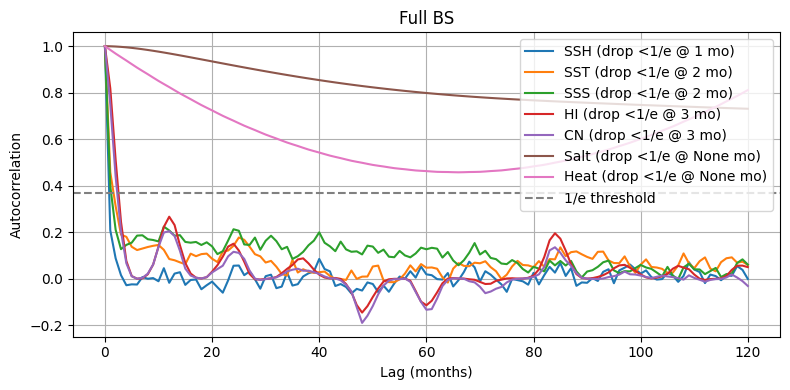

Lag (in months) where ACF first drops below 1/e:
SSH: 1
SST: 2
SSS: 2
HI: 3
CN: 3
Salt: Never drops below 1/e
Heat: Never drops below 1/e


In [ ]:
'''Plot autocorrelation functions for refrun'''

# Constants
MAX_LAG = 120  # 10 years * 12 months
E_INV = 1 / np.e   # ≈ 0.3679


refrun_ssh_full_BS_ano  = (refrun_ssh_full_BS.groupby("time.month") - refrun_ssh_full_BS.groupby("time.month").mean(dim="time"))['SSH']
refrun_sst_full_BS_ano  = (refrun_sst_full_BS.groupby("time.month") - refrun_sst_full_BS.groupby("time.month").mean(dim="time"))['SST']
refrun_sss_full_BS_ano  = (refrun_sss_full_BS.groupby("time.month") - refrun_sss_full_BS.groupby("time.month").mean(dim="time"))['SSS']
refrun_ice_hi_full_BS_ano  = (refrun_ice_hi_full_BS.groupby("time.month") - refrun_ice_hi_full_BS.groupby("time.month").mean(dim="time"))['HI']
refrun_ice_cn_full_BS_ano  = (refrun_ice_cn_full_BS.groupby("time.month") - refrun_ice_cn_full_BS.groupby("time.month").mean(dim="time"))['CN'].sum(dim='ct')
refrun_heat_full_BS_ano  = (refrun_heat_full_BS.groupby("time.month") - refrun_heat_full_BS.groupby("time.month").mean(dim="time"))['Heat']
refrun_salt_full_BS_ano  = (refrun_salt_full_BS.groupby("time.month") - refrun_salt_full_BS.groupby("time.month").mean(dim="time"))['Salt']

# Load and rename datasets
datasets_full_BS = {
    "SSH": refrun_ssh_full_BS_ano,
    "SST": refrun_sst_full_BS_ano,
    "SSS": refrun_sss_full_BS_ano,
    "HI":  refrun_ice_hi_full_BS_ano,
    "CN":  refrun_ice_cn_full_BS_ano,
    "Salt": refrun_salt_full_BS_ano,
    "Heat": refrun_heat_full_BS_ano
}

# Set up plot
plt.figure(figsize=(8,4))
colors = plt.cm.tab10.colors
acf_decay_lags = {}

# Loop over each dataset
for i, (var_name, ds) in enumerate(datasets_full_BS.items()):

    # Compute ACF
    acf_vals = acf(ds.values, nlags=MAX_LAG, fft=True)

    # Find first lag where ACF drops below 1/e
    below = np.where(acf_vals < E_INV)[0]
    first_below = below[0] if len(below) > 0 else None
    acf_decay_lags[var_name] = first_below

    # Plot
    plt.plot(range(MAX_LAG + 1), acf_vals, label=f"{var_name} (drop <1/e @ {first_below} mo)", color=colors[i % len(colors)])

# Plot formatting
plt.axhline(E_INV, color='gray', linestyle='--', label='1/e threshold')
plt.xlabel("Lag (months)")
plt.ylabel("Autocorrelation")
plt.title("Full BS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print the decay lags
print("Lag (in months) where ACF first drops below 1/e:")
for var, lag in acf_decay_lags.items():
    print(f"{var}: {lag if lag is not None else 'Never drops below 1/e'}")

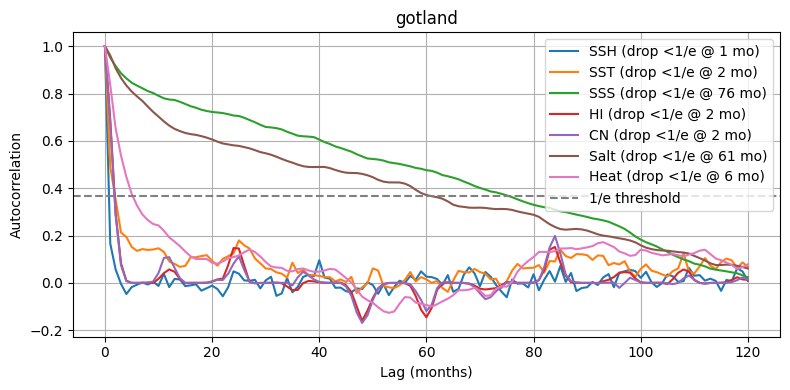

Lag (in months) where ACF first drops below 1/e:
SSH: 1
SST: 2
SSS: 76
HI: 2
CN: 2
Salt: 61
Heat: 6


In [ ]:
'''Plot autocorrelation functions for refrun'''

# Constants
MAX_LAG = 120  # 10 years * 12 months
E_INV = 1 / np.e   # ≈ 0.3679

refrun_ssh_gotland_ano  = (refrun_sfc_gotland.groupby("time.month") - refrun_sfc_gotland.groupby("time.month").mean(dim="time"))['SSH']
refrun_sst_gotland_ano  = (refrun_sfc_gotland.groupby("time.month") - refrun_sfc_gotland.groupby("time.month").mean(dim="time"))['SST']
refrun_sss_gotland_ano  = (refrun_sfc_gotland.groupby("time.month") - refrun_sfc_gotland.groupby("time.month").mean(dim="time"))['SSS']
refrun_ice_hi_gotland_ano  = (refrun_ice_gotland.groupby("time.month") - refrun_ice_gotland.groupby("time.month").mean(dim="time"))['HI']
refrun_ice_cn_gotland_ano  = (refrun_ice_gotland.groupby("time.month") - refrun_ice_gotland.groupby("time.month").mean(dim="time"))['CN'].sum(dim='ct')
refrun_heat_gotland_ano  = (refrun_heat_gotland.groupby("time.month") - refrun_heat_gotland.groupby("time.month").mean(dim="time"))['temp']
refrun_salt_gotland_ano  = (refrun_salt_gotland.groupby("time.month") - refrun_salt_gotland.groupby("time.month").mean(dim="time"))['salt']


# Load and rename datasets
datasets_gotland = {
    "SSH": refrun_ssh_gotland_ano,
    "SST": refrun_sst_gotland_ano,
    "SSS": refrun_sss_gotland_ano,
    "HI":  refrun_ice_hi_gotland_ano,
    "CN":  refrun_ice_cn_gotland_ano,
    "Salt": refrun_salt_gotland_ano,
    "Heat": refrun_heat_gotland_ano
}

# Set up plot
plt.figure(figsize=(8,4))
colors = plt.cm.tab10.colors
acf_decay_lags = {}

# Loop over each dataset
for i, (var_name, ds) in enumerate(datasets_gotland.items()):

    # Compute ACF
    acf_vals = acf(ds.values, nlags=MAX_LAG, fft=True)

    # Find first lag where ACF drops below 1/e
    below = np.where(acf_vals < E_INV)[0]
    first_below = below[0] if len(below) > 0 else None
    acf_decay_lags[var_name] = first_below

    # Plot
    plt.plot(range(MAX_LAG + 1), acf_vals, label=f"{var_name} (drop <1/e @ {first_below} mo)", color=colors[i % len(colors)])

# Plot formatting
plt.axhline(E_INV, color='gray', linestyle='--', label='1/e threshold')
plt.xlabel("Lag (months)")
plt.ylabel("Autocorrelation")
plt.title("gotland")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print the decay lags
print("Lag (in months) where ACF first drops below 1/e:")
for var, lag in acf_decay_lags.items():
    print(f"{var}: {lag if lag is not None else 'Never drops below 1/e'}")

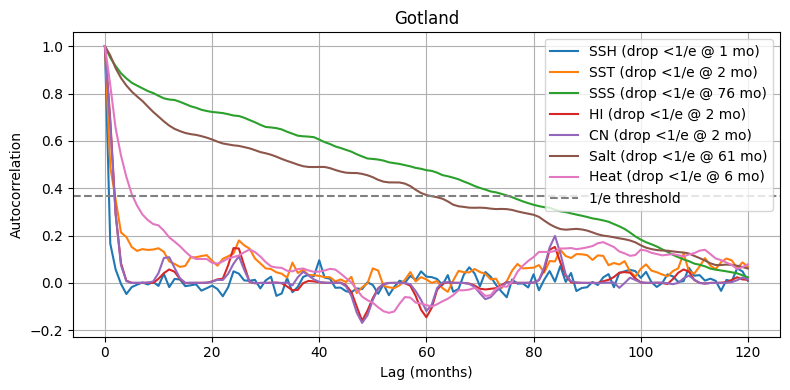

Lag (in months) where ACF first drops below 1/e:
SSH: 1
SST: 2
SSS: 76
HI: 2
CN: 2
Salt: 61
Heat: 6


In [ ]:
'''Plot autocorrelation functions for refrun'''

# Constants
MAX_LAG = 120  # 10 years * 12 months
E_INV = 1 / np.e   # ≈ 0.3679

refrun_ssh_gotland_ano  = (refrun_sfc_gotland.groupby("time.month") - refrun_sfc_gotland.groupby("time.month").mean(dim="time"))['SSH']
refrun_sst_gotland_ano  = (refrun_sfc_gotland.groupby("time.month") - refrun_sfc_gotland.groupby("time.month").mean(dim="time"))['SST']
refrun_sss_gotland_ano  = (refrun_sfc_gotland.groupby("time.month") - refrun_sfc_gotland.groupby("time.month").mean(dim="time"))['SSS']
refrun_ice_hi_gotland_ano  = (refrun_ice_gotland.groupby("time.month") - refrun_ice_gotland.groupby("time.month").mean(dim="time"))['HI']
refrun_ice_cn_gotland_ano  = (refrun_ice_gotland.groupby("time.month") - refrun_ice_gotland.groupby("time.month").mean(dim="time"))['CN'].sum(dim='ct')
refrun_heat_gotland_ano  = (refrun_heat_gotland.groupby("time.month") - refrun_heat_gotland.groupby("time.month").mean(dim="time"))['temp']
refrun_salt_gotland_ano  = (refrun_salt_gotland.groupby("time.month") - refrun_salt_gotland.groupby("time.month").mean(dim="time"))['salt']


# Load and rename datasets
datasets_Gotland = {
    "SSH": refrun_ssh_gotland_ano,
    "SST": refrun_sst_gotland_ano,
    "SSS": refrun_sss_gotland_ano,
    "HI":  refrun_ice_hi_gotland_ano,
    "CN":  refrun_ice_cn_gotland_ano,
    "Salt": refrun_salt_gotland_ano,
    "Heat": refrun_heat_gotland_ano
}

# Set up plot
plt.figure(figsize=(8,4))
colors = plt.cm.tab10.colors
acf_decay_lags = {}

# Loop over each dataset
for i, (var_name, ds) in enumerate(datasets_Gotland.items()):

    # Compute ACF
    acf_vals = acf(ds.values, nlags=MAX_LAG, fft=True)

    # Find first lag where ACF drops below 1/e
    below = np.where(acf_vals < E_INV)[0]
    first_below = below[0] if len(below) > 0 else None
    acf_decay_lags[var_name] = first_below

    # Plot
    plt.plot(range(MAX_LAG + 1), acf_vals, label=f"{var_name} (drop <1/e @ {first_below} mo)", color=colors[i % len(colors)])

# Plot formatting
plt.axhline(E_INV, color='gray', linestyle='--', label='1/e threshold')
plt.xlabel("Lag (months)")
plt.ylabel("Autocorrelation")
plt.title("Gotland")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print the decay lags
print("Lag (in months) where ACF first drops below 1/e:")
for var, lag in acf_decay_lags.items():
    print(f"{var}: {lag if lag is not None else 'Never drops below 1/e'}")

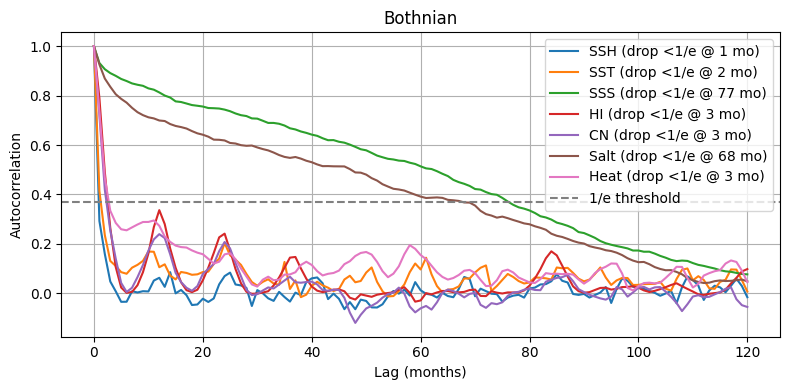

Lag (in months) where ACF first drops below 1/e:
SSH: 1
SST: 2
SSS: 77
HI: 3
CN: 3
Salt: 68
Heat: 3


In [ ]:
'''Plot autocorrelation functions for refrun'''

# Constants
MAX_LAG = 120  # 10 years * 12 months
E_INV = 1 / np.e   # ≈ 0.3679

refrun_ssh_bothnian_ano  = (refrun_sfc_bothnian.groupby("time.month") - refrun_sfc_bothnian.groupby("time.month").mean(dim="time"))['SSH']
refrun_sst_bothnian_ano  = (refrun_sfc_bothnian.groupby("time.month") - refrun_sfc_bothnian.groupby("time.month").mean(dim="time"))['SST']
refrun_sss_bothnian_ano  = (refrun_sfc_bothnian.groupby("time.month") - refrun_sfc_bothnian.groupby("time.month").mean(dim="time"))['SSS']
refrun_ice_hi_bothnian_ano  = (refrun_ice_bothnian.groupby("time.month") - refrun_ice_bothnian.groupby("time.month").mean(dim="time"))['HI']
refrun_ice_cn_bothnian_ano  = (refrun_ice_bothnian.groupby("time.month") - refrun_ice_bothnian.groupby("time.month").mean(dim="time"))['CN'].sum(dim='ct')
refrun_heat_bothnian_ano  = (refrun_heat_bothnian.groupby("time.month") - refrun_heat_bothnian.groupby("time.month").mean(dim="time"))['temp']
refrun_salt_bothnian_ano  = (refrun_salt_bothnian.groupby("time.month") - refrun_salt_bothnian.groupby("time.month").mean(dim="time"))['salt']

# Load and rename datasets
datasets_Bothnian = {
    "SSH": refrun_ssh_bothnian_ano,
    "SST": refrun_sst_bothnian_ano,
    "SSS": refrun_sss_bothnian_ano,
    "HI":  refrun_ice_hi_bothnian_ano,
    "CN":  refrun_ice_cn_bothnian_ano,
    "Salt": refrun_salt_bothnian_ano,
    "Heat": refrun_heat_bothnian_ano
}

# Set up plot
plt.figure(figsize=(8,4))
colors = plt.cm.tab10.colors
acf_decay_lags = {}

# Loop over each dataset
for i, (var_name, ds) in enumerate(datasets_Bothnian.items()):

    # Compute ACF
    acf_vals = acf(ds.values, nlags=MAX_LAG, fft=True)

    # Find first lag where ACF drops below 1/e
    below = np.where(acf_vals < E_INV)[0]
    first_below = below[0] if len(below) > 0 else None
    acf_decay_lags[var_name] = first_below

    # Plot
    plt.plot(range(MAX_LAG + 1), acf_vals, label=f"{var_name} (drop <1/e @ {first_below} mo)", color=colors[i % len(colors)])

# Plot formatting
plt.axhline(E_INV, color='gray', linestyle='--', label='1/e threshold')
plt.xlabel("Lag (months)")
plt.ylabel("Autocorrelation")
plt.title("Bothnian")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print the decay lags
print("Lag (in months) where ACF first drops below 1/e:")
for var, lag in acf_decay_lags.items():
    print(f"{var}: {lag if lag is not None else 'Never drops below 1/e'}")

#### Total Salt Full BS: 6 10 20 40

In [ ]:
# '''Determine thresholds & years for 1980 past 10 year Salt'''
# max_val = float('-inf')
# max_path = ()

# for category, strength_dict in skill_data_full_BS['MSSS']['Salt']['1y'].items():
#     for subcategory, values in strength_dict.items():
#         for i, val in enumerate(values):
#             if val > max_val:
#                 max_val = val
#                 max_path = (category.strip(), subcategory.strip(), i)

# print("Full BS maximum value:", max_val)
# print("Location:", f"{max_path[0]} → {max_path[1]} → index {max_path[2]}")

In [ ]:
'''Determine std(blocksize): Run bootstrap for blocksizes 1-60 for 1980 past 10y Salt (ca. 1.5min)'''

########################################################################################################################################################
# Rewritten bootstrap function
def overlapping_block_bootstrap_test(data_timeseries, refrun_timeseries, blocksize, random_seed=8):
    if random_seed is not None:
        np.random.seed(random_seed)

    n_bootstrap = 1000   

    # Generate all overlapping blocks (start at every possible index)
    n             = len(data_timeseries)
    n_blocks      = int(np.ceil(n / blocksize)) # rounds up the number of used blocks, ie 119/60 -> 2.
    max_start     = n - blocksize + 1
    blocks_data   = np.array([data_timeseries[i:i + blocksize] for i in range(max_start)])
    blocks_refrun = np.array([refrun_timeseries[i:i + blocksize] for i in range(max_start)])

    # Compute original pearsonr and MSSS
    original_corr, _ = pearsonr(data_timeseries, refrun_timeseries)
    original_MSSS    = (1 - ( np.mean((data_timeseries - refrun_timeseries)**2) ) / ( np.mean((refrun_timeseries - np.mean(refrun_timeseries))**2) )).values
    
    bootstrapped_corrs = np.empty(n_bootstrap)
    bootstrapped_MSSSs = np.empty(n_bootstrap)
        
    # bootstrapping loop (n_bootstrap times)
    for i in range(n_bootstrap):
        # Sample block indices with replacement
        idx = np.random.randint(0, max_start, size=n_blocks)
        # Concatenate the blocks to form bootstrap sample
        data_boot   = blocks_data[idx].reshape(-1)[:n]
        refrun_boot = blocks_refrun[idx].reshape(-1)[:n]
        # Compute bootstrapped CC and MSSS
        bootstrapped_corrs[i], _ = pearsonr(data_boot, refrun_boot)
        bootstrapped_MSSSs[i]    = 1 - ( np.mean((data_boot - refrun_boot)**2) ) / ( np.mean((refrun_boot - np.mean(refrun_boot))**2) )

    # one-tailed pvalue with null hypothesis of CC=0 and MSSS=0
    p_value_corr = np.mean(bootstrapped_corrs >= original_corr)
    p_value_MSSS = np.mean(bootstrapped_MSSSs >= original_MSSS)
    std_bootstr_corrs = bootstrapped_corrs.std()
    std_bootstr_MSSSs = bootstrapped_MSSSs.std()
    return p_value_corr, p_value_MSSS, std_bootstr_corrs, std_bootstr_MSSSs


# timescale = 10y, look at future past 10y salt strong neg
thres_years_salt_full_BS = [1977., 1978., 1979., 1980., 1981., 1982., 1983., 1984., 1985.,1986.]

stds_MSSSs_1y_salt_full_BS = []
stds_corrs_1y_salt_full_BS = []
stds_MSSSs_5y_salt_full_BS = []
stds_corrs_5y_salt_full_BS = []
stds_MSSSs_6to10y_salt_full_BS = []
stds_corrs_6to10y_salt_full_BS = []
stds_MSSSs_10y_salt_full_BS = []
stds_corrs_10y_salt_full_BS = []
for i in range(1,12):
    print(f'Blocksize {i}')
    _, _, std_corrs, std_MSSSs  = overlapping_block_bootstrap_test(data_timeseries=ds_salt_full_BS_ano.sel(EY=1980).sel(year=thres_years_salt_full_BS).sel(month=slice(1,12)).mean(dim='year'), refrun_timeseries=refruns_salt_full_BS_ano[1980].sel(month=slice(1,12)), blocksize=i)
    stds_corrs_1y_salt_full_BS = np.append(stds_corrs_1y_salt_full_BS,std_corrs)
    stds_MSSSs_1y_salt_full_BS = np.append(stds_MSSSs_1y_salt_full_BS,std_MSSSs)
for i in range(1,61):
    print(f'Blocksize = {i}')
    _, _, std_corrs, std_MSSSs      = overlapping_block_bootstrap_test(data_timeseries=ds_salt_full_BS_ano.sel(EY=1980).sel(year=thres_years_salt_full_BS).sel(month=slice(60,119)).mean(dim='year'), refrun_timeseries=refruns_salt_full_BS_ano[1980].sel(month=slice(60,119)), blocksize=i)
    stds_corrs_6to10y_salt_full_BS = np.append(stds_corrs_6to10y_salt_full_BS,std_corrs)
    stds_MSSSs_6to10y_salt_full_BS = np.append(stds_MSSSs_6to10y_salt_full_BS,std_MSSSs)
    _, _, std_corrs, std_MSSSs  = overlapping_block_bootstrap_test(data_timeseries=ds_salt_full_BS_ano.sel(EY=1980).sel(year=thres_years_salt_full_BS).sel(month=slice(1,60)).mean(dim='year'), refrun_timeseries=refruns_salt_full_BS_ano[1980].sel(month=slice(1,60)), blocksize=i)
    stds_corrs_5y_salt_full_BS = np.append(stds_corrs_5y_salt_full_BS,std_corrs)
    stds_MSSSs_5y_salt_full_BS = np.append(stds_MSSSs_5y_salt_full_BS,std_MSSSs)
    _, _, std_corrs, std_MSSSs   = overlapping_block_bootstrap_test(data_timeseries=ds_salt_full_BS_ano.sel(EY=1980).sel(year=thres_years_salt_full_BS).mean(dim='year'), refrun_timeseries=refruns_salt_full_BS_ano[1980], blocksize=i)
    stds_corrs_10y_salt_full_BS = np.append(stds_corrs_10y_salt_full_BS,std_corrs)
    stds_MSSSs_10y_salt_full_BS = np.append(stds_MSSSs_10y_salt_full_BS,std_MSSSs)

Blocksize 1


Blocksize 2
Blocksize 3
Blocksize 4
Blocksize 5
Blocksize 6
Blocksize 7
Blocksize 8
Blocksize 9
Blocksize 10
Blocksize 11
Blocksize = 1
Blocksize = 2
Blocksize = 3
Blocksize = 4
Blocksize = 5
Blocksize = 6
Blocksize = 7
Blocksize = 8
Blocksize = 9
Blocksize = 10
Blocksize = 11
Blocksize = 12
Blocksize = 13
Blocksize = 14
Blocksize = 15
Blocksize = 16
Blocksize = 17
Blocksize = 18
Blocksize = 19
Blocksize = 20
Blocksize = 21
Blocksize = 22
Blocksize = 23
Blocksize = 24
Blocksize = 25
Blocksize = 26
Blocksize = 27
Blocksize = 28
Blocksize = 29
Blocksize = 30
Blocksize = 31
Blocksize = 32
Blocksize = 33
Blocksize = 34
Blocksize = 35
Blocksize = 36
Blocksize = 37
Blocksize = 38
Blocksize = 39
Blocksize = 40
Blocksize = 41
Blocksize = 42
Blocksize = 43
Blocksize = 44
Blocksize = 45
Blocksize = 46
Blocksize = 47
Blocksize = 48
Blocksize = 49
Blocksize = 50
Blocksize = 51
Blocksize = 52
Blocksize = 53
Blocksize = 54
Blocksize = 55
Blocksize = 56
Blocksize = 57
Blocksize = 58
Blocksize = 59
Bl

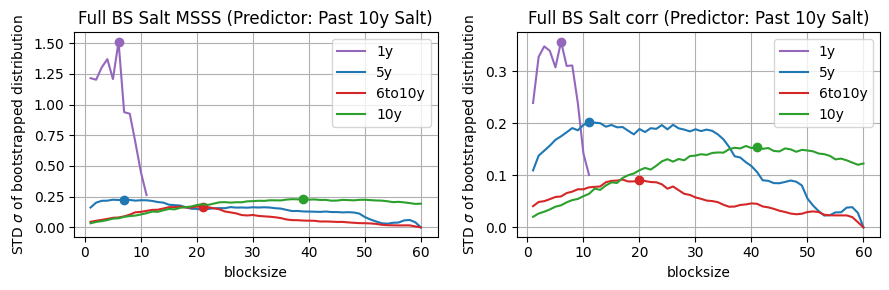

In [ ]:
'''Plot standard errors as function of blocksize'''
fig, ax = plt.subplots(1, 2, figsize=(9,3))
ax[0].plot(range(1, 12), stds_MSSSs_1y_salt_full_BS, label='1y', c='tab:purple')
ax[0].plot(6, stds_MSSSs_1y_salt_full_BS[5], 'o', c='tab:purple')
ax[0].plot(range(1, 61), stds_MSSSs_5y_salt_full_BS, label='5y', c='tab:blue')
ax[0].plot(7, stds_MSSSs_5y_salt_full_BS[6], 'o', c='tab:blue')
ax[0].plot(range(1, 61), stds_MSSSs_6to10y_salt_full_BS, label='6to10y', c='tab:red')
ax[0].plot(21, stds_MSSSs_6to10y_salt_full_BS[20], 'o', c='tab:red')
ax[0].plot(range(1, 61), stds_MSSSs_10y_salt_full_BS, label='10y', c='tab:green')
ax[0].plot(39, stds_MSSSs_10y_salt_full_BS[38], 'o', c='tab:green')
ax[0].legend()
ax[0].grid()
ax[0].set_xlabel('blocksize')
ax[0].set_ylabel(r'STD $\sigma$ of bootstrapped distribution')
ax[0].set_title('Full BS Salt MSSS (Predictor: Past 10y Salt)')
ax[1].plot(range(1, 12), stds_corrs_1y_salt_full_BS, label='1y', c='tab:purple')
ax[1].plot(6, stds_corrs_1y_salt_full_BS[5], 'o', c='tab:purple')
ax[1].plot(range(1, 61), stds_corrs_5y_salt_full_BS, label='5y', c='tab:blue')
ax[1].plot(11, stds_corrs_5y_salt_full_BS[10], 'o', c='tab:blue')
ax[1].plot(range(1, 61), stds_corrs_6to10y_salt_full_BS, label='6to10y', c='tab:red')
ax[1].plot(20, stds_corrs_6to10y_salt_full_BS[19], 'o', c='tab:red')
ax[1].plot(range(1, 61), stds_corrs_10y_salt_full_BS, label='10y', c='tab:green')
ax[1].plot(41, stds_corrs_10y_salt_full_BS[40], 'o', c='tab:green')
ax[1].legend()
ax[1].grid()
ax[1].set_xlabel('blocksize')
ax[1].set_ylabel(r'STD $\sigma$ of bootstrapped distribution')
ax[1].set_title('Full BS Salt corr (Predictor: Past 10y Salt)')
plt.tight_layout()
plt.show();

#### Total Heat Full BS: 3 10 10 10

In [ ]:
# '''Determine thresholds & years for 1960 int. Heat'''
# max_val = float('-inf')
# max_path = ()

# for category, strength_dict in skill_data_full_BS['MSSS']['Salt']['1y'].items():
#     for subcategory, values in strength_dict.items():
#         for i, val in enumerate(values):
#             if val > max_val:
#                 max_val = val
#                 max_path = (category.strip(), subcategory.strip(), i)

# # print("Full BS maximum value:", max_val)
# # print("Location:", f"{max_path[0]} → {max_path[1]} → index {max_path[2]}")


# print(get_predictor_thresholds(heat_0101_full_BS,detrend=1,EY=1960))

In [ ]:
'''Determine std(blocksize): Run bootstrap for blocksizes 1-60 for 1960 init. Heat (ca. 3min)'''

thres_years_heat_full_BS = [1949., 1950., 1952., 1954., 1960., 1973., 1975., 2001., 2007.]

stds_MSSSs_1y_heat_full_BS = []
stds_corrs_1y_heat_full_BS = []
stds_MSSSs_5y_heat_full_BS = []
stds_corrs_5y_heat_full_BS = []
stds_MSSSs_6to10y_heat_full_BS = []
stds_corrs_6to10y_heat_full_BS = []
stds_MSSSs_10y_heat_full_BS = []
stds_corrs_10y_heat_full_BS = []
for i in range(1,12):
    print(f'Blocksize {i}')
    _, _, std_corrs, std_MSSSs  = overlapping_block_bootstrap_test(data_timeseries=ds_heat_full_BS_ano.sel(EY=1960).sel(year=thres_years_heat_full_BS).sel(month=slice(1,12)).mean(dim='year'), refrun_timeseries=refruns_heat_full_BS_ano[1960].sel(month=slice(1,12)), blocksize=i)
    stds_corrs_1y_heat_full_BS = np.append(stds_corrs_1y_heat_full_BS,std_corrs)
    stds_MSSSs_1y_heat_full_BS = np.append(stds_MSSSs_1y_heat_full_BS,std_MSSSs)
for i in range(1,61):
    print(f'Blocksize = {i}')
    _, _, std_corrs, std_MSSSs      = overlapping_block_bootstrap_test(data_timeseries=ds_heat_full_BS_ano.sel(EY=1960).sel(year=thres_years_heat_full_BS).sel(month=slice(60,119)).mean(dim='year'), refrun_timeseries=refruns_heat_full_BS_ano[1960].sel(month=slice(60,119)), blocksize=i)
    stds_corrs_6to10y_heat_full_BS = np.append(stds_corrs_6to10y_heat_full_BS,std_corrs)
    stds_MSSSs_6to10y_heat_full_BS = np.append(stds_MSSSs_6to10y_heat_full_BS,std_MSSSs)
    _, _, std_corrs, std_MSSSs  = overlapping_block_bootstrap_test(data_timeseries=ds_heat_full_BS_ano.sel(EY=1960).sel(year=thres_years_heat_full_BS).sel(month=slice(1,60)).mean(dim='year'), refrun_timeseries=refruns_heat_full_BS_ano[1960].sel(month=slice(1,60)), blocksize=i)
    stds_corrs_5y_heat_full_BS = np.append(stds_corrs_5y_heat_full_BS,std_corrs)
    stds_MSSSs_5y_heat_full_BS = np.append(stds_MSSSs_5y_heat_full_BS,std_MSSSs)
    _, _, std_corrs, std_MSSSs   = overlapping_block_bootstrap_test(data_timeseries=ds_heat_full_BS_ano.sel(EY=1960).sel(year=thres_years_heat_full_BS).mean(dim='year'), refrun_timeseries=refruns_heat_full_BS_ano[1960], blocksize=i)
    stds_corrs_10y_heat_full_BS = np.append(stds_corrs_10y_heat_full_BS,std_corrs)
    stds_MSSSs_10y_heat_full_BS = np.append(stds_MSSSs_10y_heat_full_BS,std_MSSSs)

Blocksize 1
Blocksize 2
Blocksize 3
Blocksize 4
Blocksize 5
Blocksize 6
Blocksize 7
Blocksize 8
Blocksize 9
Blocksize 10
Blocksize 11
Blocksize = 1
Blocksize = 2
Blocksize = 3
Blocksize = 4
Blocksize = 5
Blocksize = 6
Blocksize = 7
Blocksize = 8
Blocksize = 9
Blocksize = 10
Blocksize = 11
Blocksize = 12
Blocksize = 13
Blocksize = 14
Blocksize = 15
Blocksize = 16
Blocksize = 17
Blocksize = 18
Blocksize = 19
Blocksize = 20
Blocksize = 21
Blocksize = 22
Blocksize = 23
Blocksize = 24
Blocksize = 25
Blocksize = 26
Blocksize = 27
Blocksize = 28
Blocksize = 29
Blocksize = 30
Blocksize = 31
Blocksize = 32
Blocksize = 33
Blocksize = 34
Blocksize = 35
Blocksize = 36
Blocksize = 37
Blocksize = 38
Blocksize = 39
Blocksize = 40
Blocksize = 41
Blocksize = 42
Blocksize = 43
Blocksize = 44
Blocksize = 45
Blocksize = 46
Blocksize = 47
Blocksize = 48
Blocksize = 49
Blocksize = 50
Blocksize = 51
Blocksize = 52
Blocksize = 53
Blocksize = 54
Blocksize = 55
Blocksize = 56
Blocksize = 57
Blocksize = 58
Block

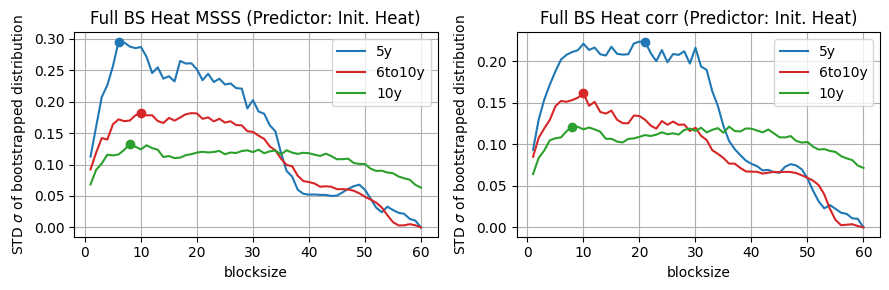

In [ ]:
'''Plot standard errors as function of blocksize'''
fig, ax = plt.subplots(1, 2, figsize=(9,3))
# ax[0].plot(range(1, 12), stds_MSSSs_1y_heat_full_BS, label='1y', c='tab:purple')
# ax[0].plot(3, stds_MSSSs_1y_heat_full_BS[2], 'o', c='tab:purple')
ax[0].plot(range(1, 61), stds_MSSSs_5y_heat_full_BS, label='5y', c='tab:blue')
ax[0].plot(6, stds_MSSSs_5y_heat_full_BS[5], 'o', c='tab:blue')
ax[0].plot(range(1, 61), stds_MSSSs_6to10y_heat_full_BS, label='6to10y', c='tab:red')
ax[0].plot(10, stds_MSSSs_6to10y_heat_full_BS[9], 'o', c='tab:red')
ax[0].plot(range(1, 61), stds_MSSSs_10y_heat_full_BS, label='10y', c='tab:green')
ax[0].plot(8, stds_MSSSs_10y_heat_full_BS[7], 'o', c='tab:green')
ax[0].legend()
ax[0].grid()
ax[0].set_xlabel('blocksize')
ax[0].set_ylabel(r'STD $\sigma$ of bootstrapped distribution')
ax[0].set_title('Full BS Heat MSSS (Predictor: Init. Heat)')
# ax[1].plot(range(1, 12), stds_corrs_1y_heat_full_BS, label='1y', c='tab:purple')
# ax[1].plot(2, stds_corrs_1y_heat_full_BS[1], 'o', c='tab:purple')
ax[1].plot(range(1, 61), stds_corrs_5y_heat_full_BS, label='5y', c='tab:blue')
ax[1].plot(21, stds_corrs_5y_heat_full_BS[20], 'o', c='tab:blue')
ax[1].plot(range(1, 61), stds_corrs_6to10y_heat_full_BS, label='6to10y', c='tab:red')
ax[1].plot(10, stds_corrs_6to10y_heat_full_BS[9], 'o', c='tab:red')
ax[1].plot(range(1, 61), stds_corrs_10y_heat_full_BS, label='10y', c='tab:green')
ax[1].plot(8, stds_corrs_10y_heat_full_BS[7], 'o', c='tab:green')
ax[1].legend()
ax[1].grid()
ax[1].set_xlabel('blocksize')
ax[1].set_ylabel(r'STD $\sigma$ of bootstrapped distribution')
ax[1].set_title('Full BS Heat corr (Predictor: Init. Heat)')
plt.tight_layout()
plt.show();

#### SSS Gotland: 4 20 10 40

In [ ]:
# '''Determine thresholds & years for 2000 past 3y AMV'''
# max_val = float('-inf')
# max_path = ()

# for category, strength_dict in skill_data_Gotland['MSSS']['SSS']['10y']['Past 3y AMV']["     Mod pos"]#.items():
#     for subcategory, values in strength_dict.items():
#         for i, val in enumerate(values):
#             if val > max_val:
#                 max_val = val
#                 max_path = (category.strip(), subcategory.strip(), i)

# print("Full BS maximum value:", max_val)
# print("Location:", f"{max_path[0]} → {max_path[1]} → index {max_path[2]}")


print(get_predictor_thresholds(ds_AMV_past_3y,detrend=0,EY=2000))

([(' Strong pos', array([1954., 1955., 2006., 2007., 2008.])), ('     Mod pos', array([1953., 1956., 1960., 1961., 1962., 1963., 1999., 2000., 2001.,
       2004., 2005., 2009.])), ('       Neutral', array([1948., 1949., 1950., 1951., 1952., 1957., 1958., 1959., 1964.,
       1965., 1990., 1991., 1997., 1998., 2002., 2003., 2010.])), ('     Mod neg', array([1966., 1967., 1968., 1969., 1970., 1971., 1972., 1981., 1982.,
       1983., 1984., 1989., 1992., 1993., 1996.])), (' Strong neg', array([1973., 1974., 1975., 1976., 1977., 1978., 1979., 1980., 1985.,
       1986., 1987., 1988., 1994., 1995.]))], '     Mod pos', array([1953., 1956., 1960., 1961., 1962., 1963., 1999., 2000., 2001.,
       2004., 2005., 2009.]))


In [ ]:
'''Determine std(blocksize): Run bootstrap for blocksizes 1-60 for 2000 past 3y AMV (ca. 2min)'''

thres_years_sss_gotland = [1953., 1956., 1960., 1961., 1962., 1963., 1999., 2000., 2001., 2004., 2005., 2009.]

stds_MSSSs_1y_sss_gotland = []
stds_corrs_1y_sss_gotland = []
stds_MSSSs_5y_sss_gotland = []
stds_corrs_5y_sss_gotland = []
stds_MSSSs_6to10y_sss_gotland = []
stds_corrs_6to10y_sss_gotland = []
stds_MSSSs_10y_sss_gotland = []
stds_corrs_10y_sss_gotland = []
for i in range(1,12):
    print(f'Blocksize {i}')
    _, _, std_corrs, std_MSSSs  = overlapping_block_bootstrap_test(data_timeseries=ds_sss_Gotland_ano.sel(EY=2000).sel(year=thres_years_sss_gotland).sel(month=slice(1,12)).mean(dim='year'), refrun_timeseries=refruns_sss_Gotland_ano[2000].sel(month=slice(1,12)), blocksize=i)
    stds_corrs_1y_sss_gotland = np.append(stds_corrs_1y_sss_gotland,std_corrs)
    stds_MSSSs_1y_sss_gotland = np.append(stds_MSSSs_1y_sss_gotland,std_MSSSs)
for i in range(1,61):
    print(f'Blocksize = {i}')
    _, _, std_corrs, std_MSSSs      = overlapping_block_bootstrap_test(data_timeseries=ds_sss_Gotland_ano.sel(EY=2000).sel(year=thres_years_sss_gotland).sel(month=slice(60,119)).mean(dim='year'), refrun_timeseries=refruns_sss_Gotland_ano[2000].sel(month=slice(60,119)), blocksize=i)
    stds_corrs_6to10y_sss_gotland = np.append(stds_corrs_6to10y_sss_gotland,std_corrs)
    stds_MSSSs_6to10y_sss_gotland = np.append(stds_MSSSs_6to10y_sss_gotland,std_MSSSs)
    _, _, std_corrs, std_MSSSs  = overlapping_block_bootstrap_test(data_timeseries=ds_sss_Gotland_ano.sel(EY=2000).sel(year=thres_years_sss_gotland).sel(month=slice(1,60)).mean(dim='year'), refrun_timeseries=refruns_sss_Gotland_ano[2000].sel(month=slice(1,60)), blocksize=i)
    stds_corrs_5y_sss_gotland = np.append(stds_corrs_5y_sss_gotland,std_corrs)
    stds_MSSSs_5y_sss_gotland = np.append(stds_MSSSs_5y_sss_gotland,std_MSSSs)
    _, _, std_corrs, std_MSSSs   = overlapping_block_bootstrap_test(data_timeseries=ds_sss_Gotland_ano.sel(EY=2000).sel(year=thres_years_sss_gotland).mean(dim='year'), refrun_timeseries=refruns_sss_Gotland_ano[2000], blocksize=i)
    stds_corrs_10y_sss_gotland = np.append(stds_corrs_10y_sss_gotland,std_corrs)
    stds_MSSSs_10y_sss_gotland = np.append(stds_MSSSs_10y_sss_gotland,std_MSSSs)

Blocksize 1


Blocksize 2
Blocksize 3
Blocksize 4
Blocksize 5
Blocksize 6
Blocksize 7
Blocksize 8
Blocksize 9
Blocksize 10
Blocksize 11
Blocksize = 1
Blocksize = 2
Blocksize = 3
Blocksize = 4
Blocksize = 5
Blocksize = 6
Blocksize = 7
Blocksize = 8
Blocksize = 9
Blocksize = 10
Blocksize = 11
Blocksize = 12
Blocksize = 13
Blocksize = 14
Blocksize = 15
Blocksize = 16
Blocksize = 17
Blocksize = 18
Blocksize = 19
Blocksize = 20
Blocksize = 21
Blocksize = 22
Blocksize = 23
Blocksize = 24
Blocksize = 25
Blocksize = 26
Blocksize = 27
Blocksize = 28
Blocksize = 29
Blocksize = 30
Blocksize = 31
Blocksize = 32
Blocksize = 33
Blocksize = 34
Blocksize = 35
Blocksize = 36
Blocksize = 37
Blocksize = 38
Blocksize = 39
Blocksize = 40
Blocksize = 41
Blocksize = 42
Blocksize = 43
Blocksize = 44
Blocksize = 45
Blocksize = 46
Blocksize = 47
Blocksize = 48
Blocksize = 49
Blocksize = 50
Blocksize = 51
Blocksize = 52
Blocksize = 53
Blocksize = 54
Blocksize = 55
Blocksize = 56
Blocksize = 57
Blocksize = 58
Blocksize = 59
Bl

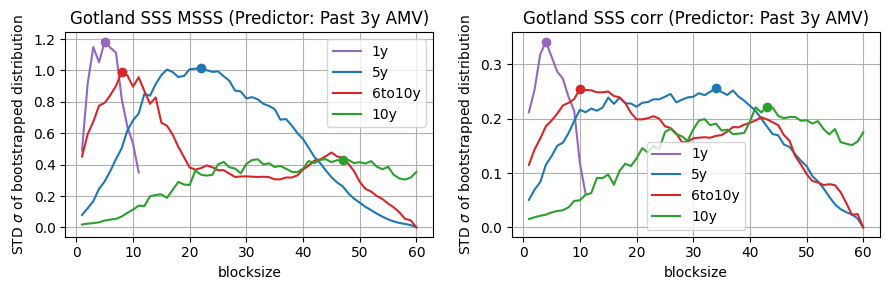

In [ ]:
'''Plot standard errors as function of blocksize'''
fig, ax = plt.subplots(1, 2, figsize=(9,3))
ax[0].plot(range(1, 12), stds_MSSSs_1y_sss_gotland, label='1y', c='tab:purple')
ax[0].plot(5, stds_MSSSs_1y_sss_gotland[4], 'o', c='tab:purple')
ax[0].plot(range(1, 61), stds_MSSSs_5y_sss_gotland, label='5y', c='tab:blue')
ax[0].plot(22, stds_MSSSs_5y_sss_gotland[21], 'o', c='tab:blue')
ax[0].plot(range(1, 61), stds_MSSSs_6to10y_sss_gotland, label='6to10y', c='tab:red')
ax[0].plot(8, stds_MSSSs_6to10y_sss_gotland[7], 'o', c='tab:red')
ax[0].plot(range(1, 61), stds_MSSSs_10y_sss_gotland, label='10y', c='tab:green')
ax[0].plot(47, stds_MSSSs_10y_sss_gotland[46], 'o', c='tab:green')
ax[0].legend()
ax[0].grid()
ax[0].set_xlabel('blocksize')
ax[0].set_ylabel(r'STD $\sigma$ of bootstrapped distribution')
ax[0].set_title('Gotland SSS MSSS (Predictor: Past 3y AMV)')
ax[1].plot(range(1, 12), stds_corrs_1y_sss_gotland, label='1y', c='tab:purple')
ax[1].plot(4, stds_corrs_1y_sss_gotland[3], 'o', c='tab:purple')
ax[1].plot(range(1, 61), stds_corrs_5y_sss_gotland, label='5y', c='tab:blue')
ax[1].plot(34, stds_corrs_5y_sss_gotland[33], 'o', c='tab:blue')
ax[1].plot(range(1, 61), stds_corrs_6to10y_sss_gotland, label='6to10y', c='tab:red')
ax[1].plot(10, stds_corrs_6to10y_sss_gotland[9], 'o', c='tab:red')
ax[1].plot(range(1, 61), stds_corrs_10y_sss_gotland, label='10y', c='tab:green')
ax[1].plot(43, stds_corrs_10y_sss_gotland[42], 'o', c='tab:green')
ax[1].legend()
ax[1].grid()
ax[1].set_xlabel('blocksize')
ax[1].set_ylabel(r'STD $\sigma$ of bootstrapped distribution')
ax[1].set_title('Gotland SSS corr (Predictor: Past 3y AMV)')
plt.tight_layout()
plt.show();
# 4 20 10 40

#### Total Salt Gotland: 3 20 15 40

In [ ]:
# '''Determine thresholds & years for 1980 past&future 10y AMV'''
# max_val = float('-inf')
# max_path = ()

# for category, strength_dict in skill_data_Gotland['MSSS']['Salt']['10y'].items():
#     for subcategory, values in strength_dict.items():
#         for i, val in enumerate(values):
#             if val > max_val:
#                 max_val = val
#                 max_path = (category.strip(), subcategory.strip(), i)

# print("Full BS maximum value:", max_val)
# print("Location:", f"{max_path[0]} → {max_path[1]} → index {max_path[2]}")


# print(get_predictor_thresholds(ds_AMV_past_and_future_10y,detrend=0,EY=1980))

In [ ]:
'''Determine std(blocksize): Run bootstrap for blocksizes 1-60 for 1980 past&future 10y AMV (ca. 2min)'''

thres_years_salt_gotland = [1971., 1972., 1973., 1974., 1975., 1976., 1977., 1978., 1979., 1980., 1981., 1982., 1983., 1984., 1985., 1986.]

stds_MSSSs_1y_salt_gotland = []
stds_corrs_1y_salt_gotland = []
stds_MSSSs_5y_salt_gotland = []
stds_corrs_5y_salt_gotland = []
stds_MSSSs_6to10y_salt_gotland = []
stds_corrs_6to10y_salt_gotland = []
stds_MSSSs_10y_salt_gotland = []
stds_corrs_10y_salt_gotland = []
for i in range(1,12):
    print(f'Blocksize {i}')
    _, _, std_corrs, std_MSSSs  = overlapping_block_bootstrap_test(data_timeseries=ds_salt_Gotland_ano.sel(EY=1980).sel(year=thres_years_salt_gotland).sel(month=slice(1,12)).mean(dim='year'), refrun_timeseries=refruns_salt_Gotland_ano[1980].sel(month=slice(1,12)), blocksize=i)
    stds_corrs_1y_salt_gotland = np.append(stds_corrs_1y_salt_gotland,std_corrs)
    stds_MSSSs_1y_salt_gotland = np.append(stds_MSSSs_1y_salt_gotland,std_MSSSs)
for i in range(1,61):
    print(f'Blocksize = {i}')
    _, _, std_corrs, std_MSSSs      = overlapping_block_bootstrap_test(data_timeseries=ds_salt_Gotland_ano.sel(EY=1980).sel(year=thres_years_salt_gotland).sel(month=slice(60,119)).mean(dim='year'), refrun_timeseries=refruns_salt_Gotland_ano[1980].sel(month=slice(60,119)), blocksize=i)
    stds_corrs_6to10y_salt_gotland = np.append(stds_corrs_6to10y_salt_gotland,std_corrs)
    stds_MSSSs_6to10y_salt_gotland = np.append(stds_MSSSs_6to10y_salt_gotland,std_MSSSs)
    _, _, std_corrs, std_MSSSs  = overlapping_block_bootstrap_test(data_timeseries=ds_salt_Gotland_ano.sel(EY=1980).sel(year=thres_years_salt_gotland).sel(month=slice(1,60)).mean(dim='year'), refrun_timeseries=refruns_salt_Gotland_ano[1980].sel(month=slice(1,60)), blocksize=i)
    stds_corrs_5y_salt_gotland = np.append(stds_corrs_5y_salt_gotland,std_corrs)
    stds_MSSSs_5y_salt_gotland = np.append(stds_MSSSs_5y_salt_gotland,std_MSSSs)
    _, _, std_corrs, std_MSSSs   = overlapping_block_bootstrap_test(data_timeseries=ds_salt_Gotland_ano.sel(EY=1980).sel(year=thres_years_salt_gotland).mean(dim='year'), refrun_timeseries=refruns_salt_Gotland_ano[1980], blocksize=i)
    stds_corrs_10y_salt_gotland = np.append(stds_corrs_10y_salt_gotland,std_corrs)
    stds_MSSSs_10y_salt_gotland = np.append(stds_MSSSs_10y_salt_gotland,std_MSSSs)

Blocksize 1
Blocksize 2


Blocksize 3
Blocksize 4
Blocksize 5
Blocksize 6
Blocksize 7
Blocksize 8
Blocksize 9
Blocksize 10
Blocksize 11
Blocksize = 1
Blocksize = 2
Blocksize = 3
Blocksize = 4
Blocksize = 5
Blocksize = 6
Blocksize = 7
Blocksize = 8
Blocksize = 9
Blocksize = 10
Blocksize = 11
Blocksize = 12
Blocksize = 13
Blocksize = 14
Blocksize = 15
Blocksize = 16
Blocksize = 17
Blocksize = 18
Blocksize = 19
Blocksize = 20
Blocksize = 21
Blocksize = 22
Blocksize = 23
Blocksize = 24
Blocksize = 25
Blocksize = 26
Blocksize = 27
Blocksize = 28
Blocksize = 29
Blocksize = 30
Blocksize = 31
Blocksize = 32
Blocksize = 33
Blocksize = 34
Blocksize = 35
Blocksize = 36
Blocksize = 37
Blocksize = 38
Blocksize = 39
Blocksize = 40
Blocksize = 41
Blocksize = 42
Blocksize = 43
Blocksize = 44
Blocksize = 45
Blocksize = 46
Blocksize = 47
Blocksize = 48
Blocksize = 49
Blocksize = 50
Blocksize = 51
Blocksize = 52
Blocksize = 53
Blocksize = 54
Blocksize = 55
Blocksize = 56
Blocksize = 57
Blocksize = 58
Blocksize = 59
Blocksize = 60

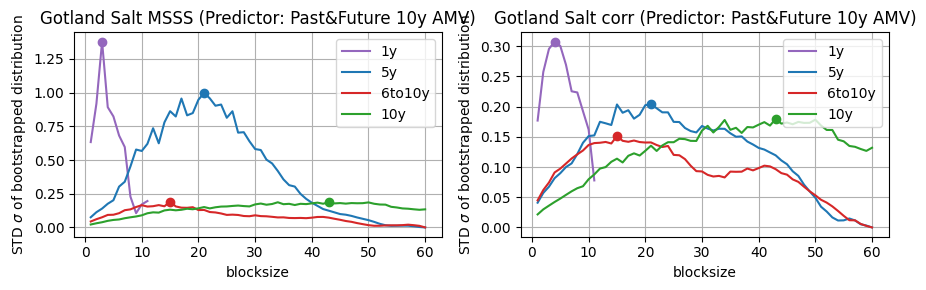

In [ ]:
'''Plot standard errors as function of blocksize'''
fig, ax = plt.subplots(1, 2, figsize=(9,3))
ax[0].plot(range(1, 12), stds_MSSSs_1y_salt_gotland, label='1y', c='tab:purple')
ax[0].plot(3, stds_MSSSs_1y_salt_gotland[2], 'o', c='tab:purple')
ax[0].plot(range(1, 61), stds_MSSSs_5y_salt_gotland, label='5y', c='tab:blue')
ax[0].plot(21, stds_MSSSs_5y_salt_gotland[20], 'o', c='tab:blue')
ax[0].plot(range(1, 61), stds_MSSSs_6to10y_salt_gotland, label='6to10y', c='tab:red')
ax[0].plot(15, stds_MSSSs_6to10y_salt_gotland[14], 'o', c='tab:red')
ax[0].plot(range(1, 61), stds_MSSSs_10y_salt_gotland, label='10y', c='tab:green')
ax[0].plot(43, stds_MSSSs_10y_salt_gotland[42], 'o', c='tab:green')
ax[0].legend()
ax[0].grid()
ax[0].set_xlabel('blocksize')
ax[0].set_ylabel(r'STD $\sigma$ of bootstrapped distribution')
ax[0].set_title('Gotland Salt MSSS (Predictor: Past&Future 10y AMV)')
ax[1].plot(range(1, 12), stds_corrs_1y_salt_gotland, label='1y', c='tab:purple')
ax[1].plot(4, stds_corrs_1y_salt_gotland[3], 'o', c='tab:purple')
ax[1].plot(range(1, 61), stds_corrs_5y_salt_gotland, label='5y', c='tab:blue')
ax[1].plot(21, stds_corrs_5y_salt_gotland[20], 'o', c='tab:blue')
ax[1].plot(range(1, 61), stds_corrs_6to10y_salt_gotland, label='6to10y', c='tab:red')
ax[1].plot(15, stds_corrs_6to10y_salt_gotland[14], 'o', c='tab:red')
ax[1].plot(range(1, 61), stds_corrs_10y_salt_gotland, label='10y', c='tab:green')
ax[1].plot(43, stds_corrs_10y_salt_gotland[42], 'o', c='tab:green')
ax[1].legend()
ax[1].grid()
ax[1].set_xlabel('blocksize')
ax[1].set_ylabel(r'STD $\sigma$ of bootstrapped distribution')
ax[1].set_title('Gotland Salt corr (Predictor: Past&Future 10y AMV)')
plt.tight_layout()
plt.show();
# 3 20 15 40

#### Total Heat Gotland: 3 6 6 6

In [ ]:
# '''Determine thresholds & years for 1975 Future djfm nao 5-9'''
# max_val = float('-inf')
# max_path = ()

# for category, strength_dict in skill_data_Gotland['MSSS']['Heat']['10y'].items():
#     for subcategory, values in strength_dict.items():
#         for i, val in enumerate(values):
#             if val > max_val:
#                 max_val = val
#                 max_path = (category.strip(), subcategory.strip(), i)

# print("Full BS maximum value:", max_val)
# print("Location:", f"{max_path[0]} → {max_path[1]} → index {max_path[2]}")


# print(get_predictor_thresholds(NAO_DJFM_59,detrend=0,EY=1975))

In [ ]:
'''Determine std(blocksize): Run bootstrap for blocksizes 1-60 for 1975 Future djfm nao 5-9 (ca. 2min)'''

thres_years_heat_gotland = [1967., 1975., 1977., 1980., 1981., 1982., 1989., 1992., 1993., 1994.]

stds_MSSSs_1y_heat_gotland = []
stds_corrs_1y_heat_gotland = []
stds_MSSSs_5y_heat_gotland = []
stds_corrs_5y_heat_gotland = []
stds_MSSSs_6to10y_heat_gotland = []
stds_corrs_6to10y_heat_gotland = []
stds_MSSSs_10y_heat_gotland = []
stds_corrs_10y_heat_gotland = []
for i in range(1,12):
    print(f'Blocksize {i}')
    _, _, std_corrs, std_MSSSs  = overlapping_block_bootstrap_test(data_timeseries=ds_heat_Gotland_ano.sel(EY=1975).sel(year=thres_years_heat_gotland).sel(month=slice(1,12)).mean(dim='year'), refrun_timeseries=refruns_heat_Gotland_ano[1975].sel(month=slice(1,12)), blocksize=i)
    stds_corrs_1y_heat_gotland = np.append(stds_corrs_1y_heat_gotland,std_corrs)
    stds_MSSSs_1y_heat_gotland = np.append(stds_MSSSs_1y_heat_gotland,std_MSSSs)
for i in range(1,61):
    print(f'Blocksize = {i}')
    _, _, std_corrs, std_MSSSs      = overlapping_block_bootstrap_test(data_timeseries=ds_heat_Gotland_ano.sel(EY=1975).sel(year=thres_years_heat_gotland).sel(month=slice(60,119)).mean(dim='year'), refrun_timeseries=refruns_heat_Gotland_ano[1975].sel(month=slice(60,119)), blocksize=i)
    stds_corrs_6to10y_heat_gotland = np.append(stds_corrs_6to10y_heat_gotland,std_corrs)
    stds_MSSSs_6to10y_heat_gotland = np.append(stds_MSSSs_6to10y_heat_gotland,std_MSSSs)
    _, _, std_corrs, std_MSSSs  = overlapping_block_bootstrap_test(data_timeseries=ds_heat_Gotland_ano.sel(EY=1975).sel(year=thres_years_heat_gotland).sel(month=slice(1,60)).mean(dim='year'), refrun_timeseries=refruns_heat_Gotland_ano[1975].sel(month=slice(1,60)), blocksize=i)
    stds_corrs_5y_heat_gotland = np.append(stds_corrs_5y_heat_gotland,std_corrs)
    stds_MSSSs_5y_heat_gotland = np.append(stds_MSSSs_5y_heat_gotland,std_MSSSs)
    _, _, std_corrs, std_MSSSs   = overlapping_block_bootstrap_test(data_timeseries=ds_heat_Gotland_ano.sel(EY=1975).sel(year=thres_years_heat_gotland).mean(dim='year'), refrun_timeseries=refruns_heat_Gotland_ano[1975], blocksize=i)
    stds_corrs_10y_heat_gotland = np.append(stds_corrs_10y_heat_gotland,std_corrs)
    stds_MSSSs_10y_heat_gotland = np.append(stds_MSSSs_10y_heat_gotland,std_MSSSs)

Blocksize 1


Blocksize 2
Blocksize 3
Blocksize 4
Blocksize 5
Blocksize 6
Blocksize 7
Blocksize 8
Blocksize 9
Blocksize 10
Blocksize 11
Blocksize = 1
Blocksize = 2
Blocksize = 3
Blocksize = 4
Blocksize = 5
Blocksize = 6
Blocksize = 7
Blocksize = 8
Blocksize = 9
Blocksize = 10
Blocksize = 11
Blocksize = 12
Blocksize = 13
Blocksize = 14
Blocksize = 15
Blocksize = 16
Blocksize = 17
Blocksize = 18
Blocksize = 19
Blocksize = 20
Blocksize = 21
Blocksize = 22
Blocksize = 23
Blocksize = 24
Blocksize = 25
Blocksize = 26
Blocksize = 27
Blocksize = 28
Blocksize = 29
Blocksize = 30
Blocksize = 31
Blocksize = 32
Blocksize = 33
Blocksize = 34
Blocksize = 35
Blocksize = 36
Blocksize = 37
Blocksize = 38
Blocksize = 39
Blocksize = 40
Blocksize = 41
Blocksize = 42
Blocksize = 43
Blocksize = 44
Blocksize = 45
Blocksize = 46
Blocksize = 47
Blocksize = 48
Blocksize = 49
Blocksize = 50
Blocksize = 51
Blocksize = 52
Blocksize = 53
Blocksize = 54
Blocksize = 55
Blocksize = 56
Blocksize = 57
Blocksize = 58
Blocksize = 59
Bl

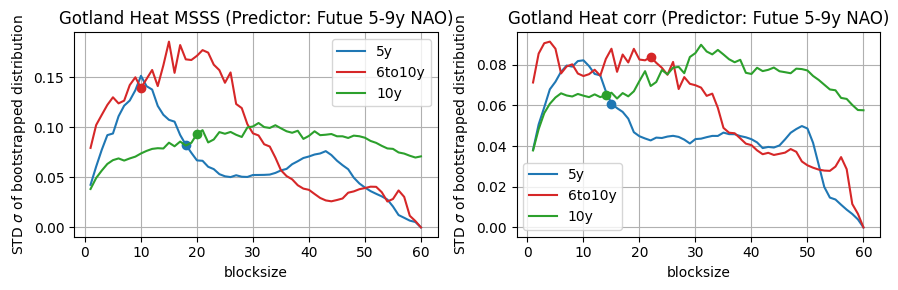

In [ ]:
'''Plot standard errors as function of blocksize'''
fig, ax = plt.subplots(1, 2, figsize=(9,3))
# ax[0].plot(range(1, 12), stds_MSSSs_1y_heat_gotland, label='1y', c='tab:purple')
# ax[0].plot(3, stds_MSSSs_1y_heat_gotland[2], 'o', c='tab:purple')
ax[0].plot(range(1, 61), stds_MSSSs_5y_heat_gotland, label='5y', c='tab:blue')
ax[0].plot(18, stds_MSSSs_5y_heat_gotland[17], 'o', c='tab:blue')
ax[0].plot(range(1, 61), stds_MSSSs_6to10y_heat_gotland, label='6to10y', c='tab:red')
ax[0].plot(10, stds_MSSSs_6to10y_heat_gotland[9], 'o', c='tab:red')
ax[0].plot(range(1, 61), stds_MSSSs_10y_heat_gotland, label='10y', c='tab:green')
ax[0].plot(20, stds_MSSSs_10y_heat_gotland[19], 'o', c='tab:green')
ax[0].legend()
ax[0].grid()
ax[0].set_xlabel('blocksize')
ax[0].set_ylabel(r'STD $\sigma$ of bootstrapped distribution')
ax[0].set_title('Gotland Heat MSSS (Predictor: Futue 5-9y NAO)')
# ax[1].plot(range(1, 12), stds_corrs_1y_heat_gotland, label='1y', c='tab:purple')
# ax[1].plot(5, stds_corrs_1y_heat_gotland[4], 'o', c='tab:purple')
ax[1].plot(range(1, 61), stds_corrs_5y_heat_gotland, label='5y', c='tab:blue')
ax[1].plot(15, stds_corrs_5y_heat_gotland[14], 'o', c='tab:blue')
ax[1].plot(range(1, 61), stds_corrs_6to10y_heat_gotland, label='6to10y', c='tab:red')
ax[1].plot(22, stds_corrs_6to10y_heat_gotland[21], 'o', c='tab:red')
ax[1].plot(range(1, 61), stds_corrs_10y_heat_gotland, label='10y', c='tab:green')
ax[1].plot(14, stds_corrs_10y_heat_gotland[13], 'o', c='tab:green')
ax[1].legend()
ax[1].grid()
ax[1].set_xlabel('blocksize')
ax[1].set_ylabel(r'STD $\sigma$ of bootstrapped distribution')
ax[1].set_title('Gotland Heat corr (Predictor: Futue 5-9y NAO)')
plt.tight_layout()
plt.show();
# 3 6 6 6

#### SSS Bothnian: 4 6 20 40

In [ ]:
# '''Determine thresholds & years for 1950 init. Salt Bothnian'''
# max_val = float('-inf')
# max_path = ()

# for category, strength_dict in skill_data_Gotland['MSSS']['SSS']['10y']['Past 3y AMV']["     Mod pos"]#.items():
#     for subcategory, values in strength_dict.items():
#         for i, val in enumerate(values):
#             if val > max_val:
#                 max_val = val
#                 max_path = (category.strip(), subcategory.strip(), i)

# print("Full BS maximum value:", max_val)
# print("Location:", f"{max_path[0]} → {max_path[1]} → index {max_path[2]}")


# print(get_predictor_thresholds(salt_0101_Bothnian,detrend=0,EY=1950))

In [ ]:
'''Determine std(blocksize): Run bootstrap for blocksizes 1-60 for 1950 init. Salt Bothnian (ca. 2min)'''

thres_years_sss_Bothnian = [1948., 1950., 1951., 1952., 1953., 1954., 1955., 2000.]

stds_MSSSs_1y_sss_Bothnian = []
stds_corrs_1y_sss_Bothnian = []
stds_MSSSs_5y_sss_Bothnian = []
stds_corrs_5y_sss_Bothnian = []
stds_MSSSs_6to10y_sss_Bothnian = []
stds_corrs_6to10y_sss_Bothnian = []
stds_MSSSs_10y_sss_Bothnian = []
stds_corrs_10y_sss_Bothnian = []
for i in range(1,12):
    print(f'Blocksize {i}')
    _, _, std_corrs, std_MSSSs  = overlapping_block_bootstrap_test(data_timeseries=ds_sss_Bothnian_ano.sel(EY=1950).sel(year=thres_years_sss_Bothnian).sel(month=slice(1,12)).mean(dim='year'), refrun_timeseries=refruns_sss_Bothnian_ano[1950].sel(month=slice(1,12)), blocksize=i)
    stds_corrs_1y_sss_Bothnian = np.append(stds_corrs_1y_sss_Bothnian,std_corrs)
    stds_MSSSs_1y_sss_Bothnian = np.append(stds_MSSSs_1y_sss_Bothnian,std_MSSSs)
for i in range(1,61):
    print(f'Blocksize = {i}')
    _, _, std_corrs, std_MSSSs      = overlapping_block_bootstrap_test(data_timeseries=ds_sss_Bothnian_ano.sel(EY=1950).sel(year=thres_years_sss_Bothnian).sel(month=slice(60,119)).mean(dim='year'), refrun_timeseries=refruns_sss_Bothnian_ano[1950].sel(month=slice(60,119)), blocksize=i)
    stds_corrs_6to10y_sss_Bothnian = np.append(stds_corrs_6to10y_sss_Bothnian,std_corrs)
    stds_MSSSs_6to10y_sss_Bothnian = np.append(stds_MSSSs_6to10y_sss_Bothnian,std_MSSSs)
    _, _, std_corrs, std_MSSSs  = overlapping_block_bootstrap_test(data_timeseries=ds_sss_Bothnian_ano.sel(EY=1950).sel(year=thres_years_sss_Bothnian).sel(month=slice(1,60)).mean(dim='year'), refrun_timeseries=refruns_sss_Bothnian_ano[1950].sel(month=slice(1,60)), blocksize=i)
    stds_corrs_5y_sss_Bothnian = np.append(stds_corrs_5y_sss_Bothnian,std_corrs)
    stds_MSSSs_5y_sss_Bothnian = np.append(stds_MSSSs_5y_sss_Bothnian,std_MSSSs)
    _, _, std_corrs, std_MSSSs   = overlapping_block_bootstrap_test(data_timeseries=ds_sss_Bothnian_ano.sel(EY=1950).sel(year=thres_years_sss_Bothnian).mean(dim='year'), refrun_timeseries=refruns_sss_Bothnian_ano[1950], blocksize=i)
    stds_corrs_10y_sss_Bothnian = np.append(stds_corrs_10y_sss_Bothnian,std_corrs)
    stds_MSSSs_10y_sss_Bothnian = np.append(stds_MSSSs_10y_sss_Bothnian,std_MSSSs)

Blocksize 1


Blocksize 2
Blocksize 3
Blocksize 4
Blocksize 5
Blocksize 6
Blocksize 7
Blocksize 8
Blocksize 9
Blocksize 10
Blocksize 11
Blocksize = 1
Blocksize = 2
Blocksize = 3
Blocksize = 4
Blocksize = 5
Blocksize = 6
Blocksize = 7
Blocksize = 8
Blocksize = 9
Blocksize = 10
Blocksize = 11
Blocksize = 12
Blocksize = 13
Blocksize = 14
Blocksize = 15
Blocksize = 16
Blocksize = 17
Blocksize = 18
Blocksize = 19
Blocksize = 20
Blocksize = 21
Blocksize = 22
Blocksize = 23
Blocksize = 24
Blocksize = 25
Blocksize = 26
Blocksize = 27
Blocksize = 28
Blocksize = 29
Blocksize = 30
Blocksize = 31
Blocksize = 32
Blocksize = 33
Blocksize = 34
Blocksize = 35
Blocksize = 36
Blocksize = 37
Blocksize = 38
Blocksize = 39
Blocksize = 40
Blocksize = 41
Blocksize = 42
Blocksize = 43
Blocksize = 44
Blocksize = 45
Blocksize = 46
Blocksize = 47
Blocksize = 48
Blocksize = 49
Blocksize = 50
Blocksize = 51
Blocksize = 52
Blocksize = 53
Blocksize = 54
Blocksize = 55
Blocksize = 56
Blocksize = 57
Blocksize = 58
Blocksize = 59
Bl

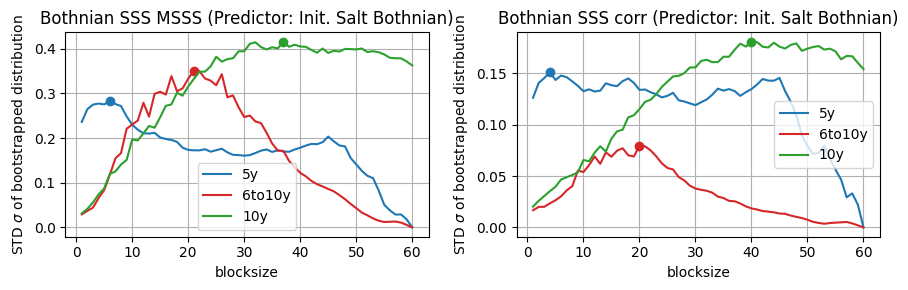

In [ ]:
'''Plot standard errors as function of blocksize'''
fig, ax = plt.subplots(1, 2, figsize=(9,3))
# ax[0].plot(range(1, 12), stds_MSSSs_1y_sss_Bothnian, label='1y', c='tab:purple')
# ax[0].plot(4, stds_MSSSs_1y_sss_Bothnian[3], 'o', c='tab:purple')
ax[0].plot(range(1, 61), stds_MSSSs_5y_sss_Bothnian, label='5y', c='tab:blue')
ax[0].plot(6, stds_MSSSs_5y_sss_Bothnian[5], 'o', c='tab:blue')
ax[0].plot(range(1, 61), stds_MSSSs_6to10y_sss_Bothnian, label='6to10y', c='tab:red')
ax[0].plot(21, stds_MSSSs_6to10y_sss_Bothnian[20], 'o', c='tab:red')
ax[0].plot(range(1, 61), stds_MSSSs_10y_sss_Bothnian, label='10y', c='tab:green')
ax[0].plot(37, stds_MSSSs_10y_sss_Bothnian[36], 'o', c='tab:green')
ax[0].legend()
ax[0].grid()
ax[0].set_xlabel('blocksize')
ax[0].set_ylabel(r'STD $\sigma$ of bootstrapped distribution')
ax[0].set_title('Bothnian SSS MSSS (Predictor: Init. Salt Bothnian)')
# ax[1].plot(range(1, 12), stds_corrs_1y_sss_Bothnian, label='1y', c='tab:purple')
# ax[1].plot(3, stds_corrs_1y_sss_Bothnian[2], 'o', c='tab:purple')
ax[1].plot(range(1, 61), stds_corrs_5y_sss_Bothnian, label='5y', c='tab:blue')
ax[1].plot(4, stds_corrs_5y_sss_Bothnian[3], 'o', c='tab:blue')
ax[1].plot(range(1, 61), stds_corrs_6to10y_sss_Bothnian, label='6to10y', c='tab:red')
ax[1].plot(20, stds_corrs_6to10y_sss_Bothnian[19], 'o', c='tab:red')
ax[1].plot(range(1, 61), stds_corrs_10y_sss_Bothnian, label='10y', c='tab:green')
ax[1].plot(40, stds_corrs_10y_sss_Bothnian[39], 'o', c='tab:green')
ax[1].legend()
ax[1].grid()
ax[1].set_xlabel('blocksize')
ax[1].set_ylabel(r'STD $\sigma$ of bootstrapped distribution')
ax[1].set_title('Bothnian SSS corr (Predictor: Init. Salt Bothnian)')
plt.tight_layout()
plt.show();
# 4 6 20 40

#### Total Salt Bothnian: 4 10 20 40

In [ ]:
# '''Determine thresholds & years for 1950 init. Salt Bothnian'''
# max_val = float('-inf')
# max_path = ()

# for category, strength_dict in skill_data_Gotland['MSSS']['Salt']['10y'].items():
#     for subcategory, values in strength_dict.items():
#         for i, val in enumerate(values):
#             if val > max_val:
#                 max_val = val
#                 max_path = (category.strip(), subcategory.strip(), i)

# print("Full BS maximum value:", max_val)
# print("Location:", f"{max_path[0]} → {max_path[1]} → index {max_path[2]}")


# print(get_predictor_thresholds(salt_0101_Bothnian,detrend=0,EY=1950))

In [ ]:
'''Determine std(blocksize): Run bootstrap for blocksizes 1-60 for 1950 init. Salt Bothnian (ca. 2min)'''

thres_years_salt_Bothnian = [1948., 1950., 1951., 1952., 1953., 1954., 1955., 2000.]

stds_MSSSs_1y_salt_Bothnian = []
stds_corrs_1y_salt_Bothnian = []
stds_MSSSs_5y_salt_Bothnian = []
stds_corrs_5y_salt_Bothnian = []
stds_MSSSs_6to10y_salt_Bothnian = []
stds_corrs_6to10y_salt_Bothnian = []
stds_MSSSs_10y_salt_Bothnian = []
stds_corrs_10y_salt_Bothnian = []
for i in range(1,12):
    print(f'Blocksize {i}')
    _, _, std_corrs, std_MSSSs  = overlapping_block_bootstrap_test(data_timeseries=ds_salt_Bothnian_ano.sel(EY=1950).sel(year=thres_years_salt_Bothnian).sel(month=slice(1,12)).mean(dim='year'), refrun_timeseries=refruns_salt_Bothnian_ano[1950].sel(month=slice(1,12)), blocksize=i)
    stds_corrs_1y_salt_Bothnian = np.append(stds_corrs_1y_salt_Bothnian,std_corrs)
    stds_MSSSs_1y_salt_Bothnian = np.append(stds_MSSSs_1y_salt_Bothnian,std_MSSSs)
for i in range(1,61):
    print(f'Blocksize = {i}')
    _, _, std_corrs, std_MSSSs      = overlapping_block_bootstrap_test(data_timeseries=ds_salt_Bothnian_ano.sel(EY=1950).sel(year=thres_years_salt_Bothnian).sel(month=slice(60,119)).mean(dim='year'), refrun_timeseries=refruns_salt_Bothnian_ano[1950].sel(month=slice(60,119)), blocksize=i)
    stds_corrs_6to10y_salt_Bothnian = np.append(stds_corrs_6to10y_salt_Bothnian,std_corrs)
    stds_MSSSs_6to10y_salt_Bothnian = np.append(stds_MSSSs_6to10y_salt_Bothnian,std_MSSSs)
    _, _, std_corrs, std_MSSSs  = overlapping_block_bootstrap_test(data_timeseries=ds_salt_Bothnian_ano.sel(EY=1950).sel(year=thres_years_salt_Bothnian).sel(month=slice(1,60)).mean(dim='year'), refrun_timeseries=refruns_salt_Bothnian_ano[1950].sel(month=slice(1,60)), blocksize=i)
    stds_corrs_5y_salt_Bothnian = np.append(stds_corrs_5y_salt_Bothnian,std_corrs)
    stds_MSSSs_5y_salt_Bothnian = np.append(stds_MSSSs_5y_salt_Bothnian,std_MSSSs)
    _, _, std_corrs, std_MSSSs   = overlapping_block_bootstrap_test(data_timeseries=ds_salt_Bothnian_ano.sel(EY=1950).sel(year=thres_years_salt_Bothnian).mean(dim='year'), refrun_timeseries=refruns_salt_Bothnian_ano[1950], blocksize=i)
    stds_corrs_10y_salt_Bothnian = np.append(stds_corrs_10y_salt_Bothnian,std_corrs)
    stds_MSSSs_10y_salt_Bothnian = np.append(stds_MSSSs_10y_salt_Bothnian,std_MSSSs)

Blocksize 1


Blocksize 2
Blocksize 3
Blocksize 4
Blocksize 5
Blocksize 6
Blocksize 7
Blocksize 8
Blocksize 9
Blocksize 10
Blocksize 11
Blocksize = 1
Blocksize = 2
Blocksize = 3
Blocksize = 4
Blocksize = 5
Blocksize = 6
Blocksize = 7
Blocksize = 8
Blocksize = 9
Blocksize = 10
Blocksize = 11
Blocksize = 12
Blocksize = 13
Blocksize = 14
Blocksize = 15
Blocksize = 16
Blocksize = 17
Blocksize = 18
Blocksize = 19
Blocksize = 20
Blocksize = 21
Blocksize = 22
Blocksize = 23
Blocksize = 24
Blocksize = 25
Blocksize = 26
Blocksize = 27
Blocksize = 28
Blocksize = 29
Blocksize = 30
Blocksize = 31
Blocksize = 32
Blocksize = 33
Blocksize = 34
Blocksize = 35
Blocksize = 36
Blocksize = 37
Blocksize = 38
Blocksize = 39
Blocksize = 40
Blocksize = 41
Blocksize = 42
Blocksize = 43
Blocksize = 44
Blocksize = 45
Blocksize = 46
Blocksize = 47
Blocksize = 48
Blocksize = 49
Blocksize = 50
Blocksize = 51
Blocksize = 52
Blocksize = 53
Blocksize = 54
Blocksize = 55
Blocksize = 56
Blocksize = 57
Blocksize = 58
Blocksize = 59
Bl

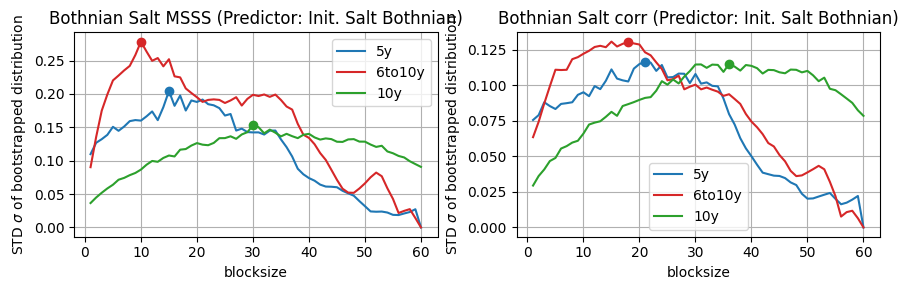

In [ ]:
'''Plot standard errors as function of blocksize'''
fig, ax = plt.subplots(1, 2, figsize=(9,3))
# ax[0].plot(range(1, 12), stds_MSSSs_1y_salt_Bothnian, label='1y', c='tab:purple')
# ax[0].plot(4, stds_MSSSs_1y_salt_Bothnian[3], 'o', c='tab:purple')
ax[0].plot(range(1, 61), stds_MSSSs_5y_salt_Bothnian, label='5y', c='tab:blue')
ax[0].plot(15, stds_MSSSs_5y_salt_Bothnian[14], 'o', c='tab:blue')
ax[0].plot(range(1, 61), stds_MSSSs_6to10y_salt_Bothnian, label='6to10y', c='tab:red')
ax[0].plot(10, stds_MSSSs_6to10y_salt_Bothnian[9], 'o', c='tab:red')
ax[0].plot(range(1, 61), stds_MSSSs_10y_salt_Bothnian, label='10y', c='tab:green')
ax[0].plot(30, stds_MSSSs_10y_salt_Bothnian[29], 'o', c='tab:green')
ax[0].legend()
ax[0].grid()
ax[0].set_xlabel('blocksize')
ax[0].set_ylabel(r'STD $\sigma$ of bootstrapped distribution')
ax[0].set_title('Bothnian Salt MSSS (Predictor: Init. Salt Bothnian)')
# ax[1].plot(range(1, 12), stds_corrs_1y_salt_Bothnian, label='1y', c='tab:purple')
# ax[1].plot(4, stds_corrs_1y_salt_Bothnian[3], 'o', c='tab:purple')
ax[1].plot(range(1, 61), stds_corrs_5y_salt_Bothnian, label='5y', c='tab:blue')
ax[1].plot(21, stds_corrs_5y_salt_Bothnian[20], 'o', c='tab:blue')
ax[1].plot(range(1, 61), stds_corrs_6to10y_salt_Bothnian, label='6to10y', c='tab:red')
ax[1].plot(18, stds_corrs_6to10y_salt_Bothnian[17], 'o', c='tab:red')
ax[1].plot(range(1, 61), stds_corrs_10y_salt_Bothnian, label='10y', c='tab:green')
ax[1].plot(36, stds_corrs_10y_salt_Bothnian[35], 'o', c='tab:green')
ax[1].legend()
ax[1].grid()
ax[1].set_xlabel('blocksize')
ax[1].set_ylabel(r'STD $\sigma$ of bootstrapped distribution')
ax[1].set_title('Bothnian Salt corr (Predictor: Init. Salt Bothnian)')
plt.tight_layout()
plt.show();
# 4 10 20 40

In [ ]:
### careful:

# - which detrending (1/2/34)
# - means of bootstrapped p values used, mean computation not built into bootstrapping (would be pain)
# - think about which climatology to remove from ensemble data (ensemble or refrun climatology)
# - MSSS Salt 10y: Bei msss berechnung ist refrun_salt.mean() auf 10y skala fast 0 trotz polaritätswechsel bei 5y - gerade switch von AMV einfluss eingefangen -> wichtig!

## Archive

In [ ]:
# '''Plot 10y anomalies to refrun '''
# # sinnvolles kriterium überlegen welche predictors alle plotten

# for EY in ensemble_years:
#     for predictant_name, predictant_ds, predictant_refruns in predictants:
#         print(f"{predictant_name} {EY}")

#         fig, ax = plt.subplots(1,2,figsize=(10,3))
#         ax[0].set_title(f"{predictant_name} {EY}")
#         ax[1].set_title(f"{predictant_name} anomaly to refrun {EY}")
#         ax[1].axhline(0, c='k', lw=0.5)
#         ax[0].grid()
#         ax[1].grid()
#         # plt.tight_layout()

#         for predictor_name, predictor_timeseries in predictors:

#             # for all predictors listed above use function to    determine in which threshold the initial field of a given EY lays
#             if predictor_name == "Init. Heat" or predictor_name == "Init. SST":  # detrend temperature related timeseries to remove climate change signal
#                 detrend = 1
#             else:
#                 detrend = 0
#             _, thres_name, thres_years = get_predictor_thresholds(predictor_timeseries, detrend, EY)

#             if skill_data_full_BS['MSSS'][predictant_name]['10y'][predictor_name][thres_name][0] > 0.18:
#                 ax[0].plot(predictant_ds.sel(EY=EY).sel(year=thres_years).mean(dim='year'), lw=0.5, label=f"{predictor_name}")
#                 ax[1].plot(predictant_ds.sel(EY=EY).sel(year=thres_years).mean(dim='year') - predictant_refruns[EY], lw=0.5, label=f"{predictor_name}")
#         ax[0].plot(predictant_refruns[EY], c='k', lw=0.5, label='Ref. run')
#         ax[1].plot(predictant_ds.sel(EY=EY).mean(dim='year') - predictant_refruns[EY], lw=1, c='k', label="Full ensemble")
#         ax[0].legend(loc='lower center', bbox_to_anchor=(1, -0.33), frameon=True, ncols=6)
#         plt.show()

<xarray.Dataset> Size: 2MB
Dimensions:  (station: 7, time: 120, z_l: 95)
Coordinates:
  * z_l      (z_l) float64 760B 0.4367 1.323 2.221 3.145 ... 202.8 206.3 209.9
  * time     (time) object 960B 1988-01-16 12:00:00 ... 1997-12-16 12:00:00
  * station  (station) object 56B 'BY02' 'BY05' 'BY15' 'BY31' 'C3' 'F9' 'LL7'
Data variables:
    h        (station, time, z_l) float64 638kB dask.array<chunksize=(1, 12, 34), meta=np.ndarray>
    temp     (station, time, z_l) float64 638kB dask.array<chunksize=(1, 12, 34), meta=np.ndarray>
    salt     (station, time, z_l) float64 638kB dask.array<chunksize=(1, 12, 34), meta=np.ndarray>


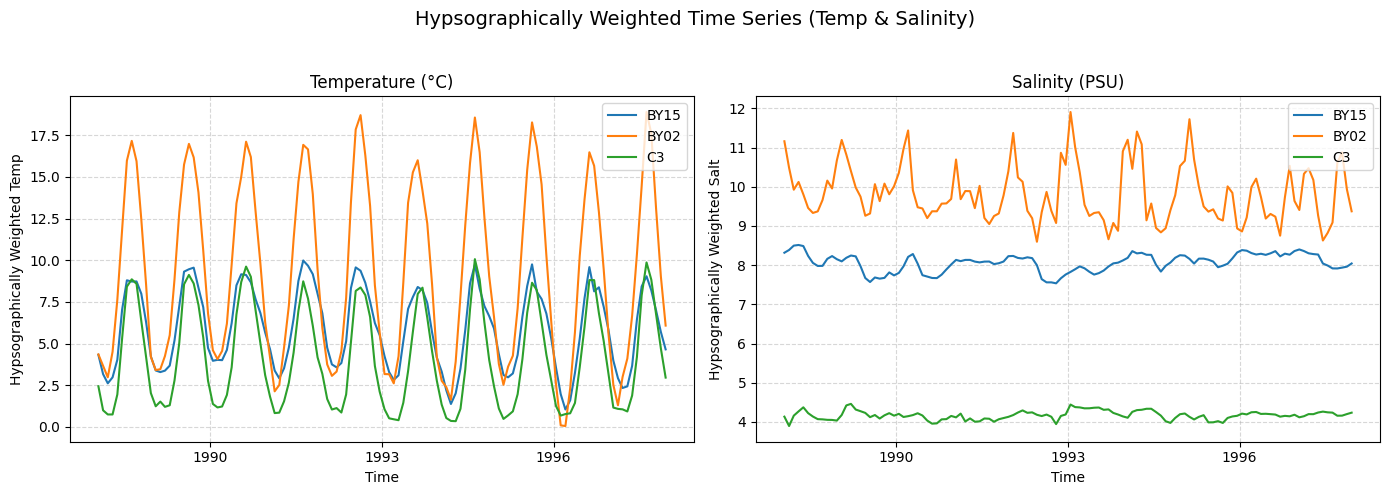

In [ ]:
'''Read in ds with stations data'''

# Read in all .nc files as xr.Dataset
stations_list = ['BY02', 'BY05', 'BY15', 'BY31', 'C3', 'F9', 'LL7']
datasets = []
for station in stations_list:
    file_pattern = f"../ensemble_05/member_05_1988/member_05_1988_19*/19*0101.station_{station}.nc.*"
    ds = xr.open_mfdataset(file_pattern, combine='nested', concat_dim='time', decode_times=True)
    ds = ds.expand_dims({'station': [station]})  # Add station as a new dimension
    ds = ds.drop_vars(["nv", "z_i", "average_T1", "average_T2", "average_DT", "time_bnds"])  # Remove unwanted stuff
    ds = ds.where(ds.notnull().compute(), drop=True)  # Remove nan values - for every station below the sea bottom at that point the grid goes on
    ds = ds.mean(dim=["xh_sub01", "yh_sub01"])
    datasets.append(ds)
    stations_ds = xr.concat(datasets, dim='station')
print(stations_ds)

# Define station-subbasin pairs
station_subbasin_pairs = {
    'BY15': 'Gotland Sea',
    'BY02': 'Arkona Basin',
    'C3':   'Bothnian Sea'
}
results = {}

# Iterate over selected stations
for station, subbasin in station_subbasin_pairs.items():
    # Get hypsographic profile
    hypso = hypsos[subbasin]

    # Select station data
    temp = stations_ds.temp.sel(station=station)
    salt = stations_ds.salt.sel(station=station)

    # Multiply with hypsographic profile over depth
    temp_weighted = (temp * hypso).sum(dim='z_l', skipna=True)
    salt_weighted = (salt * hypso).sum(dim='z_l', skipna=True)
    results[station] = {
        'temp': temp_weighted,
        'salt': salt_weighted
    }

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
# Temp
ax = axes[0]
for station in results:
    ax.plot(results[station]['temp']['time'], results[station]['temp'], label=station)
ax.set_title("Temperature (°C)")
ax.set_xlabel("Time")
ax.set_ylabel("Hypsographically Weighted Temp")
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
# Salt
ax = axes[1]
for station in results:
    ax.plot(results[station]['salt']['time'], results[station]['salt'], label=station)
ax.set_title("Salinity (PSU)")
ax.set_xlabel("Time")
ax.set_ylabel("Hypsographically Weighted Salt")
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()

fig.suptitle("Hypsographically Weighted Time Series (Temp & Salinity)", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for suptitle
plt.show()

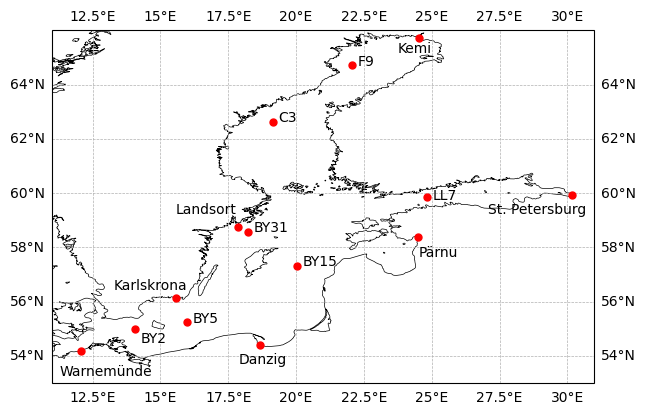

In [ ]:
'''Plot map of evaluated stations'''
# Dictionary of stations with latitudes and longitudes
stations = { 
    "BY5" : {"lat": 55.25, "lon": 15.98},
    "F9"  : {"lat": 64.71, "lon": 22.07},
    "C3"  : {"lat": 62.64, "lon": 19.16},
    "BY31": {"lat": 58.58, "lon": 18.23},
    "BY15": {"lat": 57.33, "lon": 20.05},
    "LL7" : {"lat": 59.85, "lon": 24.84},
    "BY2" : {"lat": 55.00, "lon": 14.08}
}

stations_coast = {
    "Warnemünde"     : {"lat": 54.18, "lon": 12.08},
    "Danzig"         : {"lat": 54.41, "lon": 18.67},
    "Karlskrona"     : {"lat": 56.15, "lon": 15.58},
    "St. Petersburg" : {"lat": 59.94, "lon": 30.18},
    "Landsort"       : {"lat": 58.74, "lon": 17.87},
    "Kemi"           : {"lat": 65.73, "lon": 24.55},
    "Pärnu"          : {"lat": 58.37, "lon": 24.50}
}

# Create the figure and axis with a specific projection
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()}, dpi=100, figsize=(7,7))
ax.set_extent([11, 31, 53, 66], crs=ccrs.PlateCarree())  # Baltic Sea region
# Add coastlines and gridlines
ax.coastlines(lw=0.5)
ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5)

# Plot each station in water
for station, coords in stations.items():
    if station == "BY2":
        ax.plot(coords['lon'], coords['lat'], marker='o', color='red', markersize=5, transform=ccrs.PlateCarree())
        ax.text(coords['lon'] + 0.2, coords['lat'] - 0.5, station, transform=ccrs.PlateCarree(), fontsize=10, alpha=1)
    elif station == "LL7":
        ax.plot(coords['lon'], coords['lat'], marker='o', color='red', markersize=5, transform=ccrs.PlateCarree())
        ax.text(coords['lon'] + 0.2, coords['lat'] - 0.1, station, transform=ccrs.PlateCarree(), fontsize=10, alpha=1)
    else:        
        ax.plot(coords['lon'], coords['lat'], marker='o', color='red', markersize=5, transform=ccrs.PlateCarree())
        ax.text(coords['lon'] + 0.2, coords['lat'], station, transform=ccrs.PlateCarree(), fontsize=10, alpha=1)

for station, coords in stations_coast.items():
    if station == "Landsort":
        ax.plot(coords['lon'], coords['lat'], marker='o', color='red', markersize=5, transform=ccrs.PlateCarree())
        ax.text(coords['lon'] -2.3, coords['lat'] +0.5, station, transform=ccrs.PlateCarree(), fontsize=10, alpha=1)
    elif station == "Warnemünde":
        ax.plot(coords['lon'], coords['lat'], marker='o', color='red', markersize=5, transform=ccrs.PlateCarree())
        ax.text(coords['lon'] - 0.8, coords['lat'] -0.9, station, transform=ccrs.PlateCarree(), fontsize=10, alpha=1)
    elif station == "Karlskrona":
        ax.plot(coords['lon'], coords['lat'], marker='o', color='red', markersize=5, transform=ccrs.PlateCarree())
        ax.text(coords['lon'] - 2.3, coords['lat'] + 0.3, station, transform=ccrs.PlateCarree(), fontsize=10, alpha=1)
    elif station == "Kemi":
        ax.plot(coords['lon'], coords['lat'], marker='o', color='red', markersize=5, transform=ccrs.PlateCarree())
        ax.text(coords['lon'] - 0.8, coords['lat'] -0.55, station, transform=ccrs.PlateCarree(), fontsize=10, alpha=1)
    elif station == "St. Petersburg":
        ax.plot(coords['lon'], coords['lat'], marker='o', color='red', markersize=5, transform=ccrs.PlateCarree())
        ax.text(coords['lon'] - 3.1, coords['lat'] + -0.7, station, transform=ccrs.PlateCarree(), fontsize=10, alpha=1)
    elif station == "Pärnu":
        ax.plot(coords['lon'], coords['lat'], marker='o', color='red', markersize=5, transform=ccrs.PlateCarree())
        ax.text(coords['lon'], coords['lat'] + -0.7, station, transform=ccrs.PlateCarree(), fontsize=10, alpha=1)
    else:  
        ax.plot(coords['lon'], coords['lat'], marker='o', color='red', markersize=5, transform=ccrs.PlateCarree())
        ax.text(coords['lon'] - 0.8, coords['lat'] - 0.7, station, transform=ccrs.PlateCarree(), fontsize=10, alpha=1)        
